In [1]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import simulations.genomes1000_sim as sim_functions

intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/outfput'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop.frq.strat'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

## Explore 1000 genomes data

### Algorithm creation

In [191]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product
from joblib import Parallel, delayed
from functools import partial
import sys
import mlflow
import submitit
import random
from mlflow.tracking import MlflowClient
from datetime import datetime
from zoneinfo import ZoneInfo
intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
artifact_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs'
r_path = '/gpfs/commons/home/anewbury/miniconda/bin/Rscript'
sys.path.append(code_dir)
import simulations.genomes1000_sim as sim_functions
import algorithms.SCoNE as SCoNE
import algorithms.SCoNE_noUC as SCoNE_noUC
import algorithms.MLFlowWrapper as MLFlowWrapper
import evaluation.cluster_evaluation as cluster_evaluation
import importlib
importlib.reload(SCoNE)
importlib.reload(sim_functions)
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.25,0.5,0.75,1]
num_markers_assoc_list = [100,500]
bfile_path=f'{sim_output_dir}/G'
af_df_filepath=admixture_filepath
rank = 3
tuning = False # to run sparsity tuning step
testing = True # to run testing step
# PARAMETERS
np.random.seed(42)

# read in Z
Z_df = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy() 



In [194]:
for e in e_list:
    g_ps=0
    c_ps =0
    #e=0.25
    dataset=0

    # genetic_subgroups, phenotypic_subgroups, C, iid_order, markers_assoc_dict, clinical_assoc_df = sim_functions.sun_generate_sim_data(bfile_path, maf_by_superpop_filepath,igsr_samples_filepath,
    #                           intermediate_plink_dir,sim_functions.get_output_file_suffix(ps,e,dataset,g),sim_output_dir,sim_functions.get_output_file_suffix(ps,e,dataset,g),
    #                           ps,g,e,300,100,10,100, 2)
    output_file_suffix = sim_functions.get_output_file_suffix(e=e,g_ps=g_ps,c_ps=c_ps,dataset=dataset)
    C = np.load(f'{sim_output_dir}/C_{output_file_suffix}.npy')
    with open(f'{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl','rb') as f:
        simulation_metadata = pickle.load(f)
    iid_order = simulation_metadata['iid_order']
    fam_df = pd.read_csv(f'{sim_output_dir}/G_{output_file_suffix}.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    iid_index = fam_df[fam_df['IID'].isin(iid_order)].index # some samples removed due to overlap btwn subgroups, need correct length

    G = np.loadtxt(f'{sim_output_dir}/G_{output_file_suffix}.raw',  usecols=range(6, 100+6), dtype=np.int8, skiprows=1)
    factor_matrices, loss_function = SCoNE.alternating_opt(G,C,Z[iid_index,:],
        rank=3,num_init=10,lambda_W=0, lambda_H_G=0, lambda_H_C=0, lambda_Gloss=1,
        method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':20, 'ftol':1e-6},tol=1e-4,nonneg=True, C_loss_type=None, G_loss_type='kl_div')
    W_true = (simulation_metadata['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
            .reindex(simulation_metadata['iid_order']).iloc[:,:2].to_numpy().astype(int))
    ground_truth = {"W":W_true}
    eval = cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)
    print(f'e: {e}, nmi: {eval["nmi"]}')

e: 0.25, nmi: 0.0007839924740756111
e: 0.5, nmi: 0.02032485317812999
e: 0.75, nmi: 0.002382304238666371
e: 1, nmi: 0.03369219024051946


running mvbc

In [10]:
with open('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/slurm_logs/10002631_323_submitted.pkl','rb') as f:
    pickle_file = pickle.load(f)
print(pickle_file)

In [11]:
obj = pickle_file

print(type(obj))                         # class & module
print(obj.__class__.__module__, obj.__class__.__qualname__)
print(repr(obj))                         # its repr

import pprint, inspect

# 1) Plain attributes
if hasattr(obj, "__dict__"):
    pprint.pprint(vars(obj))             # same as obj.__dict__

# 2) Slots-based or properties too
members = [(k, v) for k, v in inspect.getmembers(obj)
           if not k.startswith("_") and not inspect.ismethod(v) and not inspect.isfunction(v)]
pprint.pprint(members)



<class 'submitit.core.utils.DelayedSubmission'>
submitit.core.utils DelayedSubmission
{'_done': False,
 '_result': None,
 '_timeout_countdown': 3,
 '_timeout_min': 300,
 'args': ({'C_loss_type': 'kl_div',
           'G_loss_type': 'kl_div',
           'Z': array([[3.72130e-01, 6.27840e-01, 1.00000e-05, 1.00000e-05, 1.00000e-05],
       [3.82685e-01, 6.17285e-01, 1.00000e-05, 1.00000e-05, 1.00000e-05],
       [4.15996e-01, 5.83974e-01, 1.00000e-05, 1.00000e-05, 1.00000e-05],
       ...,
       [1.00000e-05, 1.00000e-05, 5.35770e-02, 9.13508e-01, 3.28960e-02],
       [1.00000e-05, 1.00000e-05, 2.73550e-02, 8.94077e-01, 7.85490e-02],
       [1.00000e-05, 1.00000e-05, 8.14020e-02, 8.87678e-01, 3.09000e-02]]),
           'artifact_dir': '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs_tuning',
           'c_ps': 0,
           'dataset': 3,
           'e': 0.5,
           'exp_num': 1,
           'g_ps': 0,
           'lambda_Gloss': 1,
           'lambda_H_C': 0,
   

In [23]:
import json
import algorithms.MVBCWrapper as MVBCWrapper
G_path = f'{sim_output_dir}/G_{output_file_suffix}.raw'
C_path = f'{sim_output_dir}/C_{output_file_suffix}.npy'
lambda_W,lambda_H_G,lambda_H_C = (0.3,0,0)
rank=3

def MVBCWrapper(G_path, C_path, rank, lambda_W, lambda_H_G, lambda_H_C, r_path):
    result = subprocess.run(
    f'{r_path} algorithms/MVBC.R {G_path} {C_path} {rank} {lambda_W} {lambda_H_G} {lambda_H_C}',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
    shell=True, executable='/bin/bash')
    r_output = result.stdout.strip()
    warn_output = result.stderr.strip()
    print(r_output)
    print(warn_output)

MVBCWrapper(G_path, C_path, rank, lambda_W, lambda_H_G, lambda_H_C, r_path)

{"factor_matrices":{"W":[[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0]

running rgwas

In [35]:
from algorithms import RGWASWrapper
G_path = f'{sim_output_dir}/G_{output_file_suffix}.raw'
C_path = f'{sim_output_dir}/C_{output_file_suffix}.npy'
Z_path = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q'
# save iid index
output_suffix = output_file_suffix
iid_index_path = f'{sim_output_dir}/iid_index_{output_suffix}.npy'
np.save(iid_index_path,iid_index.to_numpy())
if len(iid_index)<500: # need to subset to only linked features 
    clinical_assoc = list(set([x for sub in simulation_metadata['clinical_assoc']['indices'].values.tolist() for x in sub]))
    C_subset = C[:,clinical_assoc] 
    np.save(f'{sim_output_dir}/C_subset_{output_suffix}.npy', C_subset)
    C_path= f'{sim_output_dir}/C_subset_{output_suffix}.npy'

    markers_assoc = list(set([x for sub in simulation_metadata['markers_assoc'].values() for x in sub]))
    with open(f'{sim_output_dir}/markers_assoc_G_subset_{output_suffix}.txt','w') as f:
        for snp in markers_assoc:
            f.write(snp + "\n")
    plink_extract = f'''
        module load plink/1.9 && plink --bfile {sim_output_dir}/G_{output_suffix} \
            --recode A \
            --extract {sim_output_dir}/markers_assoc_G_subset_{output_suffix}.txt\
            --out {sim_output_dir}/G_subset_{output_suffix}
        '''
    result = subprocess.run(plink_extract, shell=True, check=True, executable="/bin/bash")
    G_path=f'{sim_output_dir}/G_subset_{output_suffix}.raw'


RGWASWrapper.RGWASWrapper(iid_index_path,r_path, G_path, C_path, Z_path ,num_init=1)


Error in outs[[which.min(lls)]] : 
  attempt to select less than one element in get1index
Calls: mfmr
Execution halted


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [14]:
W_true = (simulation_metadata['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
        .reindex(simulation_metadata['iid_order']).iloc[:,:2].to_numpy().astype(int))
ground_truth = {"W":W_true}


In [15]:
cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)

{'purity': 0.8200956937799043,
 'norm_cond_entropy': 0.6641397170370558,
 'nmi': 0.2639464077067433}

In [16]:
C.sum()/G.sum()

0.14364134296002576

# Working on test code

In [225]:
# read in Z
Z_df = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy() # TODO: fix


In [226]:
from sklearn.preprocessing import StandardScaler
from plotnine import *
import importlib
from sklearn.decomposition import PCA
importlib.reload(sim_functions)

# umap of G with superpopulation label & also genetic subgroup label
e_list = [0.25, 0.50, 0.75, 1] 
g_ps_list = [0,0.25,0.75]
c_ps_list = [0,0.1,0.3]
dataset_list = range(11) # 11 random datasets for each combination 
bfile_path=f'{sim_output_dir}/G'
af_df_filepath=admixture_filepath
rank = 3
num_markers = 100

def superpop_matrix_pca(g_ps_list, c_ps_list, e, dataset, matrix_name, type):
    plot_dfs = []
    for (g_ps, c_ps) in list(product(g_ps_list,c_ps_list)):
        output_suffix = sim_functions.get_output_file_suffix(g_ps=g_ps, c_ps=c_ps, e=e, dataset=dataset)
        with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
                    simulation_metadata = pickle.load(f)
        phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
        iid_order = simulation_metadata['iid_order']
        igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
        if matrix_name=='G':
            matrix = np.loadtxt(f'{sim_output_dir}/G_{output_suffix}.raw',  usecols=range(6, num_markers+6), dtype=np.int8, skiprows=1)
        elif matrix_name=='C':
            matrix = np.load(f'{sim_output_dir}/C_{output_suffix}.npy')
        
        scaled = StandardScaler().fit_transform(matrix) 
        pca = PCA(n_components=2, random_state=0)  
        embedding = pca.fit_transform(scaled) 
        if type == 'superpopulation':
            plot_df = (pd.DataFrame(embedding, columns=["PC1", "PC2"], index=iid_order).
                            rename_axis("IID").reset_index().merge(igsr_samples[['IID','Superpopulation code']], on='IID',how='inner'))
            plot_df.rename(columns={'Superpopulation code':'label'},inplace=True)
        elif type=='phenotypic subgroup':
            labels = (phenotypic_subgroups.loc[lambda d: d['subgroup'] & d['phenotypic_subgroup'].isin([0, 1])].groupby('IID')['phenotypic_subgroup']
            .apply(lambda s: ','.join(map(str, sorted(s)))))
            # fill others as 'control'
            out = pd.DataFrame(index=phenotypic_subgroups['IID'].unique()).sort_index()
            out['phenotypic_subgroup'] = 'control'
            out.loc[labels.index, 'phenotypic_subgroup'] = labels
            out = out.reset_index().rename(columns={"index": "IID"})
            plot_df = (pd.DataFrame(embedding, columns=["PC1", "PC2"], index=iid_order).
                    rename_axis("IID").reset_index().merge(out[['IID','phenotypic_subgroup']], on='IID',how='inner'))
            plot_df.rename(columns={'phenotypic_subgroup':'label'},inplace=True)
        plot_df['g_ps'] = g_ps
        plot_df['c_ps'] = c_ps
        plot_dfs.append(plot_df)
    plot_dfs = pd.concat(plot_dfs)
    p = (
        ggplot(plot_dfs, aes("PC1", "PC2", color='label'))
        + geom_point(alpha=0.5, size=2)
        + labs(title=f'PCA of {matrix_name}', color=type)
        + facet_grid(f'g_ps ~ c_ps')
        + theme(legend_title=element_text(size=9))
        + theme_bw()
    )
    print(p)

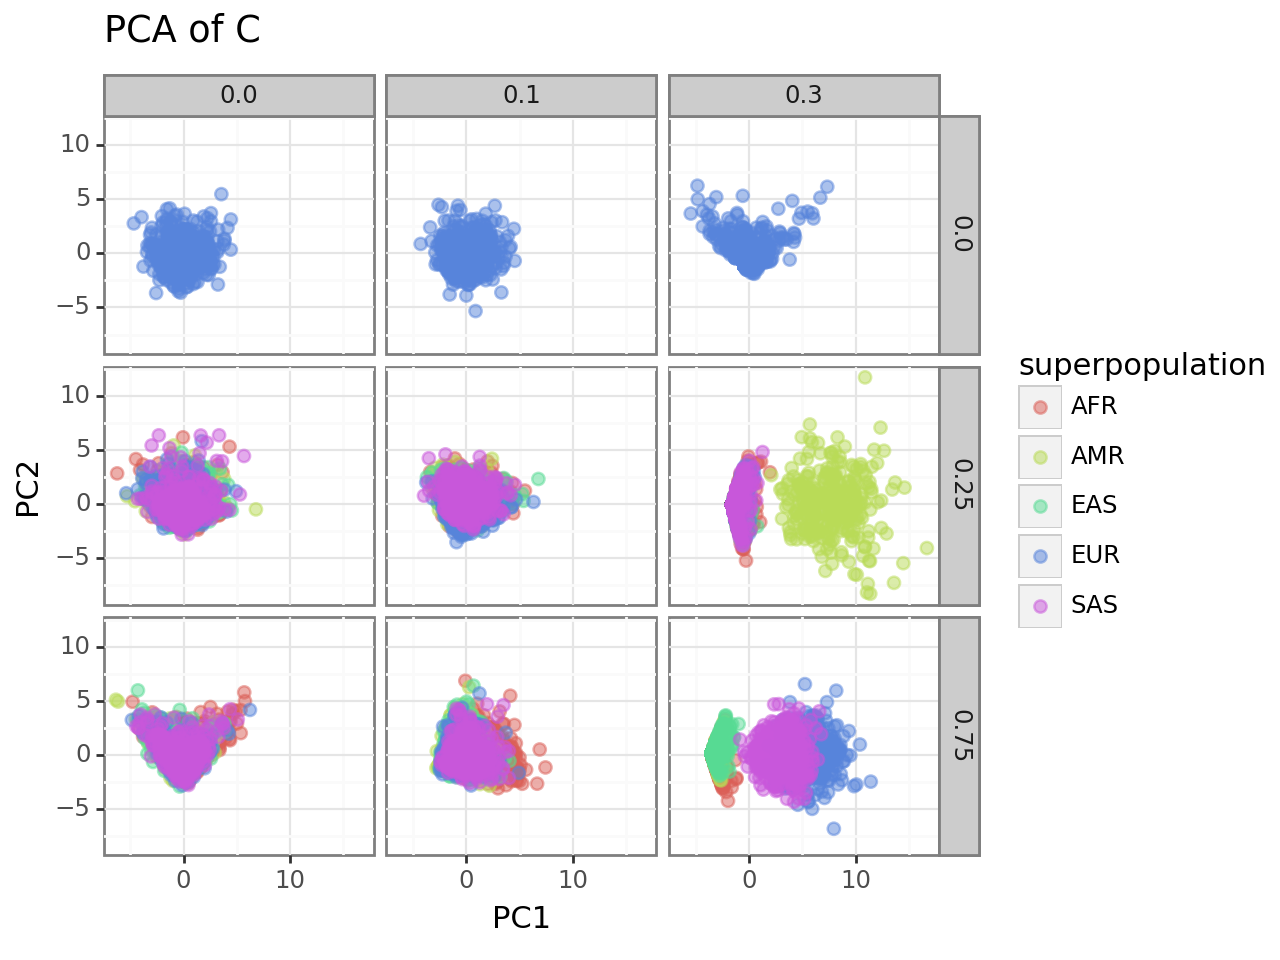

In [227]:
superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=1, dataset=0,matrix_name='C',type='superpopulation')

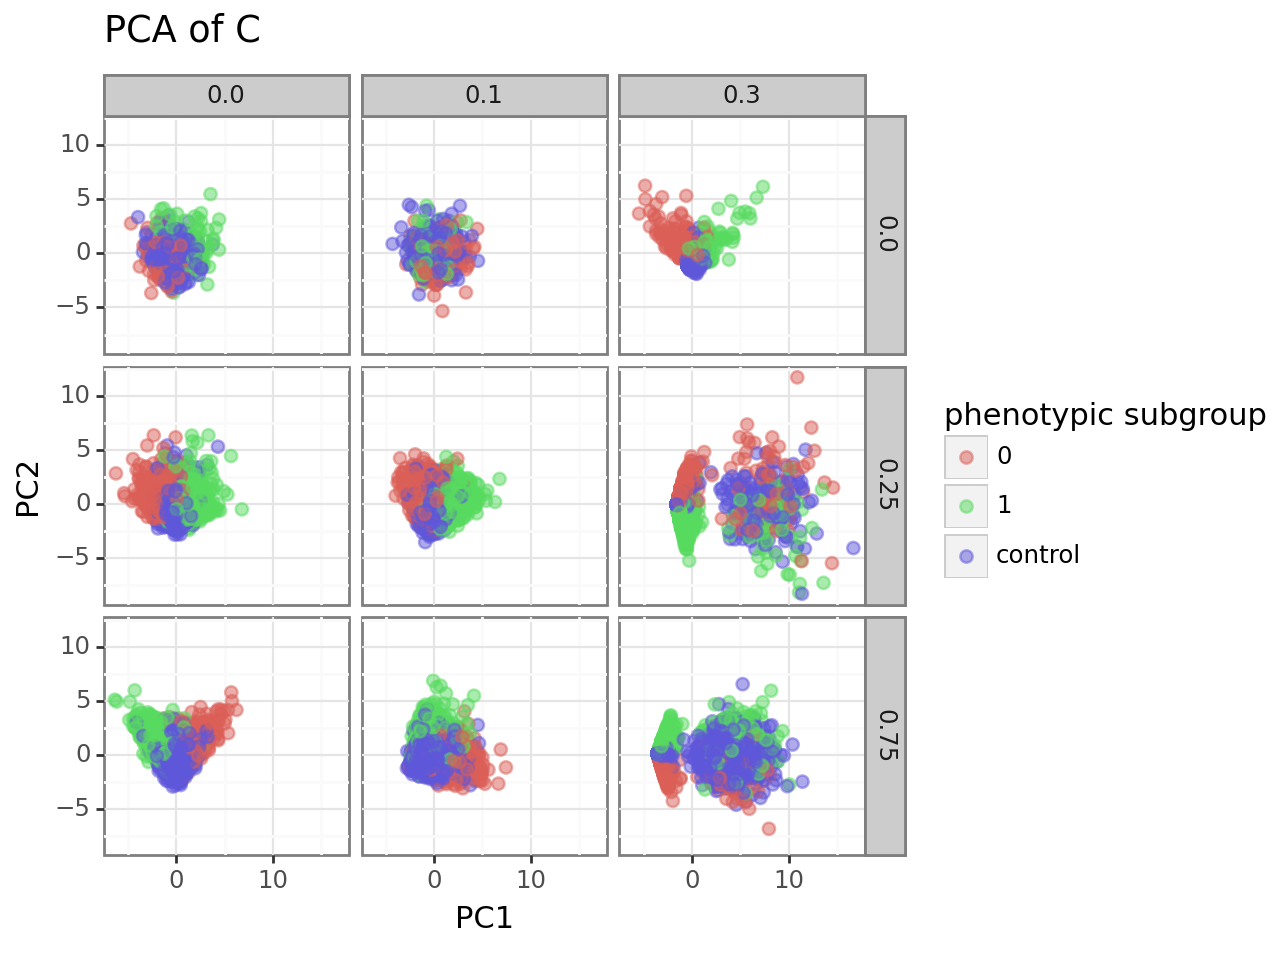

In [228]:
superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=1, dataset=0,matrix_name='C',type='phenotypic subgroup')

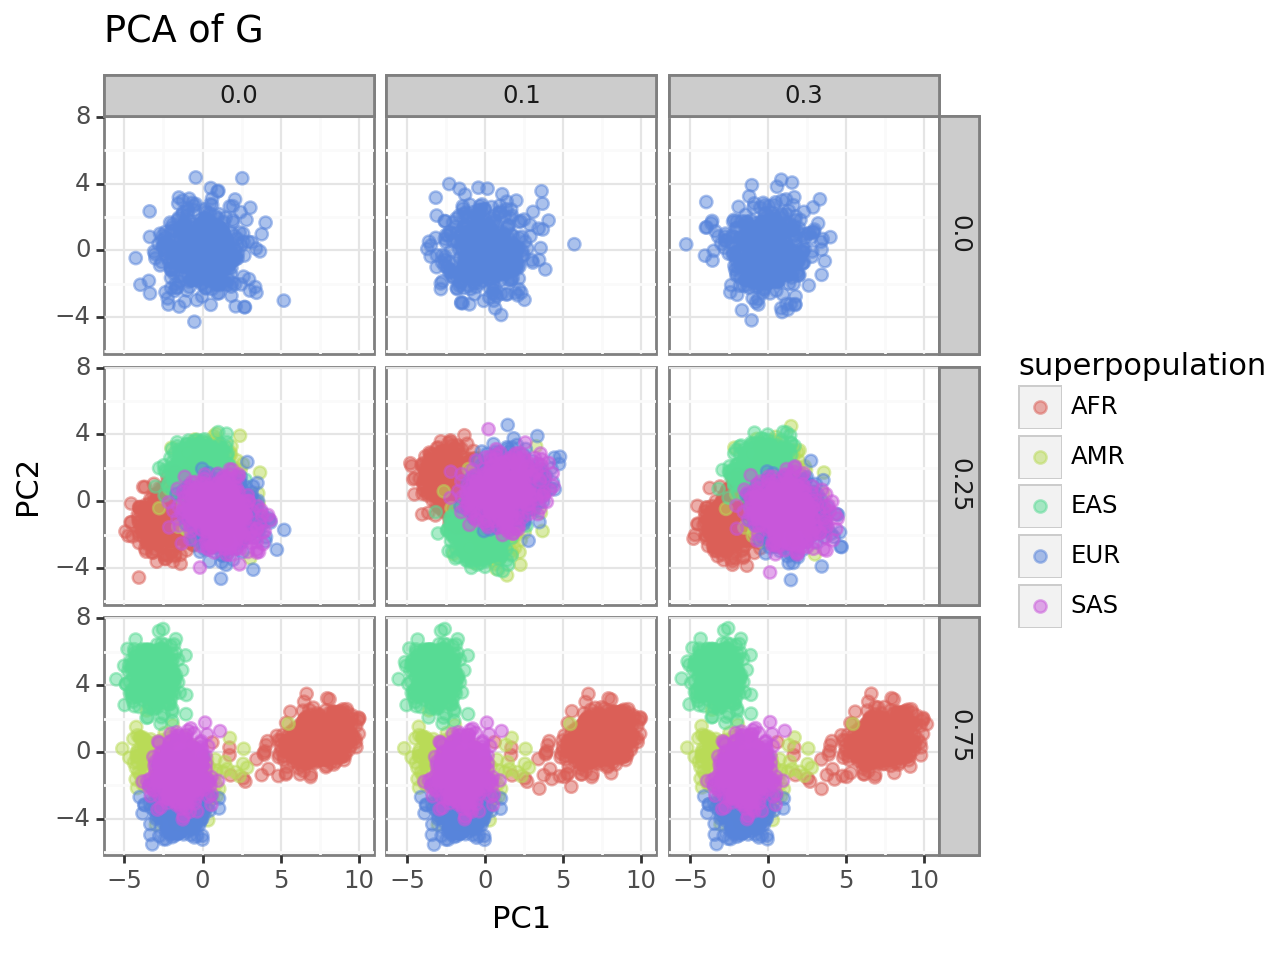

In [229]:
superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=1, dataset=0,matrix_name='G',type='superpopulation')

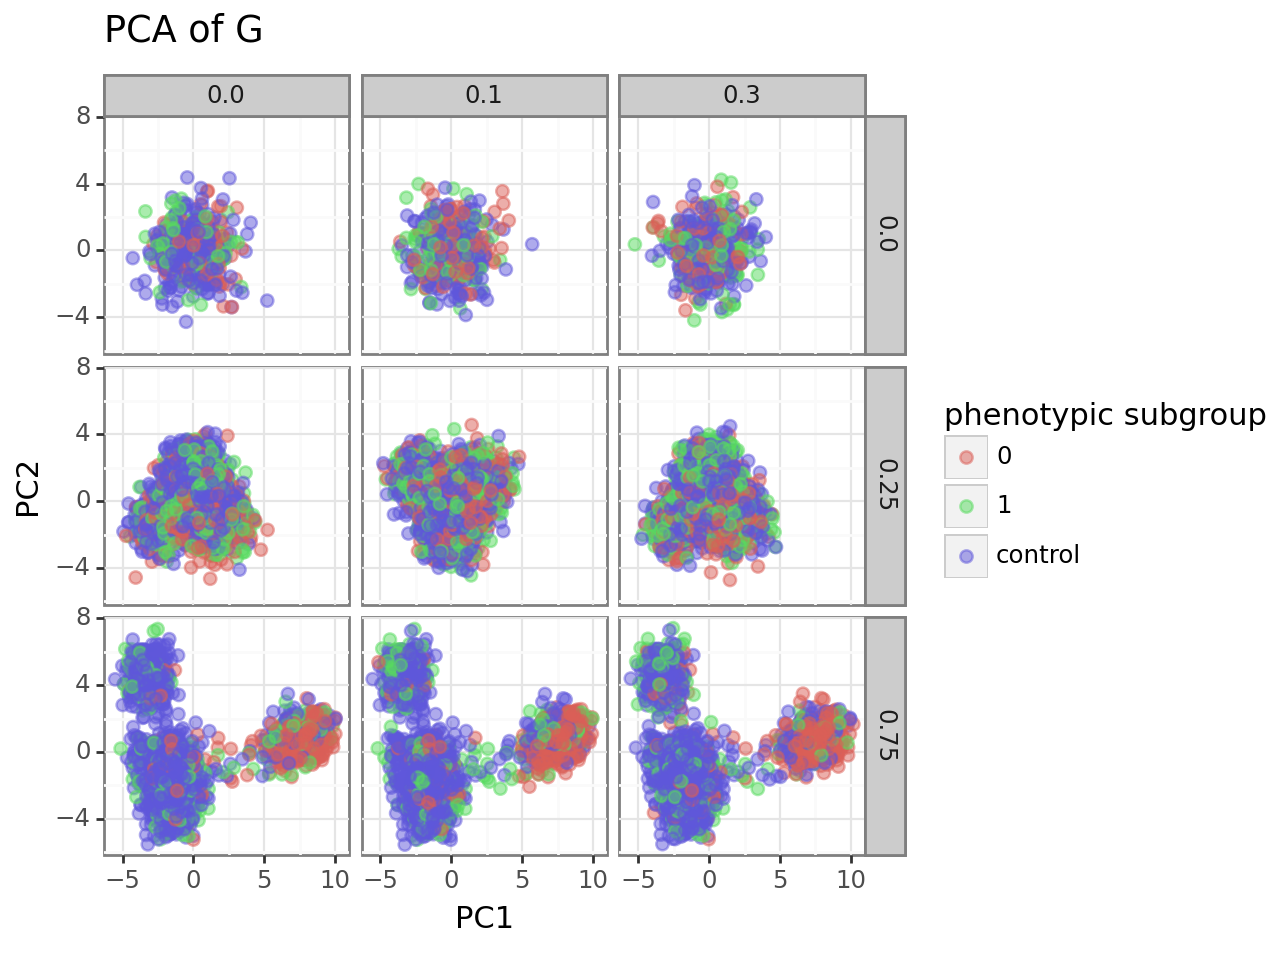

In [230]:
superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=1, dataset=0,matrix_name='G',type='phenotypic subgroup')

In [254]:
cut_points = both_subgroups.groupby('genetic_subgroup')['r'].quantile(0.8).to_dict()
cut_points

{0: 5.0, 1: 6.0}

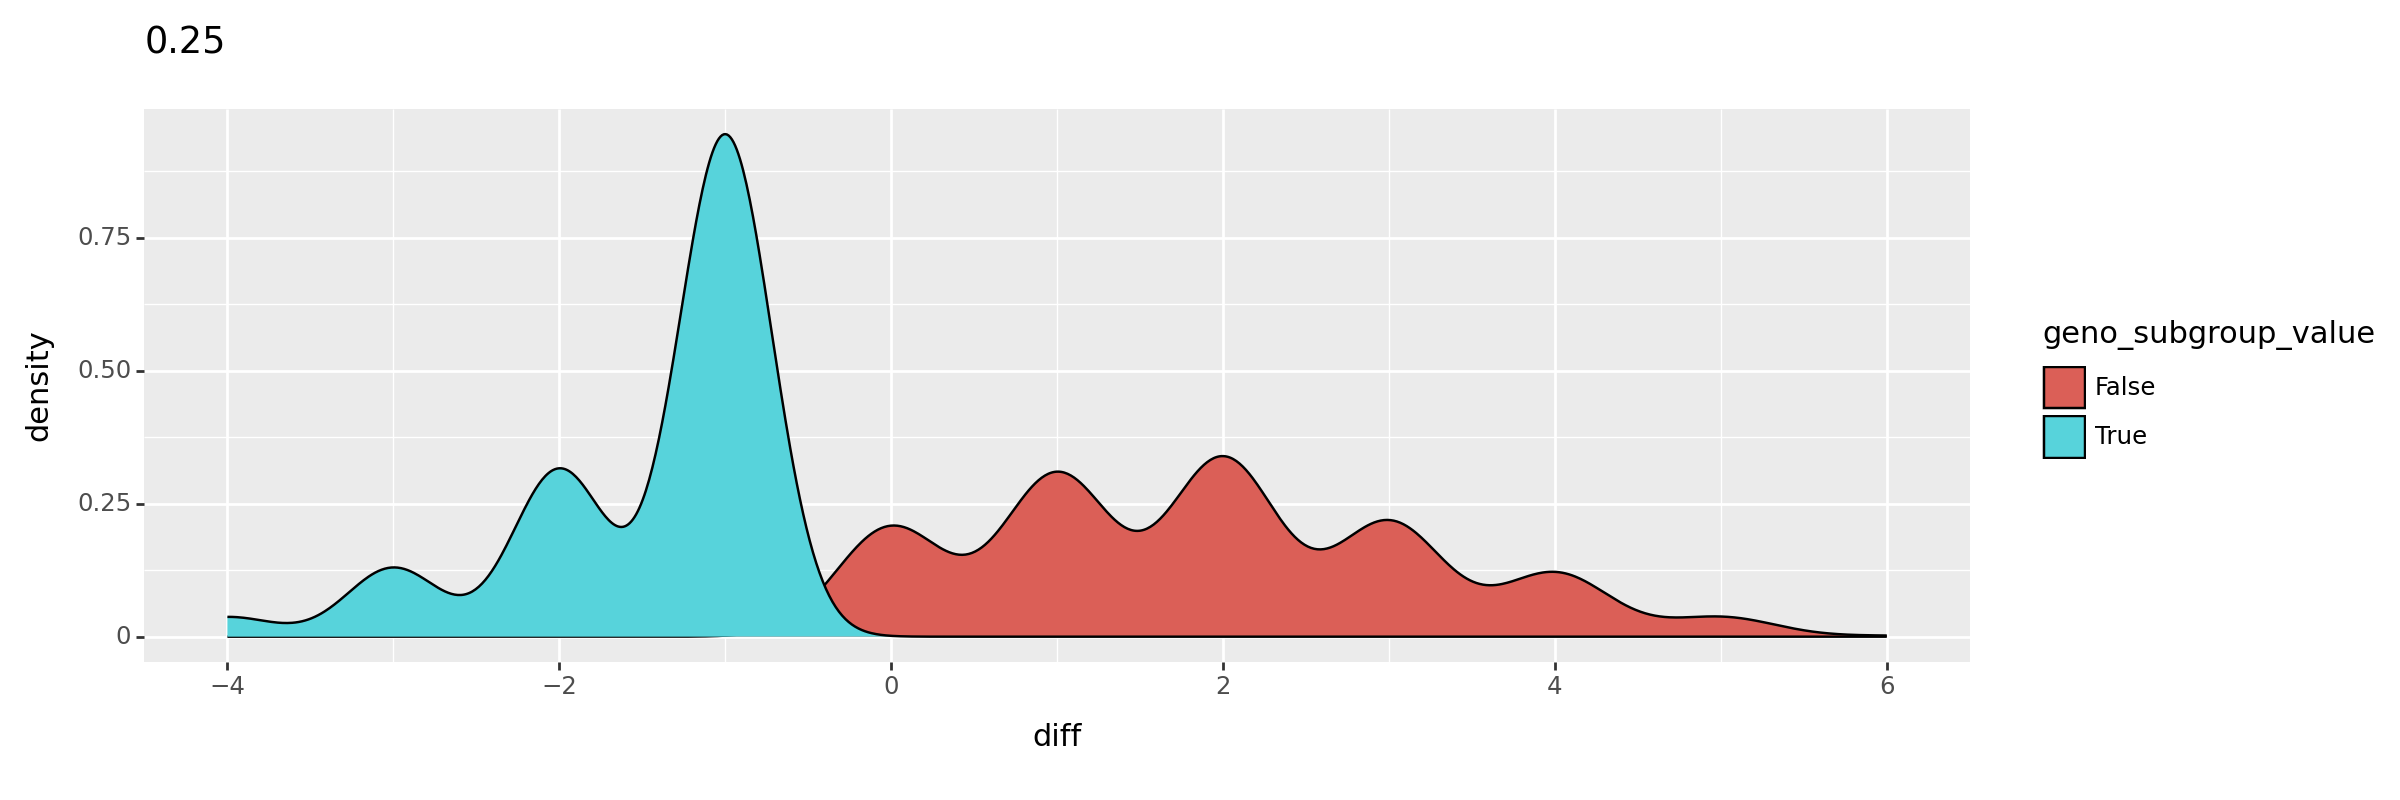

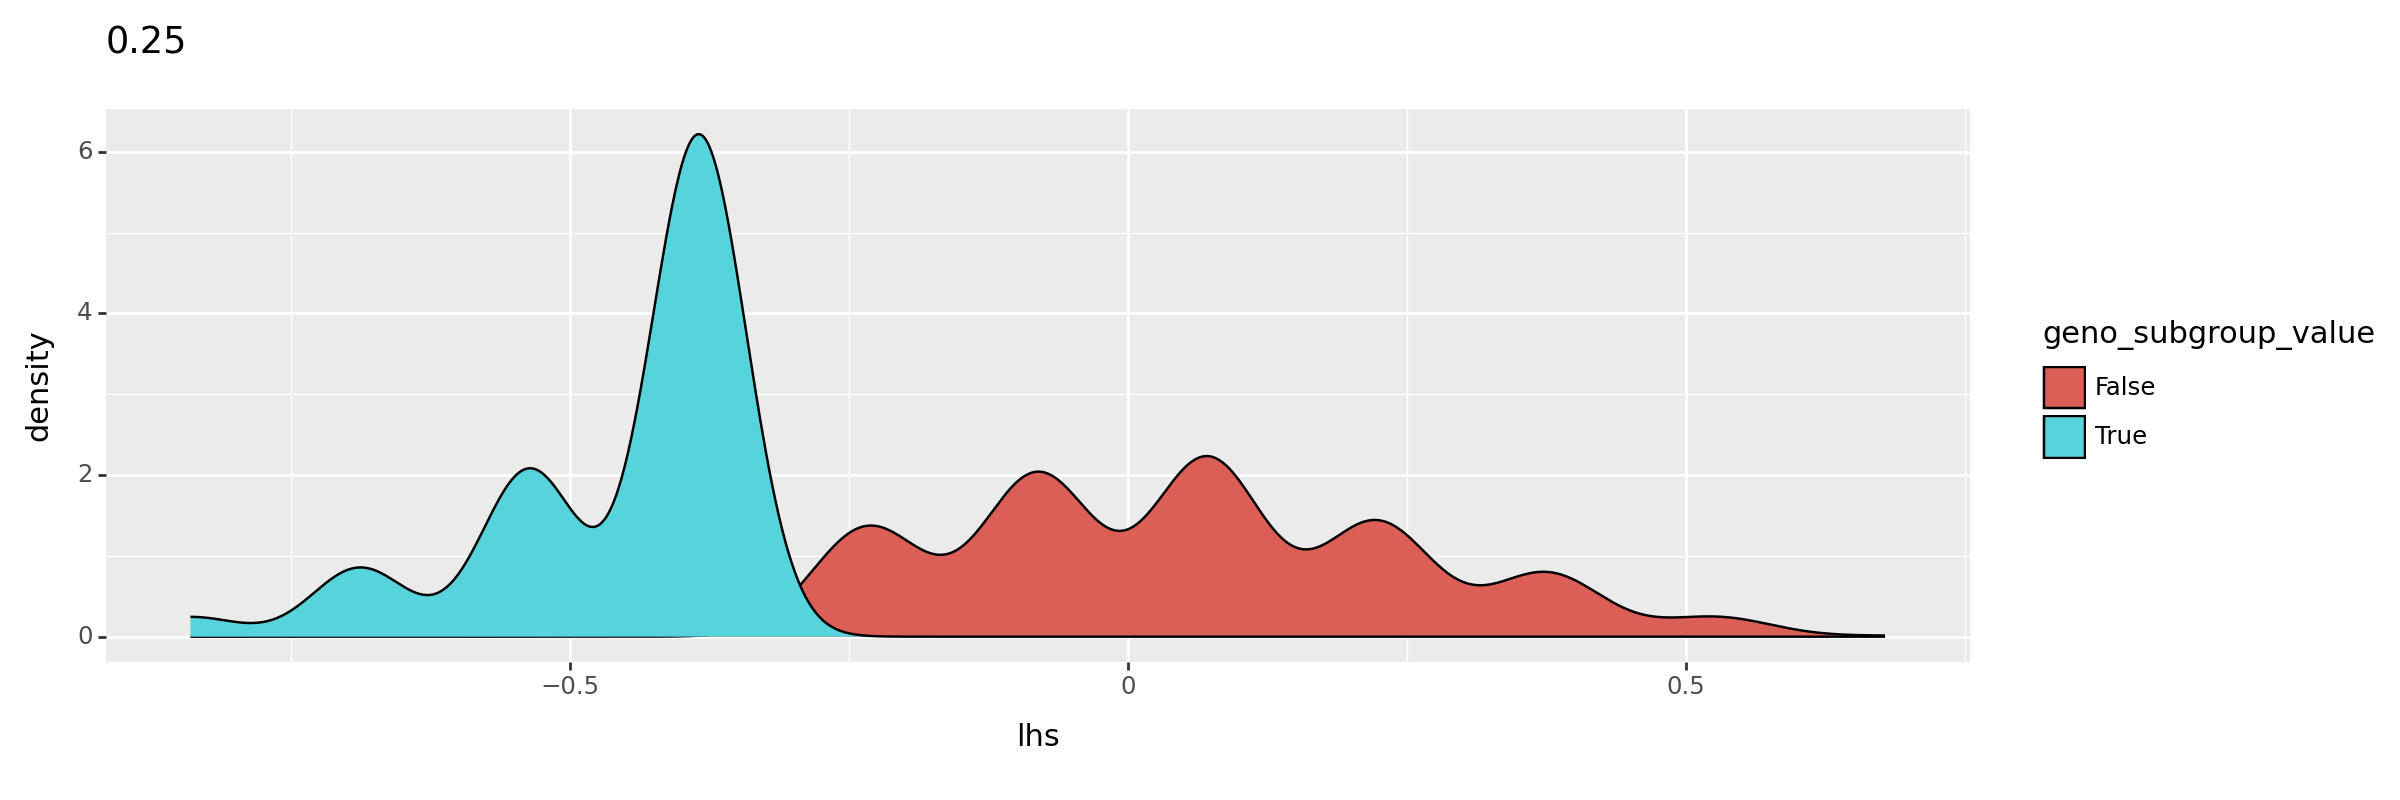

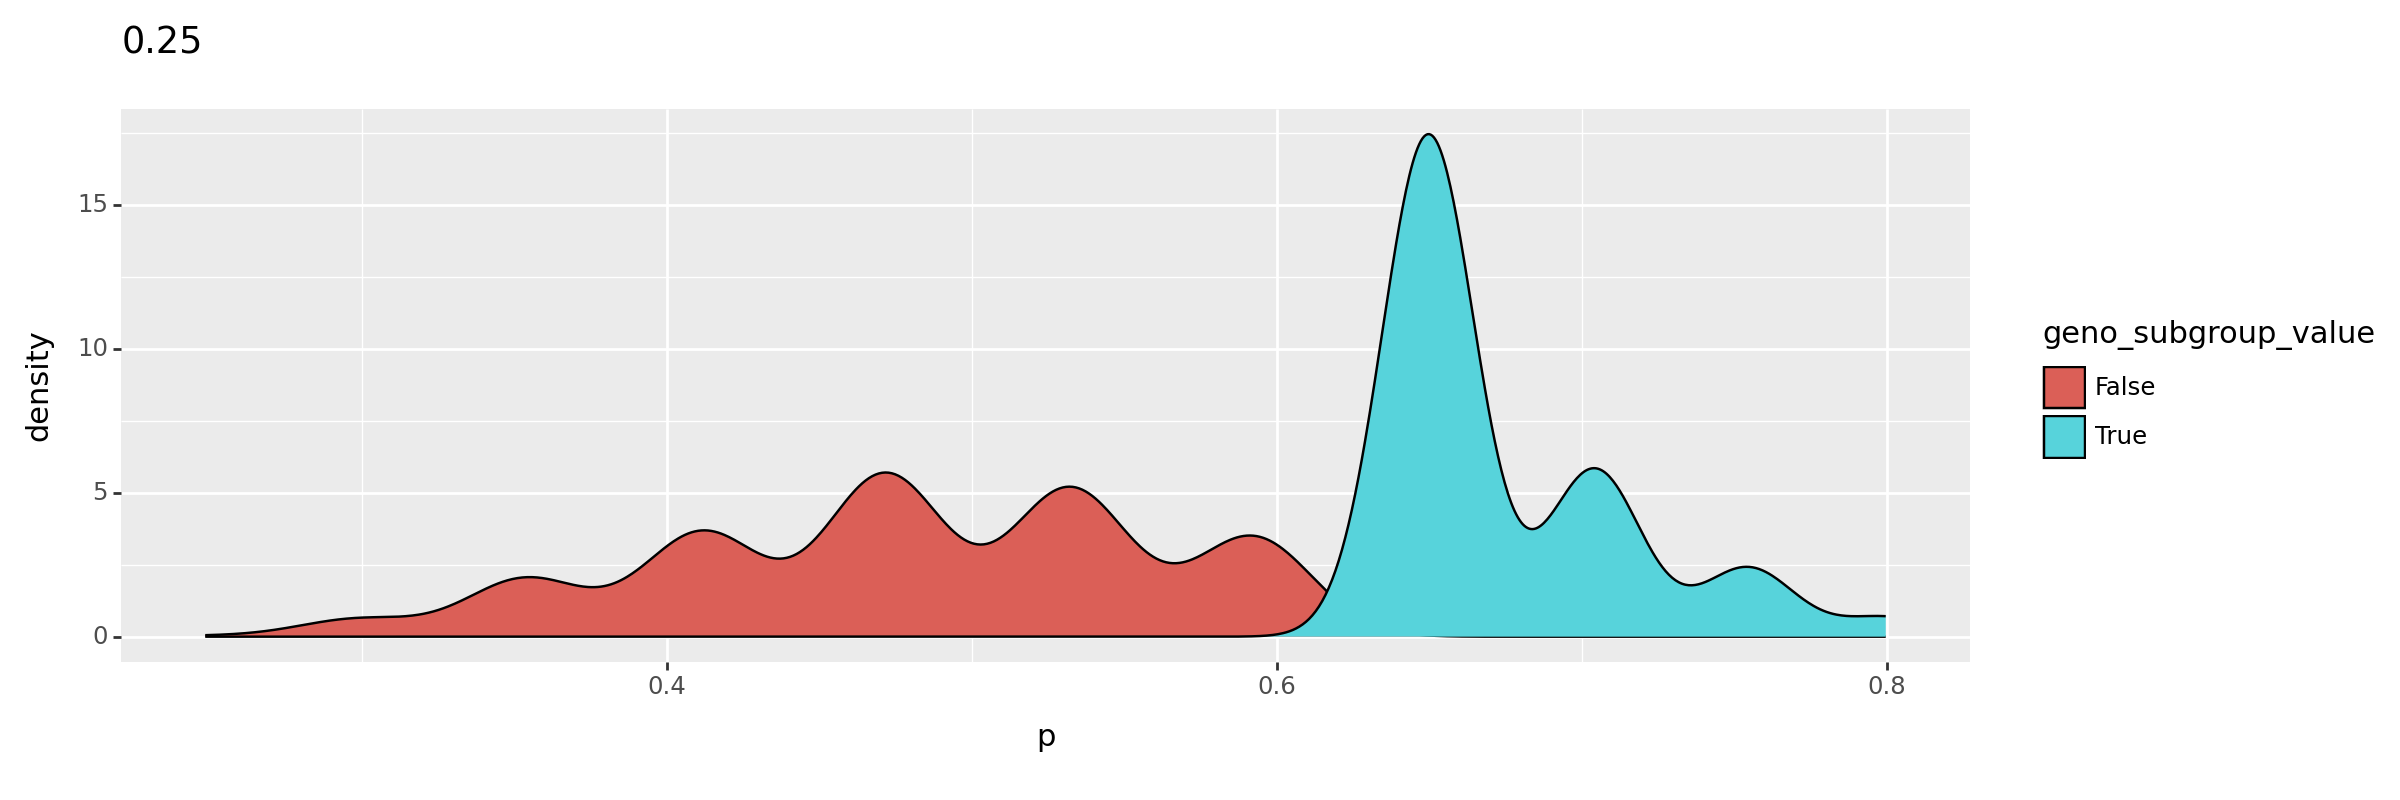

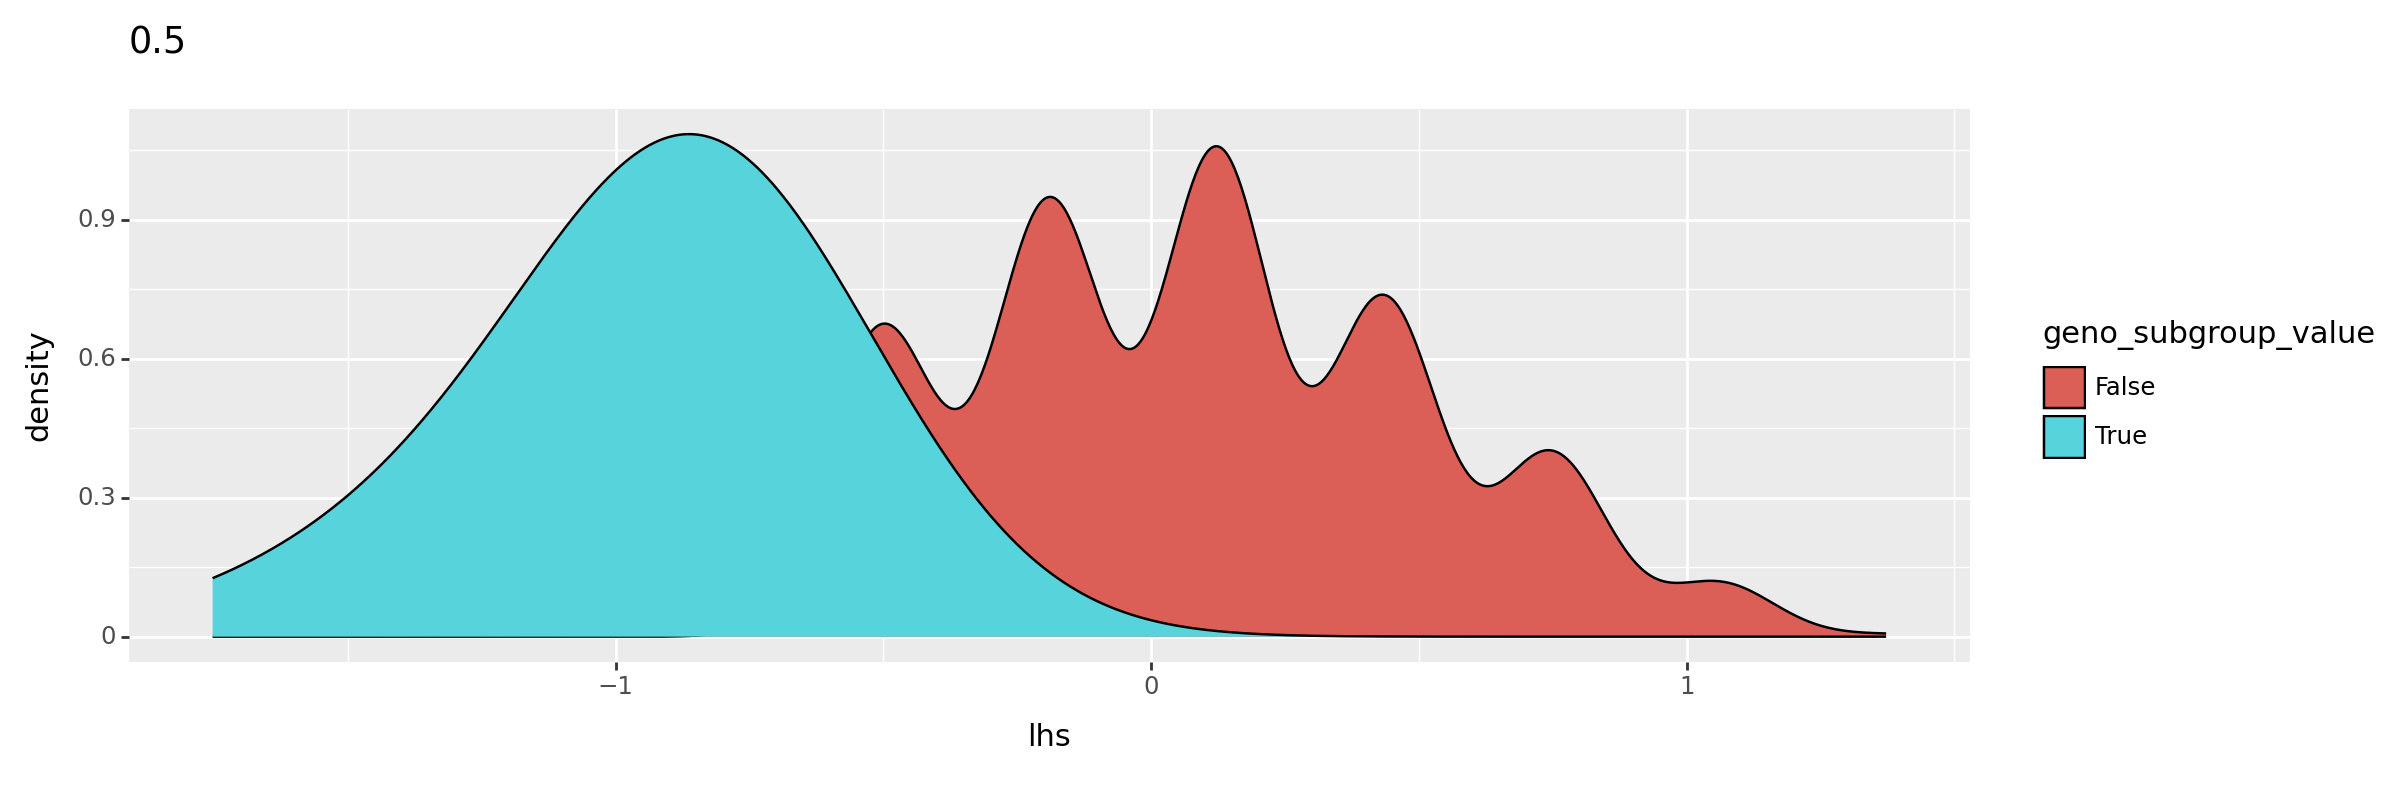

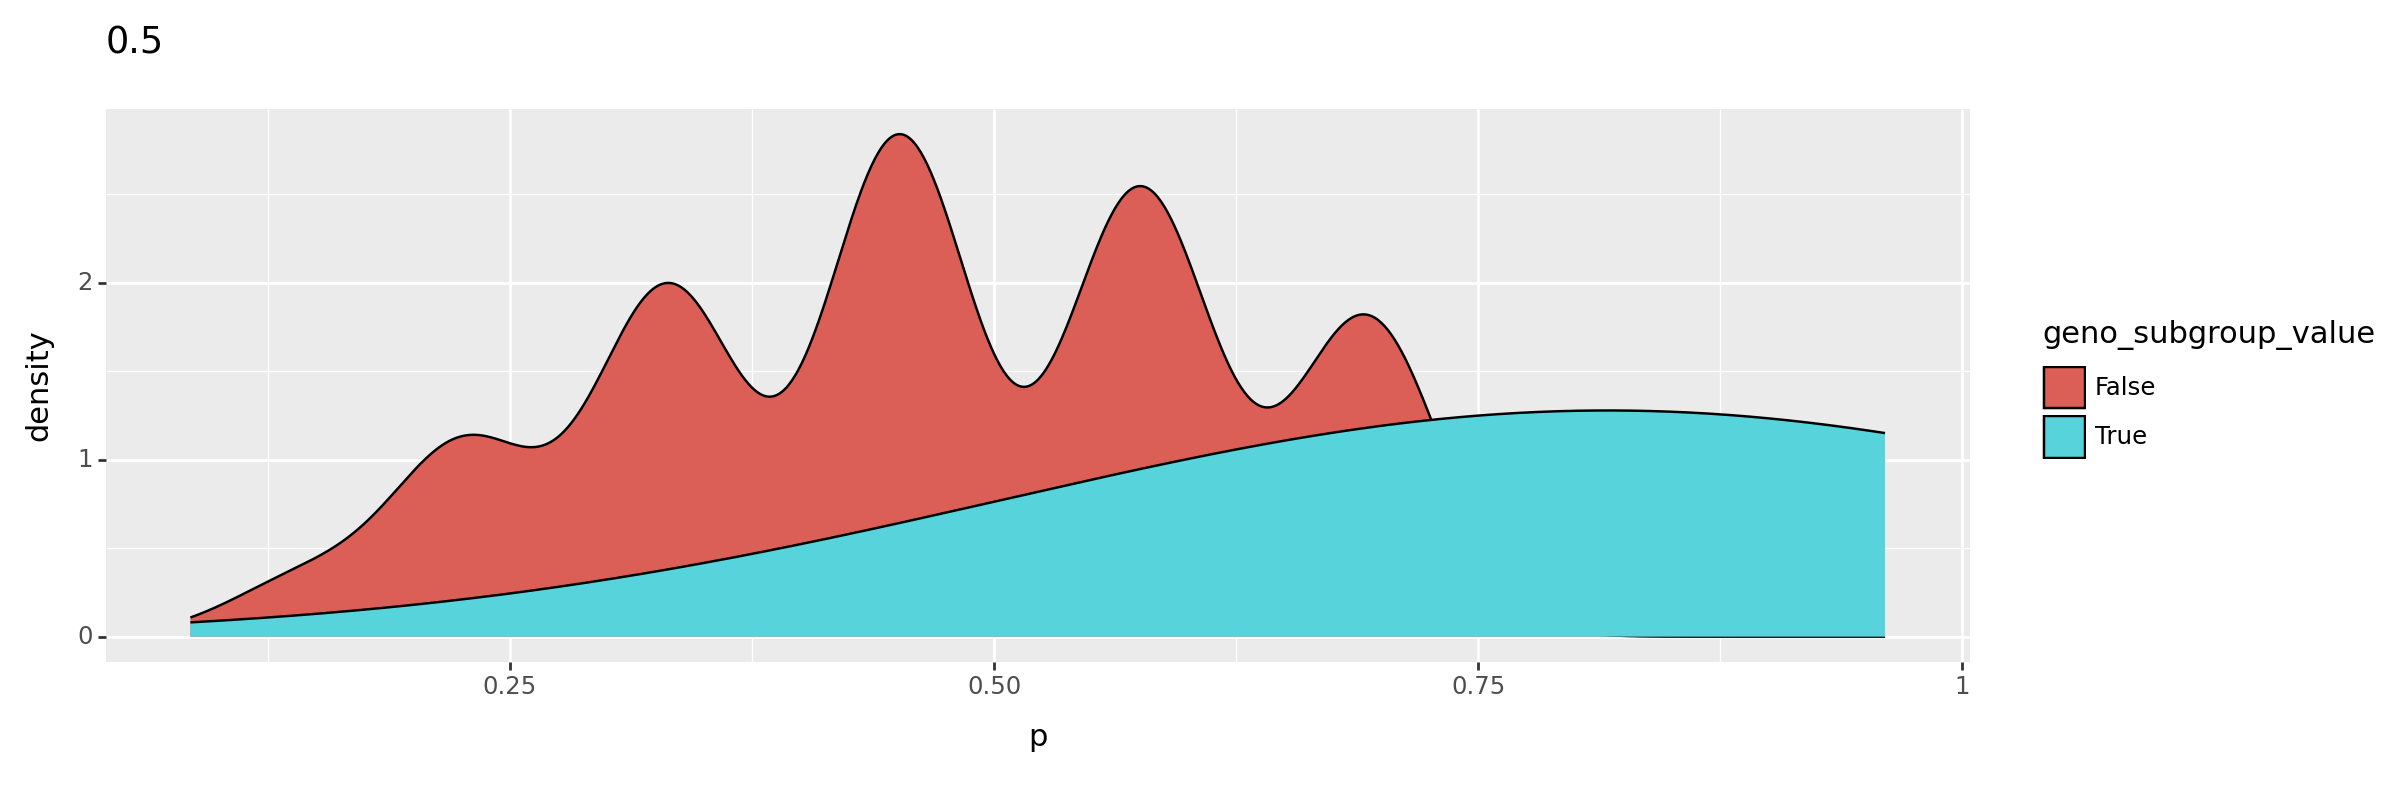

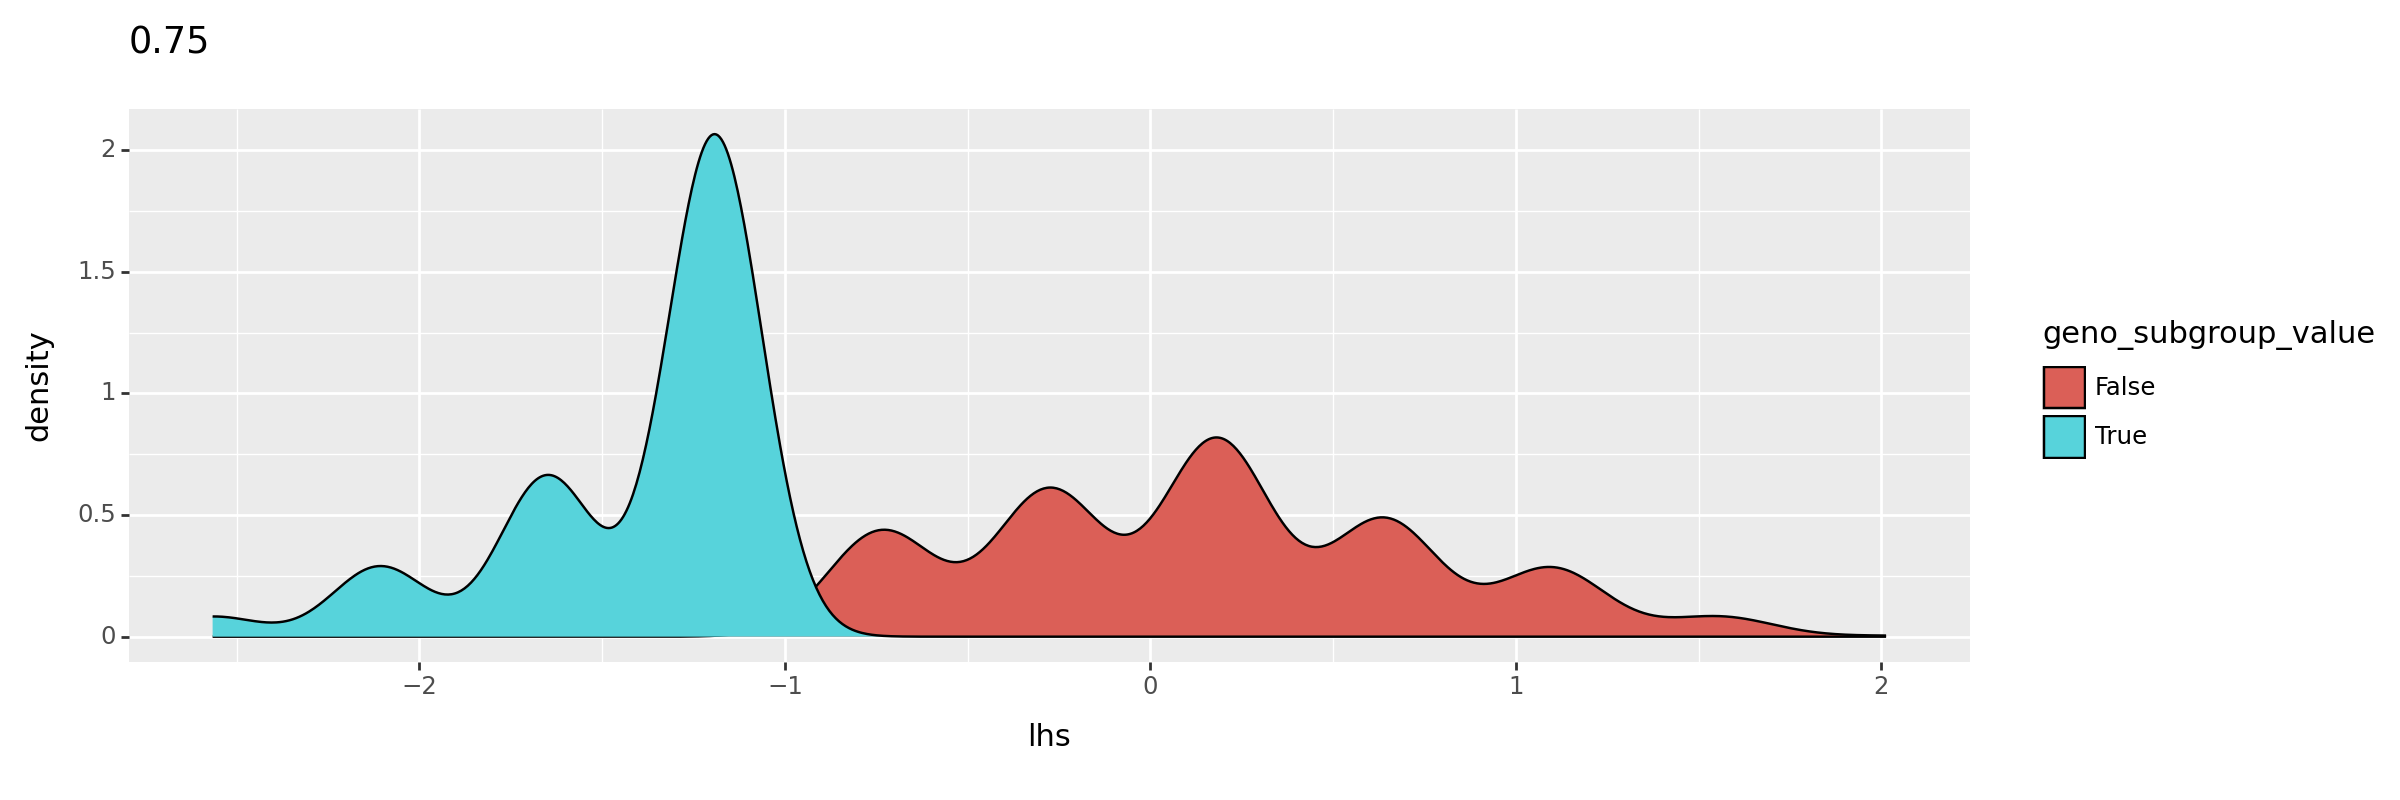

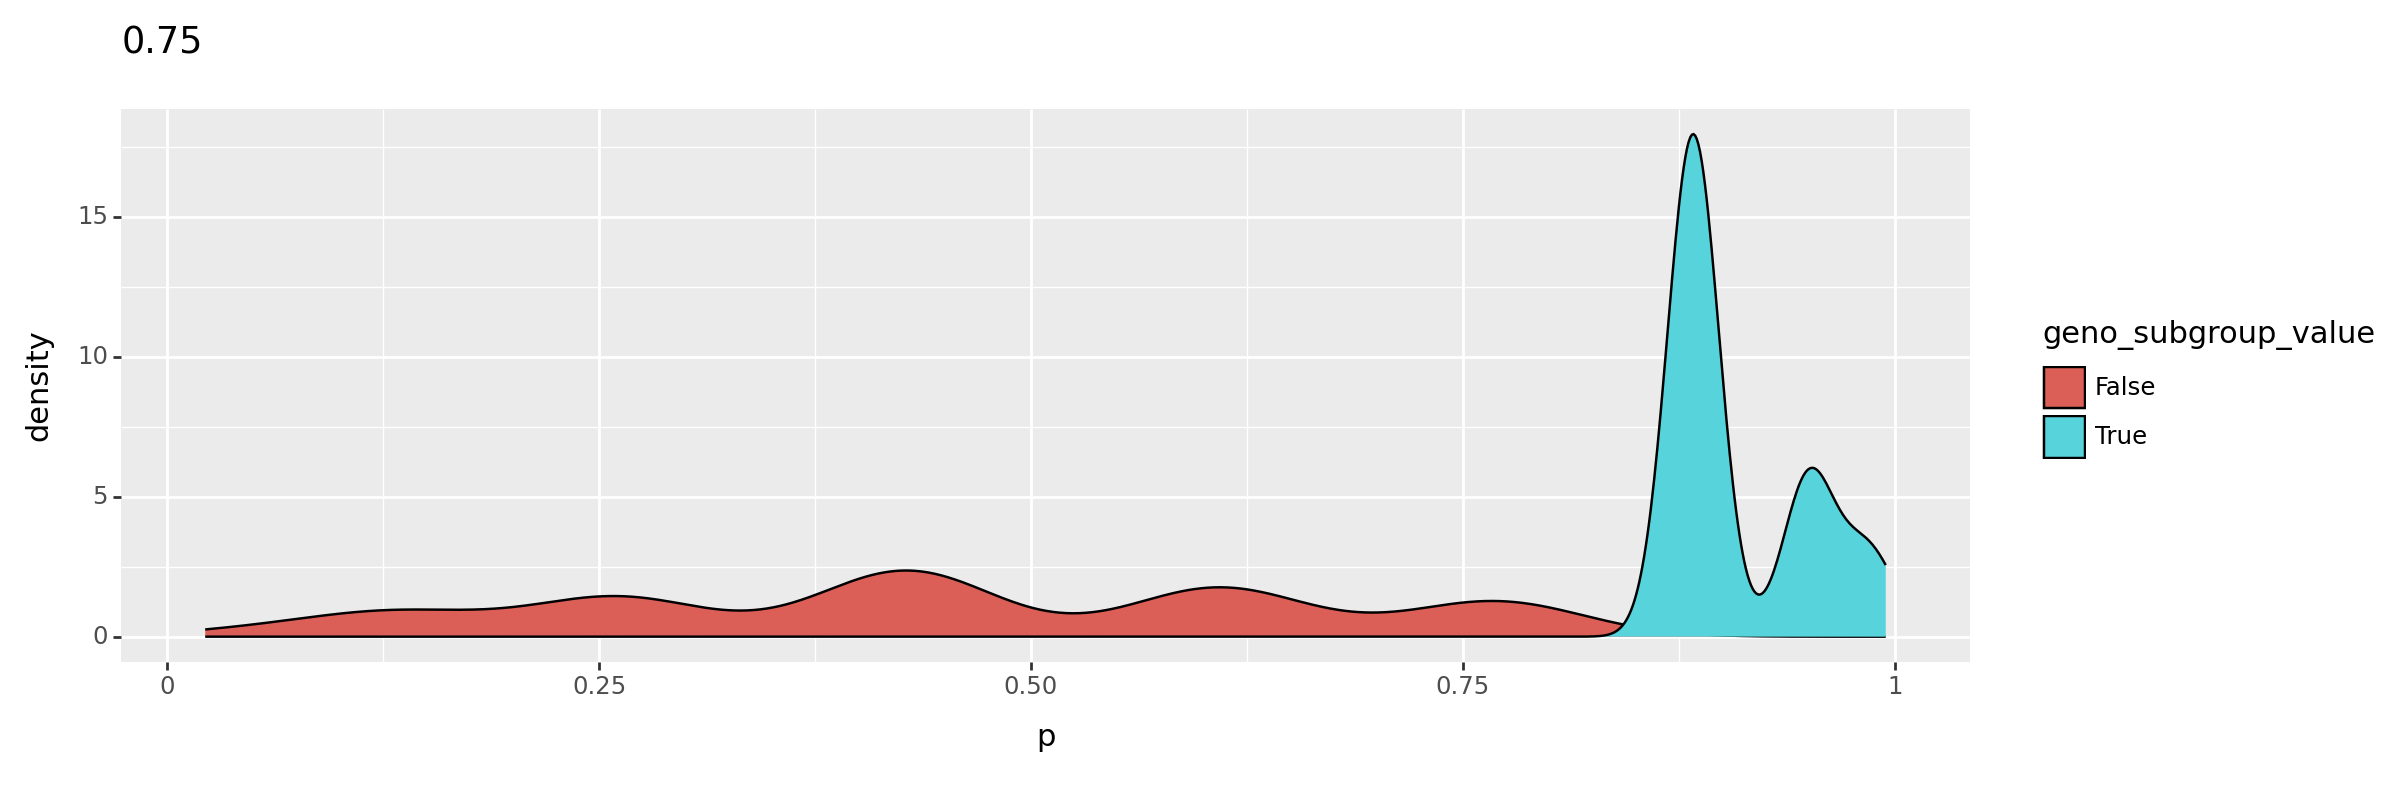

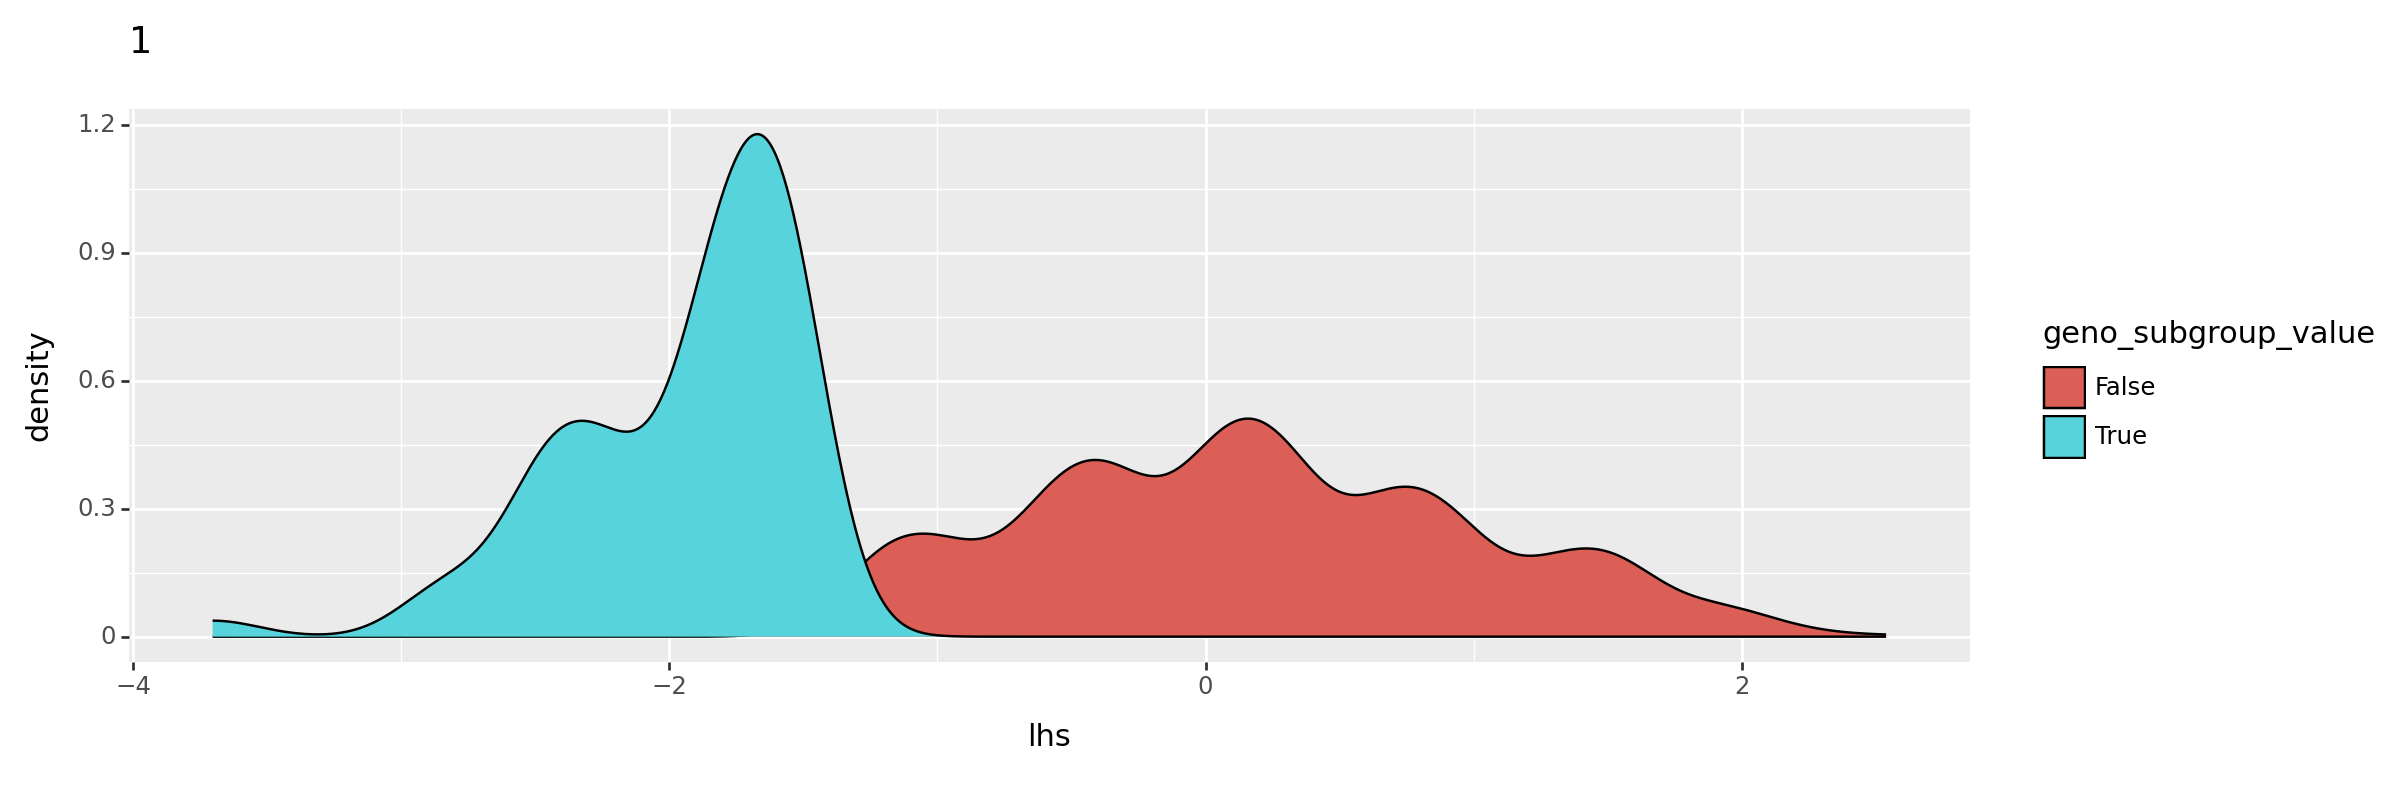

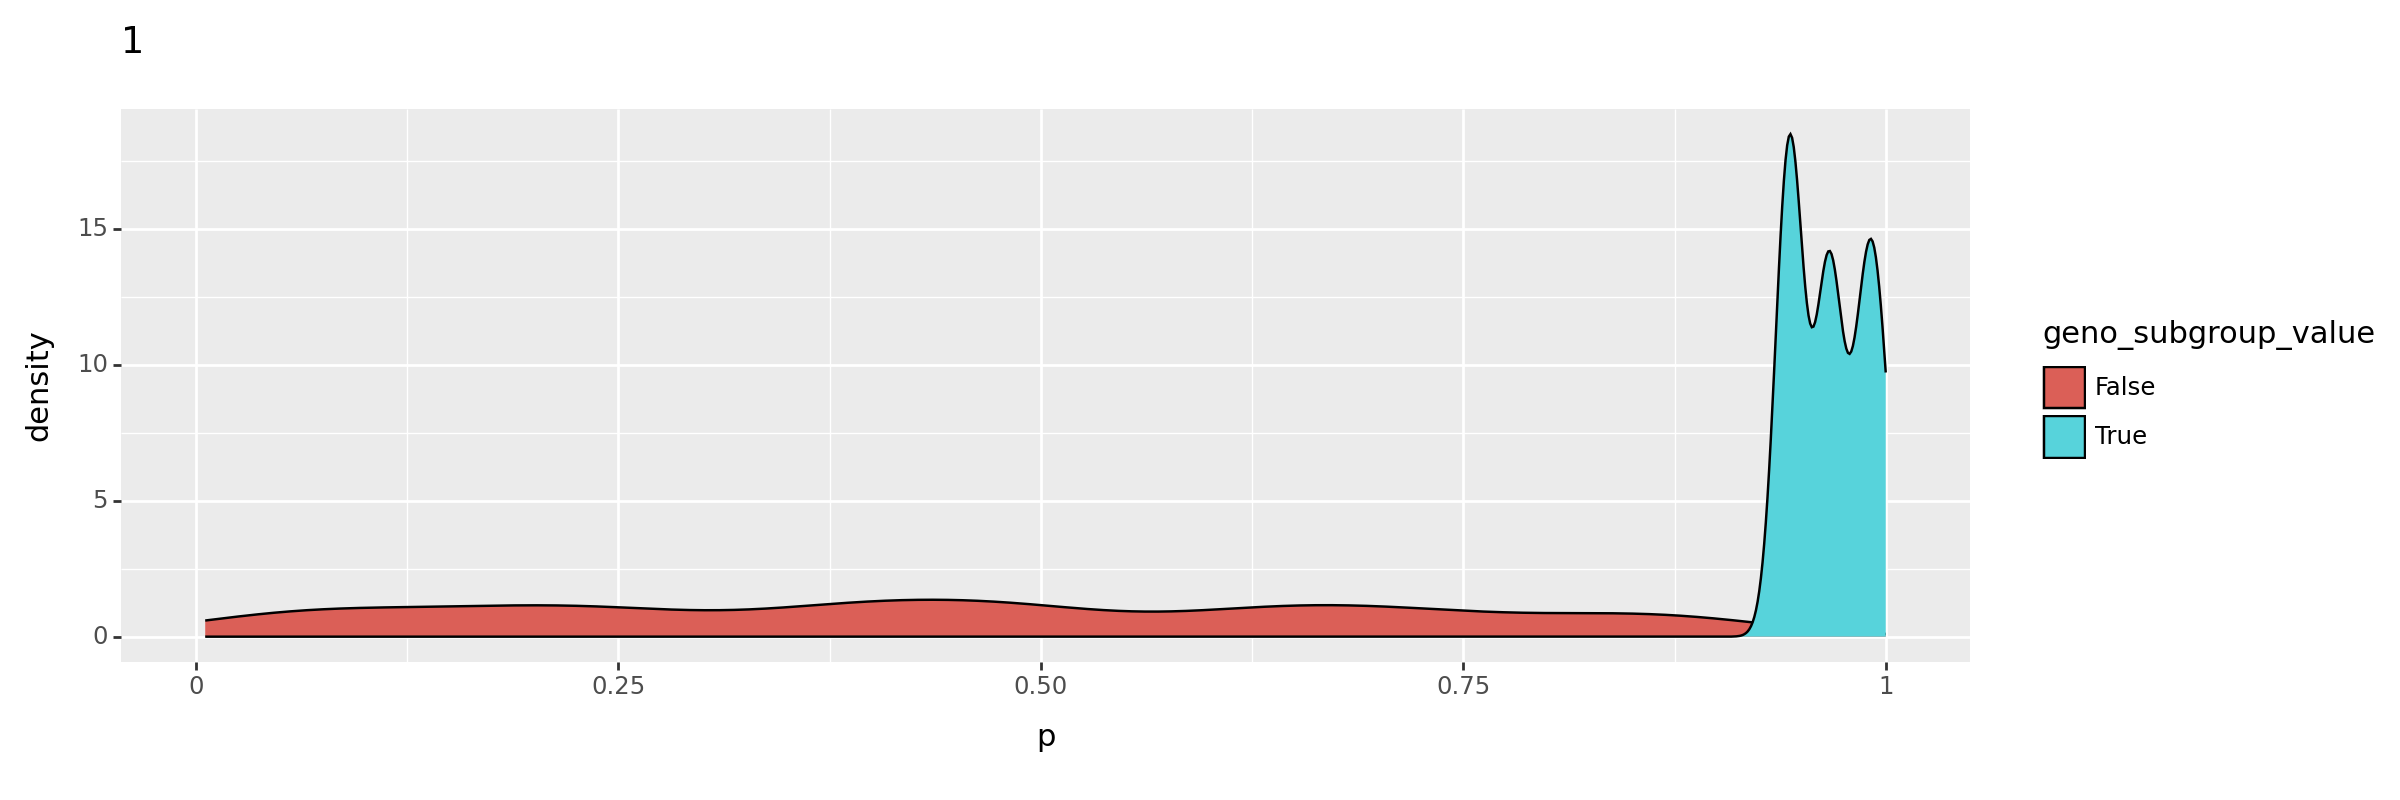

In [257]:
g_ps = 0
c_ps = 0
num_markers=100
from scipy.stats import norm
from scipy.stats import ks_2samp, wasserstein_distance, entropy

rows = []
rows_columns = ['e','dataset','ks']
for e in e_list:
    rv_coef_means = []
    for dataset in dataset_list:
        output_suffix = sim_functions.get_output_file_suffix(g_ps=g_ps, c_ps=c_ps, e=e, dataset=dataset)
        with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
                    simulation_metadata = pickle.load(f)
        if e==0.25 and dataset==0:
            baseline_markers_assoc=simulation_metadata['markers_assoc'].copy()
        assert set(baseline_markers_assoc[0])==set(simulation_metadata['markers_assoc'][0])
        assert set(baseline_markers_assoc[1])==set(simulation_metadata['markers_assoc'][1])
        # try G and C row-wise correlation
        G = np.loadtxt(f'{sim_output_dir}/G_{output_suffix}.raw',  usecols=range(6, num_markers+6), dtype=np.int64, skiprows=1)
        C = np.load(f'{sim_output_dir}/C_{output_suffix}.npy')
        # get iids in subgroup
        fam_df = pd.read_csv(f'{sim_output_dir}/G_{output_suffix}.fam',sep='\s+',header=None) 
        fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
        phenotypic_subgroups = simulation_metadata['phenotypic_subgroups'].copy()
        phenotypic_subgroups = phenotypic_subgroups[(phenotypic_subgroups['phenotypic_subgroup'].isin([0,1]))].copy()
        phenotypic_subgroups['r'] = phenotypic_subgroups['r'].astype(int)
        phenotypic_subgroups = phenotypic_subgroups.sort_values('IID', key=lambda x: pd.Categorical(x, categories=fam_df['IID'].values, ordered=True))
        iids = phenotypic_subgroups[phenotypic_subgroups['subgroup']]['IID'].unique().tolist()
        genetic_subgroups = simulation_metadata['genetic_subgroups'].copy()
        both_subgroups = phenotypic_subgroups.rename(columns={'subgroup':'pheno_subgroup_value'}).merge(genetic_subgroups[['IID','genetic_subgroup','subgroup']].rename(columns={'subgroup':'geno_subgroup_value'}),how='inner',on=['IID'])
        both_subgroups = both_subgroups[both_subgroups['phenotypic_subgroup']==both_subgroups['genetic_subgroup']].copy()
        iid_index = fam_df[fam_df['IID'].isin(iids)].index # some samples removed due to overlap btwn subgroups, need correct length
        sample_wise_corr = []
        for i in iid_index:
            sample_wise_corr.append(np.corrcoef(G[i,:], C[i,:])[0, 1])

        if dataset==0:
            # print((ggplot(phenotypic_subgroups, aes(x='r', fill='subgroup')) +
            # geom_histogram(binwidth=1, color='black')+labs(title=e)))
            cut_points = both_subgroups.groupby('genetic_subgroup')['r'].quantile(0.8).to_dict()
            both_subgroups['abs_diff'] = both_subgroups.apply(lambda x: np.abs(cut_points[x['genetic_subgroup']]-x['r']),axis=1)
            both_subgroups['diff'] = both_subgroups.apply(lambda x: cut_points[x['genetic_subgroup']]-x['r'],axis=1)
            both_subgroups['col_z'] = (both_subgroups['diff'] - both_subgroups['diff'].mean()) / both_subgroups['diff'].std()
            if e==0.25:
                print((ggplot(both_subgroups, aes(x='diff', fill='geno_subgroup_value')) +
                geom_density(color='black')+labs(title=e)+theme(figure_size=(12,4))))
            both_subgroups['lhs'] = both_subgroups.apply(lambda x:(1/1)*(x['col_z'])*e, axis=1)
            print((ggplot(both_subgroups, aes(x='lhs', fill='geno_subgroup_value')) +
            geom_density(color='black')+labs(title=e)+theme(figure_size=(12,4))))

            # get prob
            both_subgroups['p'] = both_subgroups['lhs'].apply(lambda x: norm.sf(x))
            print((ggplot(both_subgroups, aes(x='p', fill='geno_subgroup_value')) +
            geom_density(color='black')+labs(title=e)+theme(figure_size=(12,4))))

        a = both_subgroups[both_subgroups['pheno_subgroup_value']==True]['r'].values.tolist()
        b = both_subgroups[both_subgroups['pheno_subgroup_value']==False]['r'].values.tolist()
        rows.append([e,dataset,ks_2samp(a, b).statistic])
    #print(f'e {e}, mean sample-wise corr: {np.mean(sample_wise_corr)}; ks {ks_2samp(a, b).statistic}')
df = pd.DataFrame(rows,columns=rows_columns)

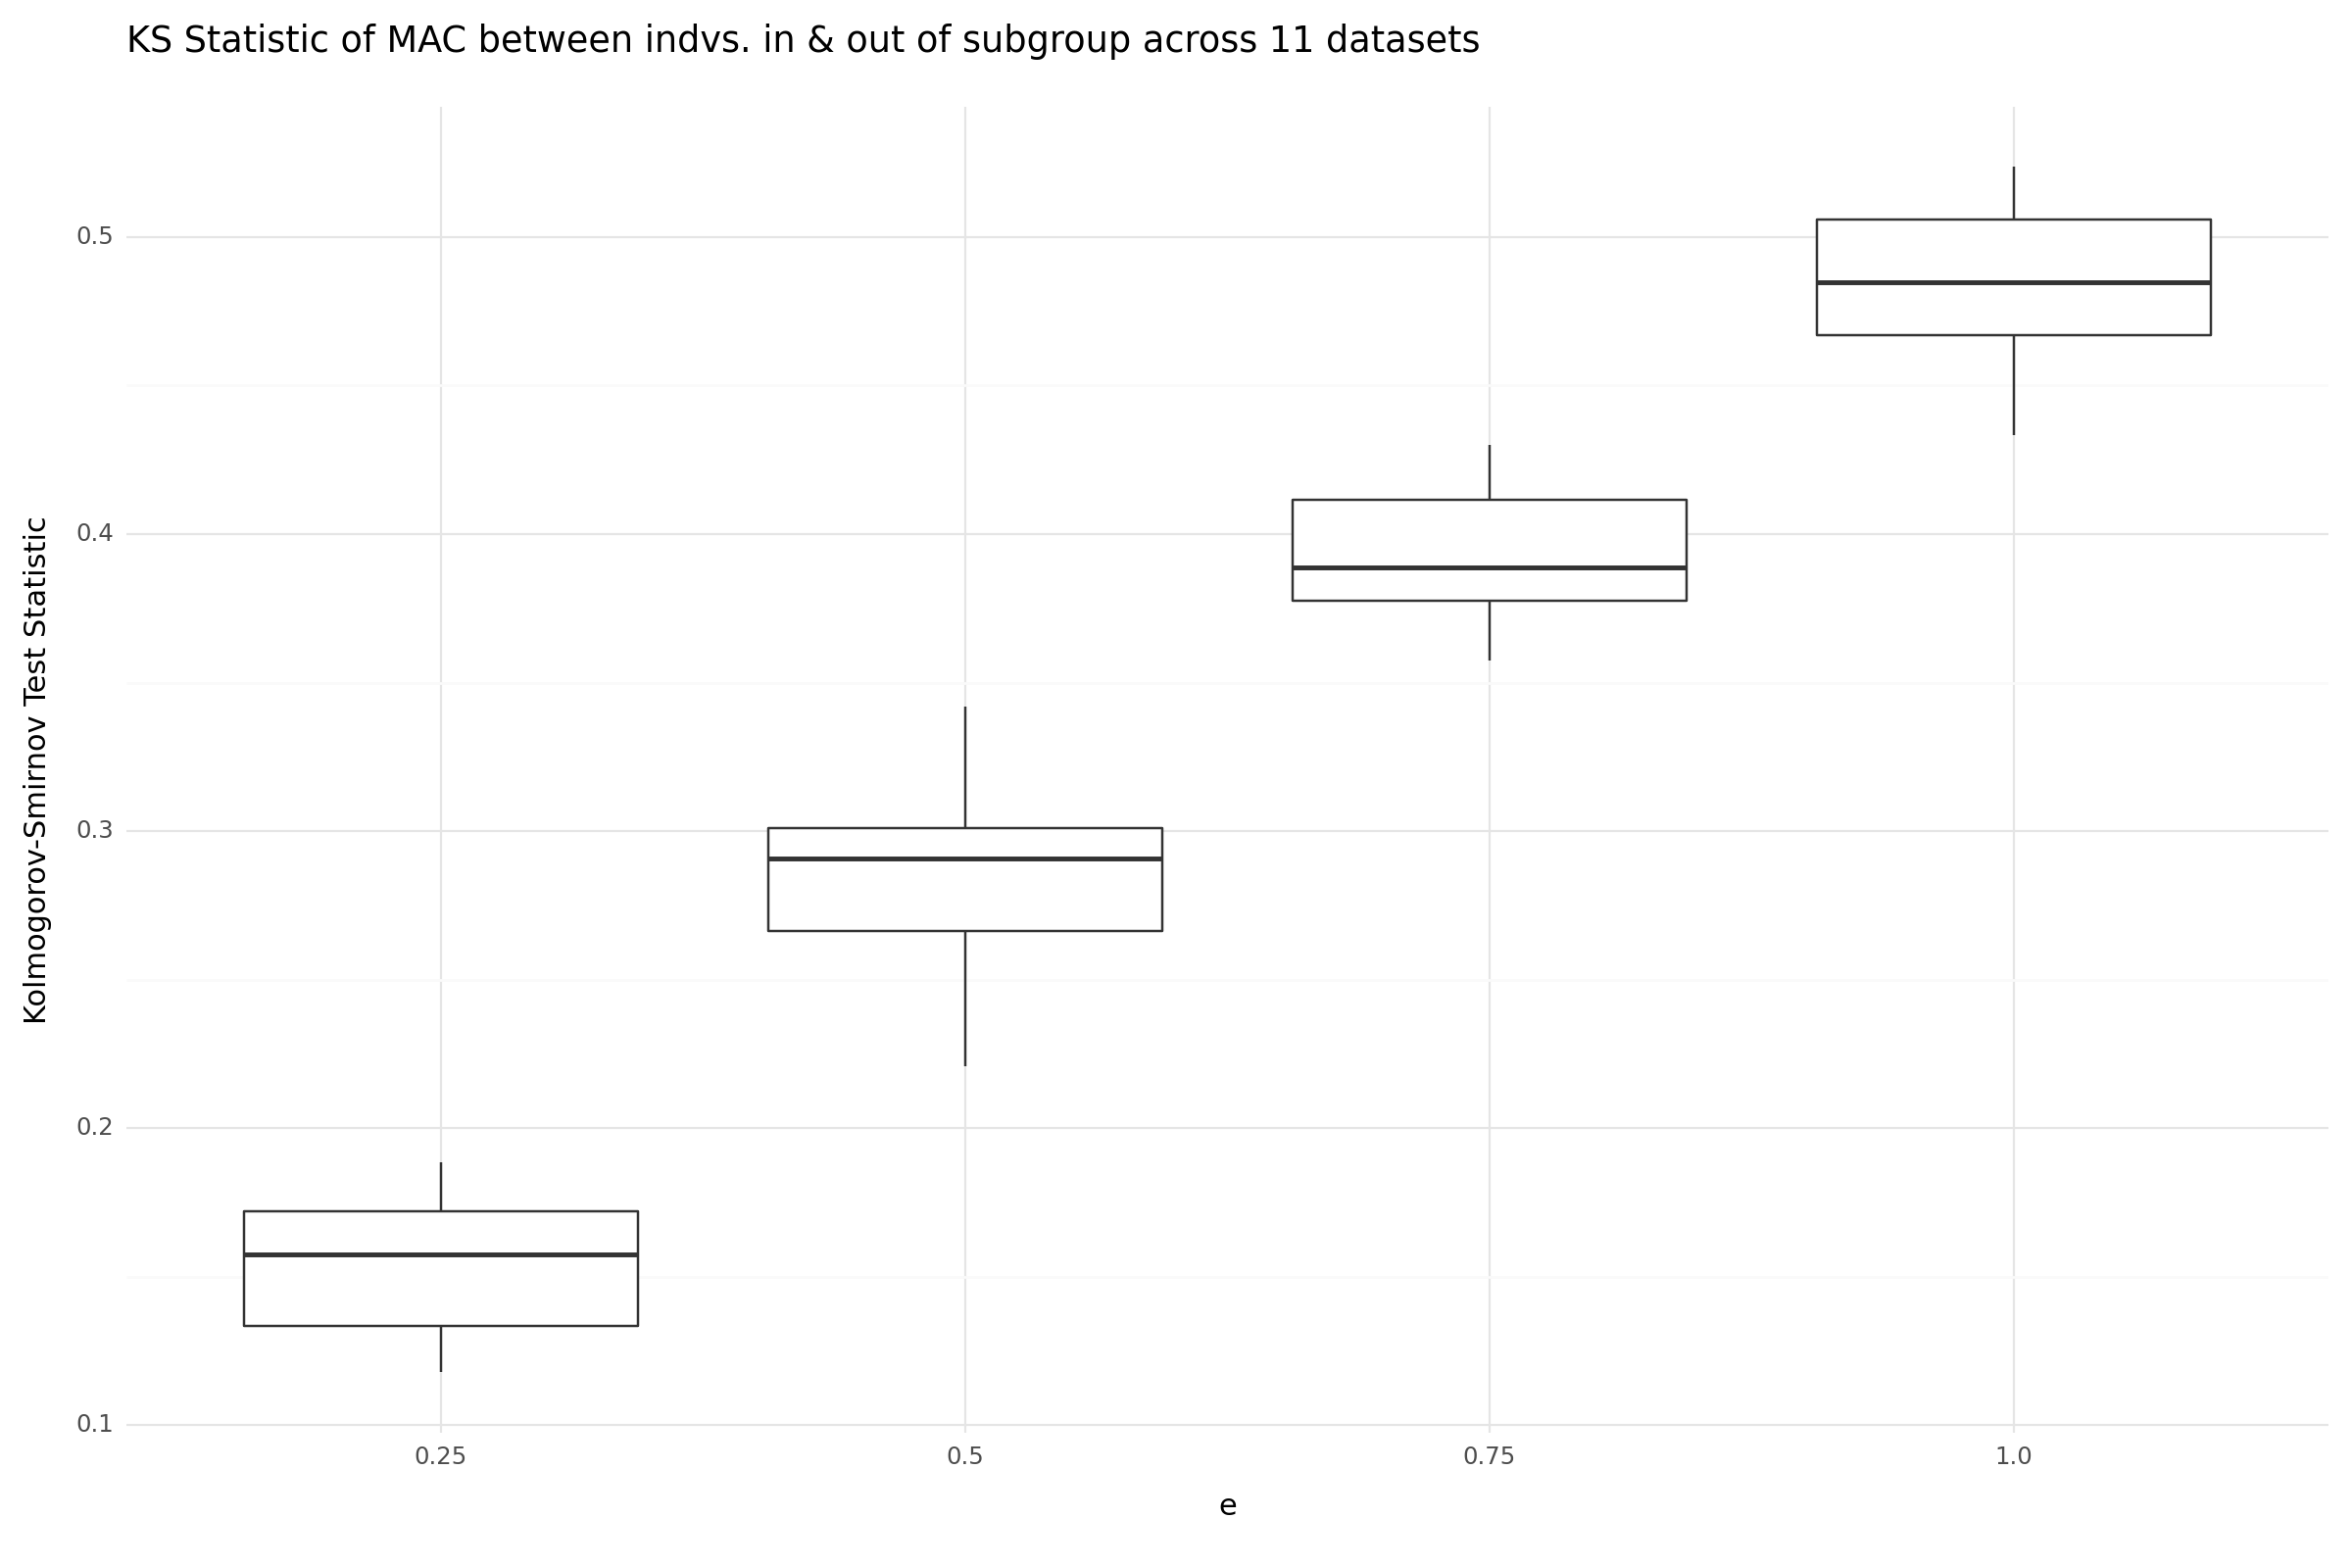

In [258]:
df
dodge = position_dodge(width=0.35)
p = (
ggplot(df, aes(x="factor(e)", y="ks"))
+ geom_boxplot()
+ labs(x="e", y="Kolmogorov-Smirnov Test Statistic", title='KS Statistic of MAC between indvs. in & out of subgroup across 11 datasets')
+ theme_minimal()
+ theme(figure_size=(12,8))
)
print(p)


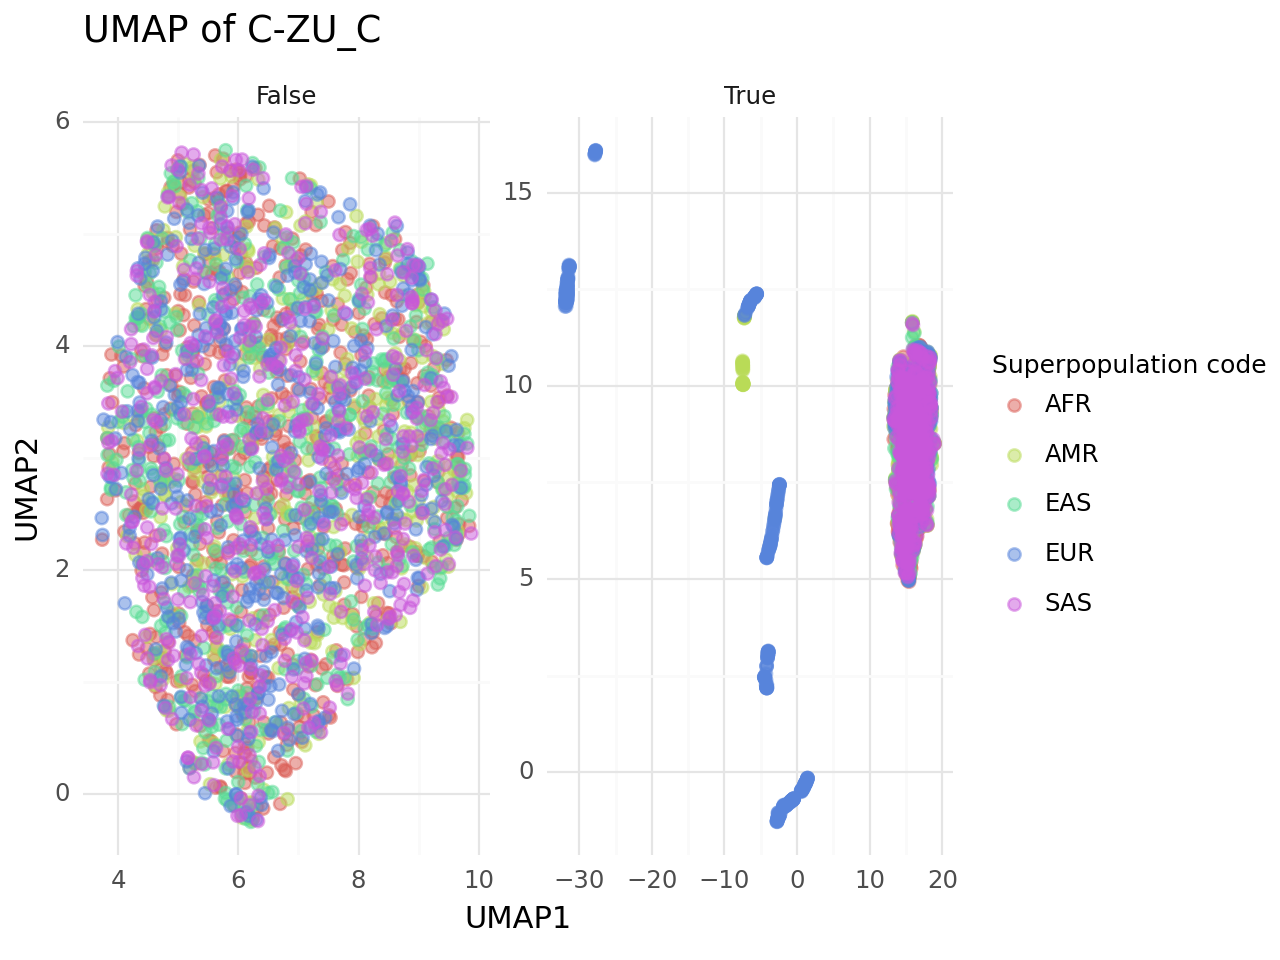

<Figure Size: (640 x 480)>

In [32]:
# umap of G-ZUG
# umap of G with superpopulation label & also genetic subgroup label
ps_list = [True,False]
e = 1
dataset=0
g=10
num_markers = 100
rank = 3
import algorithms.SCoNE as SCoNE
plot_dfs = []
for ps in ps_list:
    admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
    fam_df = pd.read_csv(f'{sim_output_dir}/G.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    admixture['IID'] = fam_df['IID'].values
    igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
    igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

    Z_df = admixture.merge(igsr_samples[['IID']], on='IID',how='inner') # not including covar Sex
    Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()

    output_file_suffix = sim_functions.get_output_file_suffix(ps,e,dataset,g)
    with open(f"{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl", "rb") as f:
                simulation_metadata = pickle.load(f)
    phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
    iid_order = simulation_metadata['iid_order']
    fam_df = pd.read_csv(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    iid_index = fam_df[fam_df['IID'].isin(simulation_metadata['iid_order'])].index
    igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
    G = np.loadtxt(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.raw',  usecols=range(6, num_markers+6), dtype=np.int8, skiprows=1)
    C = np.load(f'{sim_output_dir}/C_{output_file_suffix}.npy')
    idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
    best = (
        all_runs.loc[idx, all_runs.columns]
        .sort_values(["experiment_id","run_name", "ps", "e", "g"])
        .reset_index(drop=True)
    )
    exp_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['experiment_id'].values[0]
    run_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['run_id'].values[0]
    with open(f'{output_dir}/logs/{exp_id}/{run_id}/artifacts/state_info/final_state.pkl','rb') as f:
            final_state = pickle.load(f)
    reducer = umap.UMAP(metric='cosine')
    embedding = reducer.fit_transform(C-Z[iid_index,:]@final_state['U_C'].T)


    plot_df = (pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"], index=iid_order).
                    rename_axis("IID").reset_index().merge(igsr_samples[['IID','Superpopulation code']], on='IID',how='inner'))
    plot_df['ps'] = ps
    plot_dfs.append(plot_df)
plot_dfs = pd.concat(plot_dfs)
p = (
    ggplot(plot_dfs, aes("UMAP1", "UMAP2", color='Superpopulation code'))
    + geom_point(alpha=0.5, size=2)
    + labs(title='UMAP of C-ZU_C', color='Superpopulation code')
    + facet_wrap(f'~ ps',scales='free')
    + theme_minimal()
    + theme(legend_title=element_text(size=9))
)
p

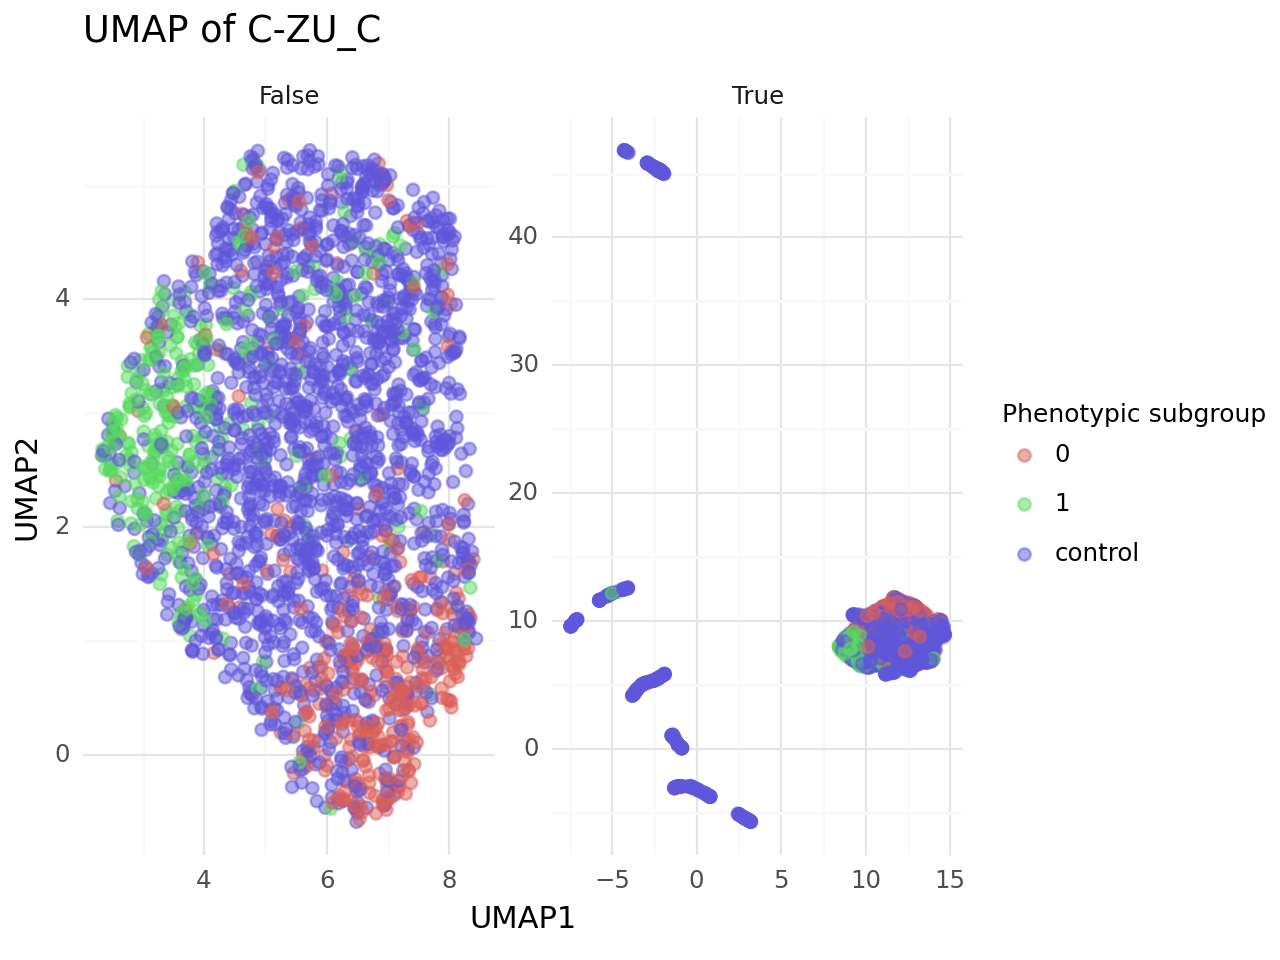

<Figure Size: (640 x 480)>

In [40]:
ps_list = [True,False]
e = 1
dataset=0
g=10
num_markers = 100
plot_dfs = []
for ps in ps_list:
    output_file_suffix = sim_functions.get_output_file_suffix(ps,e,dataset,g)
    with open(f"{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl", "rb") as f:
                simulation_metadata = pickle.load(f)
    phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
    iid_order = simulation_metadata['iid_order']
    fam_df = pd.read_csv(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    iid_index = fam_df[fam_df['IID'].isin(simulation_metadata['iid_order'])].index
    G = np.loadtxt(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.raw',  usecols=range(6, num_markers+6), dtype=np.int8, skiprows=1)
    C = np.load(f'{sim_output_dir}/C_{output_file_suffix}.npy')
    idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
    best = (
        all_runs.loc[idx, all_runs.columns]
        .sort_values(["experiment_id","run_name", "ps", "e", "g"])
        .reset_index(drop=True)
    )
    exp_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['experiment_id'].values[0]
    run_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['run_id'].values[0]
    with open(f'{output_dir}/logs/{exp_id}/{run_id}/artifacts/state_info/final_state.pkl','rb') as f:
        final_state = pickle.load(f)
    reducer = umap.UMAP(metric='cosine')
    embedding = reducer.fit_transform(C-Z[iid_index,:]@final_state['U_C'].T)

    labels = (phenotypic_subgroups.loc[lambda d: d['subgroup'] & d['phenotypic_subgroup'].isin([0, 1])].groupby('IID')['phenotypic_subgroup']
            .apply(lambda s: ','.join(map(str, sorted(s)))))
    # fill others as 'control'
    out = pd.DataFrame(index=phenotypic_subgroups['IID'].unique()).sort_index()
    out['phenotypic_subgroup'] = 'control'
    out.loc[labels.index, 'phenotypic_subgroup'] = labels
    out = out.reset_index().rename(columns={"index": "IID"})

    plot_df = (pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"], index=iid_order).
                    rename_axis("IID").reset_index().merge(out[['IID','phenotypic_subgroup']], on='IID',how='inner'))
    plot_df['ps'] = ps
    plot_dfs.append(plot_df)
plot_dfs = pd.concat(plot_dfs)
p = (
    ggplot(plot_dfs, aes("UMAP1", "UMAP2", color='phenotypic_subgroup'))
    + geom_point(alpha=0.5, size=2)
    + labs(title='UMAP of C-ZU_C', color='Phenotypic subgroup')
    + facet_wrap(f'~ps',ncol=2,scales='free')
    + theme_minimal()
    + theme(legend_title=element_text(size=9))
)
p

In [4]:
# test code setup

# DEFINE PATHS
intermediate_plink_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
graph_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
# DEFINE PATHS


# read in 
G = np.loadtxt(f'{sim_output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)
# assert that bim_df and G order is the same
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
G_columns = [i.split('_')[0] for i in pd.read_csv(f'{bfile_path}.raw',sep='\s+',usecols=range(6, 10000+6),nrows=1).columns]
assert all(bim_df['SNP'].values==G_columns)

In [6]:
from collections import defaultdict


# ML Flow 

In [197]:
import mlflow
from mlflow.tracking import MlflowClient

In [198]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs_tuning")
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
all_runs = all_runs[all_runs['status']=='FINISHED'].copy()
all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]
idx = all_runs.groupby(["run_name", "g_ps", "c_ps", "e"])["G_plus_C_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .reset_index(drop=True)
)

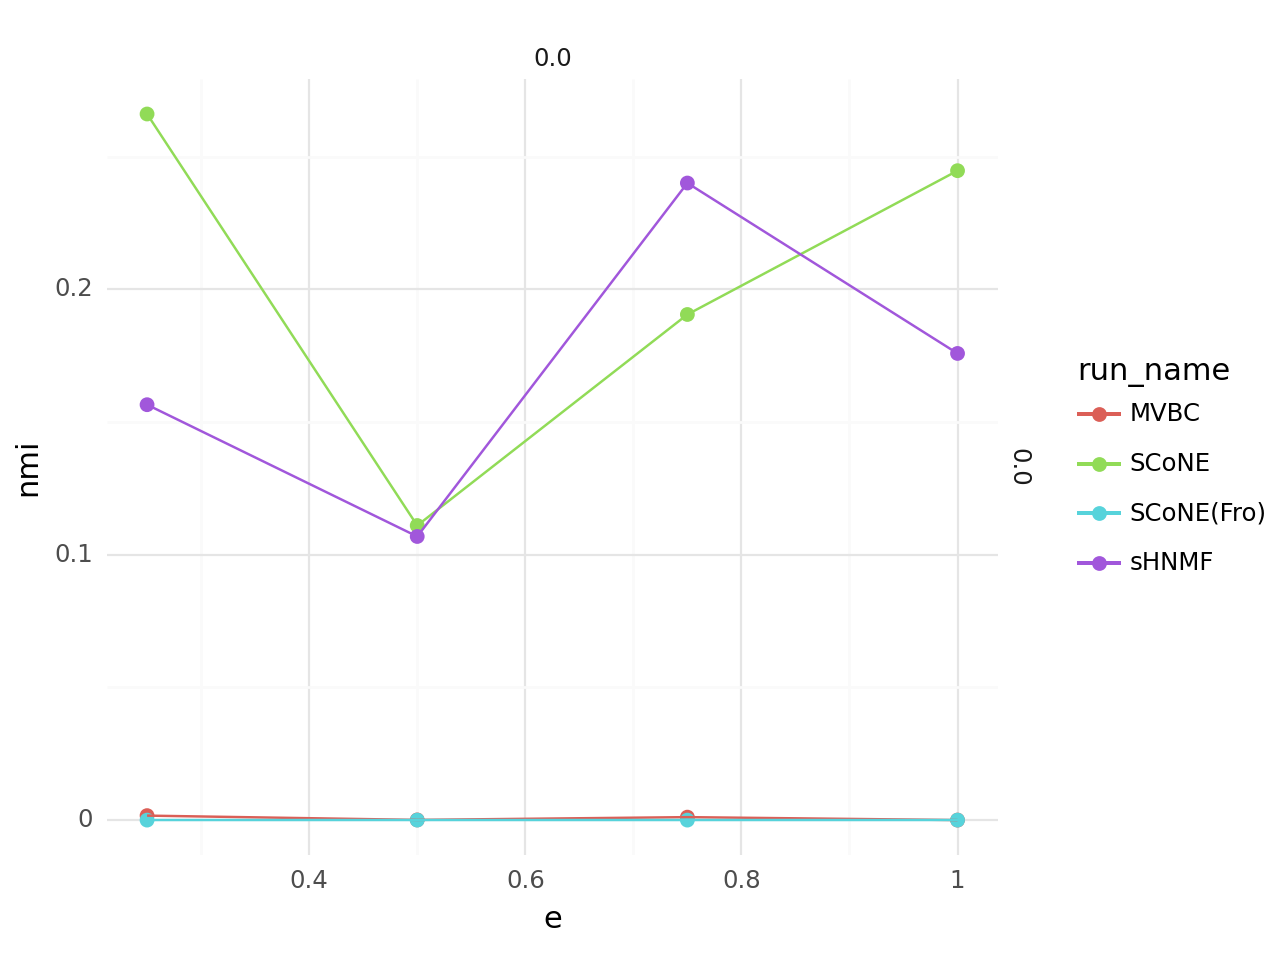

In [199]:
p = (
ggplot(best, aes(x="e", y="nmi", color="run_name", group="run_name"))
+ geom_point(size=2)
+ geom_line()
+ facet_grid('g_ps ~ c_ps')
+ theme_minimal()
+ theme()
)
print(p)

We do see norm decrease generally with increase lambda value for W - this is not the case for H_G

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 3 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 24 rows containing missing values.


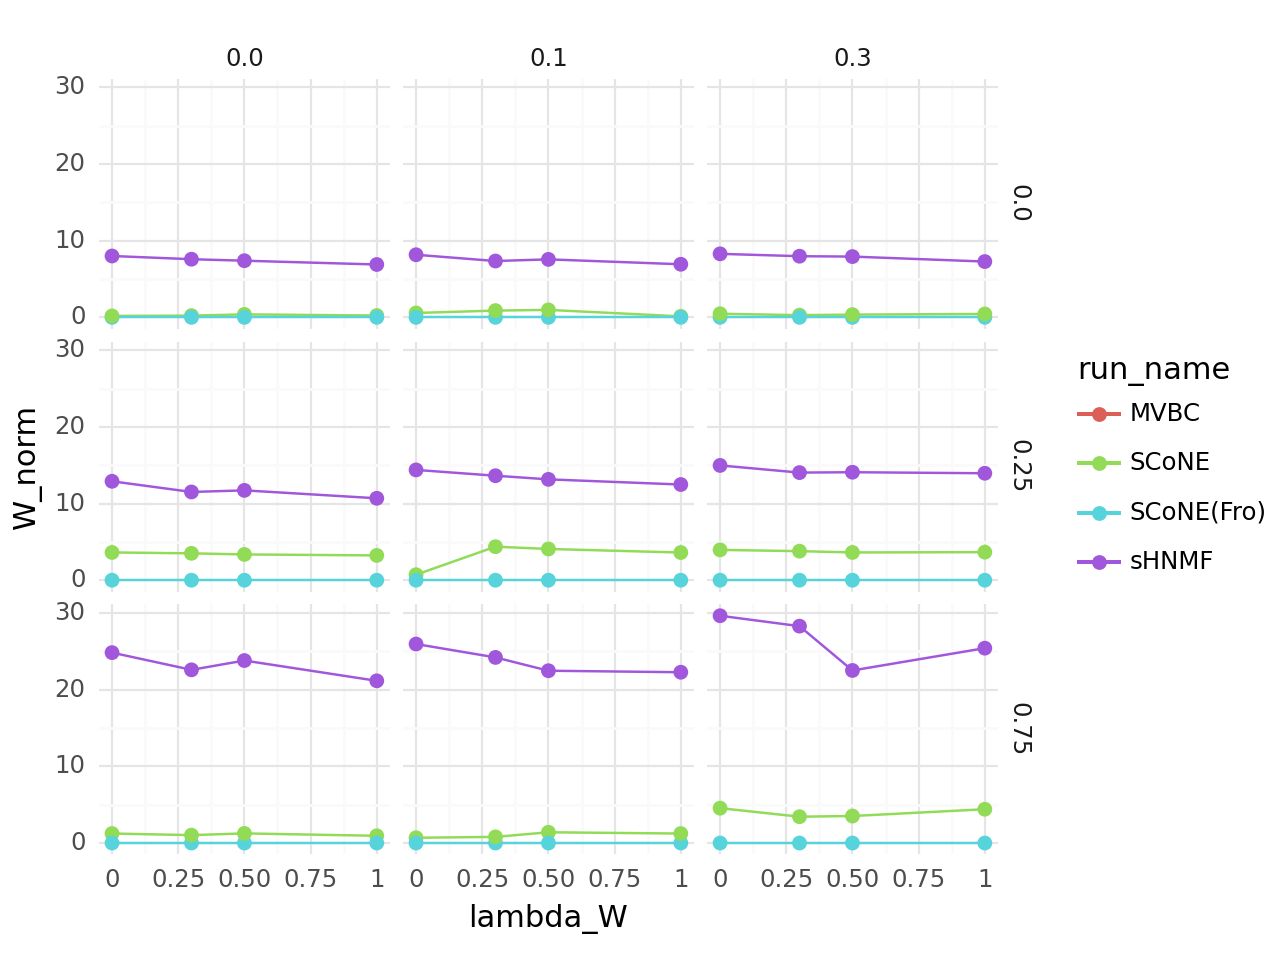

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 4 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 36 rows containing missing values.


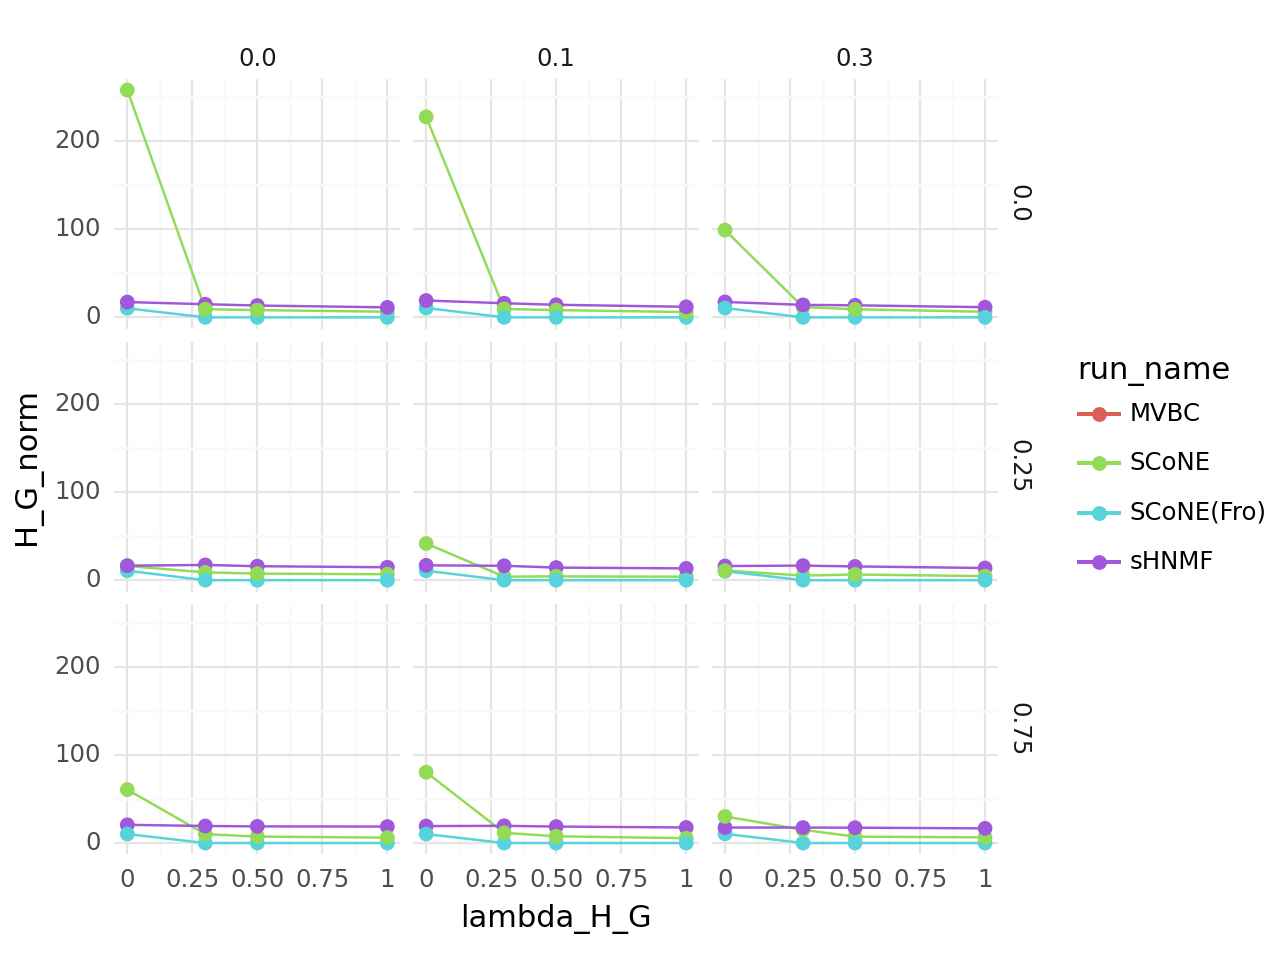

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 4 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 36 rows containing missing values.


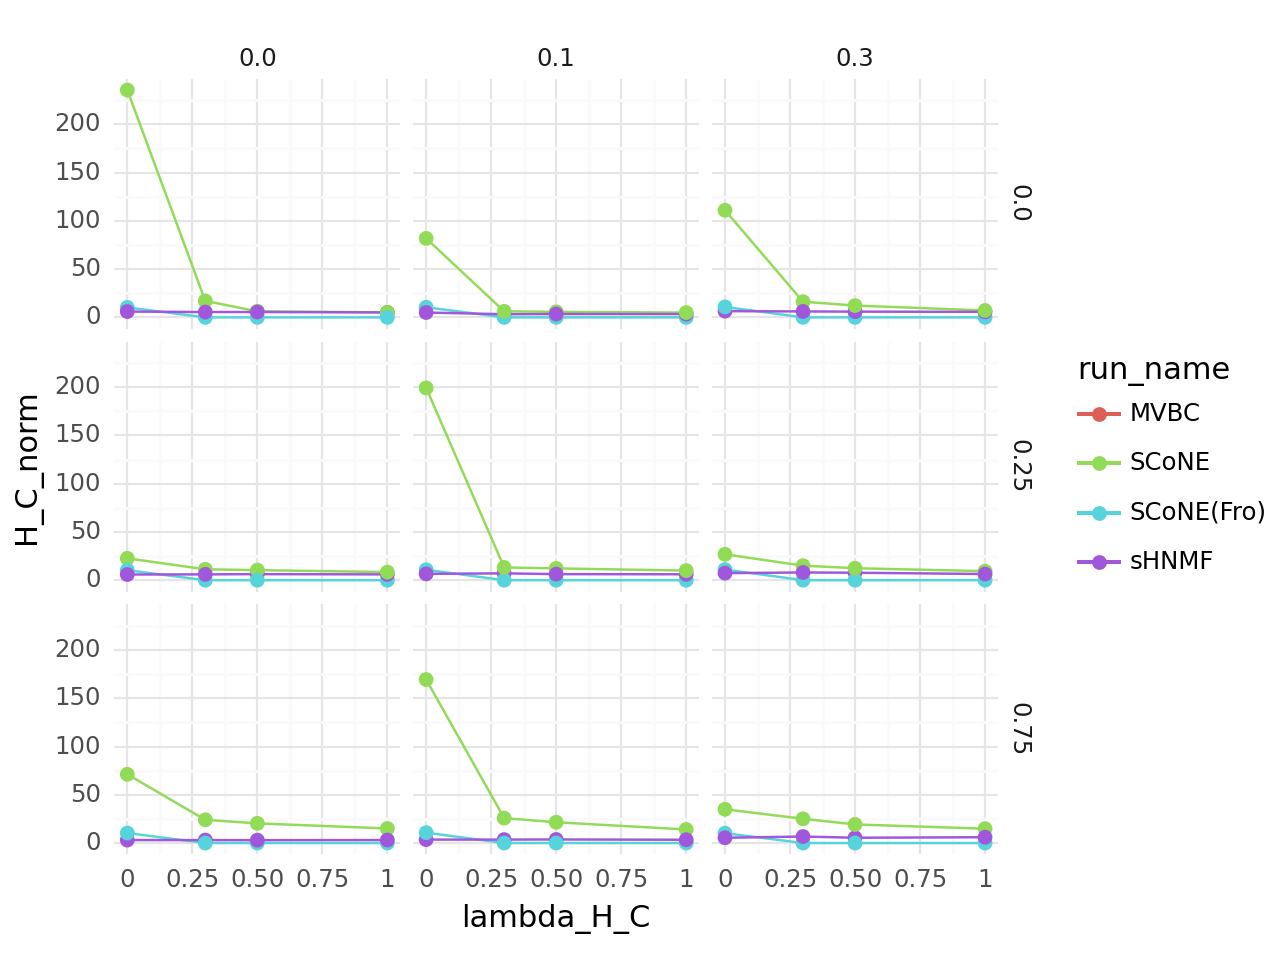

In [6]:
corresponding_norm = {'lambda_W':'W_norm','lambda_H_G':'H_G_norm','lambda_H_C':'H_C_norm'}
for param in ['lambda_W','lambda_H_G','lambda_H_C']: # maybe instead look when others are 0
    null_params = [i for i in ['lambda_W','lambda_H_G','lambda_H_C'] if i!=param]
    summary = all_runs[(all_runs[null_params[0]]==0)&(all_runs[null_params[1]]==0)]

    dodge = position_dodge(width=0.35)
    p = (
    ggplot(summary[summary['e']==1], aes(x=param, y=corresponding_norm[param], color="run_name", group='run_name'))
    + geom_line()
    + geom_point(size=2)
    #+ geom_errorbar(aes(ymin="ymin",ymax="ymax"))
    + theme_minimal()
    + theme()
    + facet_grid('g_ps ~ c_ps')
    )
    print(p)

In [15]:
best[["experiment_id","run_id",'run_name','g_ps','c_ps','lambda_W','lambda_H_G','lambda_H_C','nmi','norm_cond_entropy','purity', 'W_norm','H_G_norm','H_C_norm']]

,experiment_id,run_id,run_name,g_ps,c_ps,lambda_W,lambda_H_G,lambda_H_C,nmi,norm_cond_entropy,purity,W_norm,H_G_norm,H_C_norm
0,277442729551762037,c689ff2004004d93ae2830cbe9f3a471,MVBC,0.00,0.0,NaN,NaN,NaN,0.018981,0.985960,0.528455,NaN,NaN,NaN
1,332945771569139612,b56847f655924daaa369ee60c671a894,MVBC,0.00,0.0,NaN,NaN,NaN,0.000968,0.998997,0.509881,NaN,NaN,NaN
2,613564139186280622,68e80397f0a44ba884fb2559fd54e3ca,MVBC,0.00,0.0,NaN,NaN,NaN,0.007778,0.995951,0.502024,NaN,NaN,NaN
3,510650892567878570,077e8aa277b745d88a4e59cc61fbcd57,MVBC,0.00,0.0,NaN,NaN,NaN,0.015953,0.989017,0.527778,NaN,NaN,NaN
4,409145975942914107,14605e284b1d4021aeb8b72ed29e2b22,MVBC,0.25,0.1,NaN,NaN,NaN,0.000101,0.999685,0.508003,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,869439251583240095,d65df17e3412418c9758714999bac40e,sHNMF,0.75,0.1,1.0,0.0,0.3,0.000473,0.998053,0.521703,23.332901,22.191344,5.212228
76,640299149434343718,c024831ad1524c86b2726f8aa5ba3a1e,sHNMF,0.75,0.3,0.0,0.5,0.5,0.004767,0.980392,0.568328,28.237551,18.438566,4.956288
77,540750915427269317,fef9176b5c5b494b8a59a76bec61467c,sHNMF,0.75,0.3,1.0,0.3,0.3,0.024649,0.968345,0.600946,27.786313,18.571414,8.022436
78,579533630474954359,099a4ac2568f4797a93b48a91352ac96,sHNMF,0.75,0.3,1.0,0.0,0.0,0.010386,0.974663,0.564822,22.904771,21.450060,7.270538


# Reading in test runs

In [262]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs")
client = MlflowClient()
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    print(exp)
    df = mlflow.search_runs([exp.experiment_id])
    df["experiment_id"] = exp.experiment_id
    df["experiment_name"] = exp.name
    all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
all_runs = all_runs[all_runs['status']=='FINISHED'].copy()
all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]

<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/571975874521543620', creation_time=1760475687016, experiment_id='571975874521543620', last_update_time=1760475687016, lifecycle_stage='active', name='3', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/715927831047635003', creation_time=1760475687012, experiment_id='715927831047635003', last_update_time=1760475687012, lifecycle_stage='active', name='2', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/452415386193827196', creation_time=1760475687009, experiment_id='452415386193827196', last_update_time=1760475687009, lifecycle_stage='active', name='1', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/206337556816131081', creation_time=1760475687006, experiment_id='20

In [263]:
from evaluation import cluster_evaluation
from scipy.optimize import linear_sum_assignment

results_list = []
# look at correlation btwn columns of af and UG
af_variance_df = pd.read_csv(f'{af_df_filepath}.P',header=None,sep='\s+')
# get marker id
df_map = pd.read_csv(map_filepath,sep='\s+',header=None,names=["chrom", "SNP", "cm", "bp"])
af_variance_df['SNP'] = df_map['SNP'].values
# make sure af variance df and bim df have same snps (incase of subsetting)
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2'])
af_variance_df = af_variance_df.merge(bim_df[['SNP']], on='SNP', how='inner')
assert all(af_variance_df['SNP'].values == bim_df['SNP'].values)
for i, row in all_runs.iterrows():
    # re-calc some params
    with open(f'{output_dir}/logs/{row["experiment_id"]}/{row["run_id"]}/artifacts/state_info/final_state.pkl','rb') as f:
        final_state = pickle.load(f)
    with open(f'{sim_output_dir}/simulation_metadata_{sim_functions.get_output_file_suffix(row["ps"],row["e"],row["dataset"],int(row["g"]))}.pkl','rb') as f:
        simulation_metadata = pickle.load(f)
    W_true = (simulation_metadata['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
        .reindex(simulation_metadata['iid_order']).iloc[:,:2].to_numpy().astype(int))
    mask = (W_true.sum(axis=1) == 1)
    ground_truth = {"W":W_true[mask]}
    factor_matrices = {"W":final_state["W"][mask]}
    assert ground_truth["W"].shape[0] == factor_matrices["W"].shape[0]
    results = cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)


    # # look at metrics by superpopulation
    # igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath,bfile_path=bfile_path)
    # igsr_samples = igsr_samples[igsr_samples['IID'].isin(simulation_metadata['phenotypic_subgroups']['IID'])].copy()
    # phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
    # phenotypic_subgroups = phenotypic_subgroups.merge(igsr_samples,on='IID')
    # for pop_code in phenotypic_subgroups['Superpopulation code'].unique():
    #     mask2 = (igsr_samples['Superpopulation code'].values == pop_code)
    #     other_col = ((W_true.sum(axis=1) == 0).astype(int)).reshape(-1, 1)
    #     ground_truth = {"W":np.hstack([W_true, other_col])[mask2]}
    #     factor_matrices = {"W":final_state["W"][mask2]}
    #     pop_results = cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)
    #     results[f'purity_{pop_code}'] = pop_results['purity']
    #     results[f'entropy_{pop_code}'] = pop_results['norm_cond_entropy']
    #     results[f'nmi_{pop_code}'] = pop_results['nmi']
    # look at correctly identifying markers - calculte max overlap with markers0 and markers1
    marker_matrix = np.zeros((2,3))
    for i_true in range(2):
        for j_pred in range(3):
            true_col = bim_df['SNP'].isin(simulation_metadata['markers_assoc'][i_true]).astype(int)
            pred_col = final_state["H_G"][:,j_pred]
            cos = np.dot(true_col, pred_col) / (np.linalg.norm(true_col) * np.linalg.norm(pred_col))
            marker_matrix[i_true,j_pred] = cos
    i_col, j_col = linear_sum_assignment(-marker_matrix)
    results = {}
    for i,j in list(zip(i_col, j_col)):
        results[f'marker_overlap_{i}'] = marker_matrix[i,j]


    # for cone methods, there should be some non-zero correlation between U_G and superpopulation allele frequency
    A = final_state["U_G"]
    B = af_variance_df[range(5)].to_numpy()
    A0 = A - A.mean(axis=0, keepdims=True)
    B0 = B - B.mean(axis=0, keepdims=True)
    A_hat = A0 / np.linalg.norm(A, axis=0, keepdims=True)
    B_hat = B0 / np.linalg.norm(B, axis=0, keepdims=True)
    cos_sim =  A_hat.T @ B_hat   # shape (n, k)
    results['ug_af_cossim_mean'] = cos_sim.mean()



    results_list.append(results)




all_runs[pd.DataFrame(results_list, index=all_runs.index).columns] = pd.DataFrame(results_list, index=all_runs.index)


KeyError: 'ps'

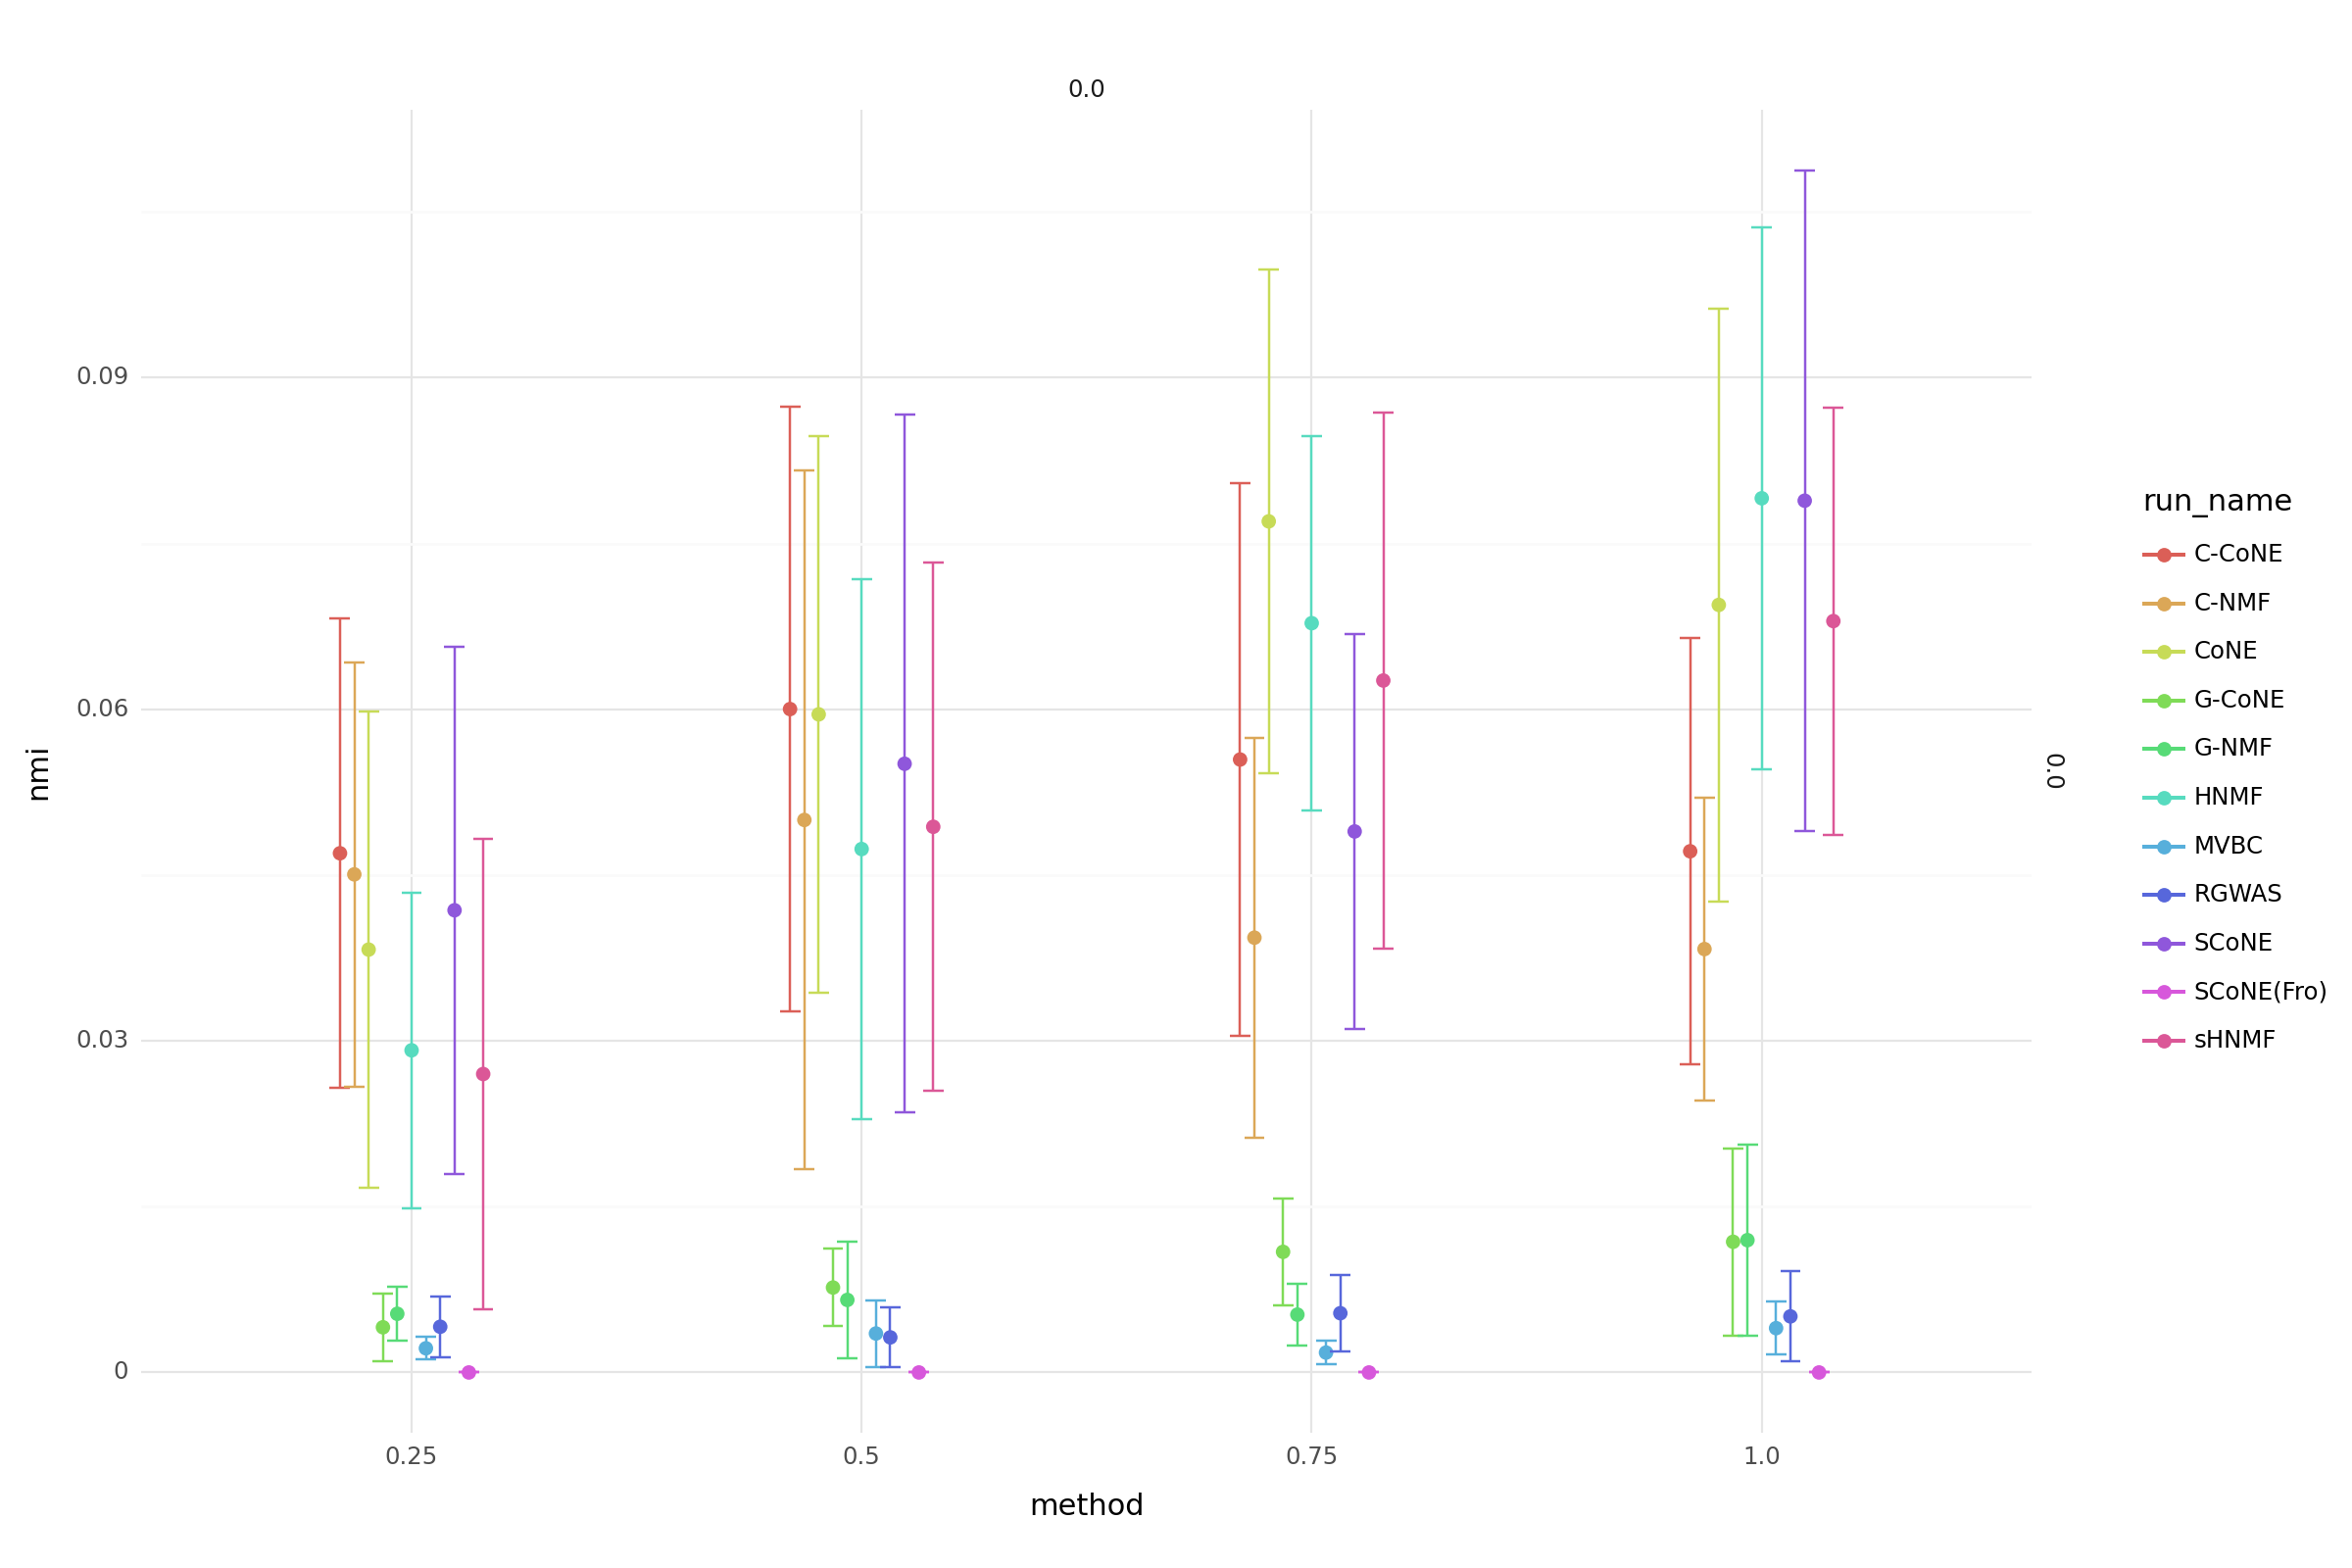

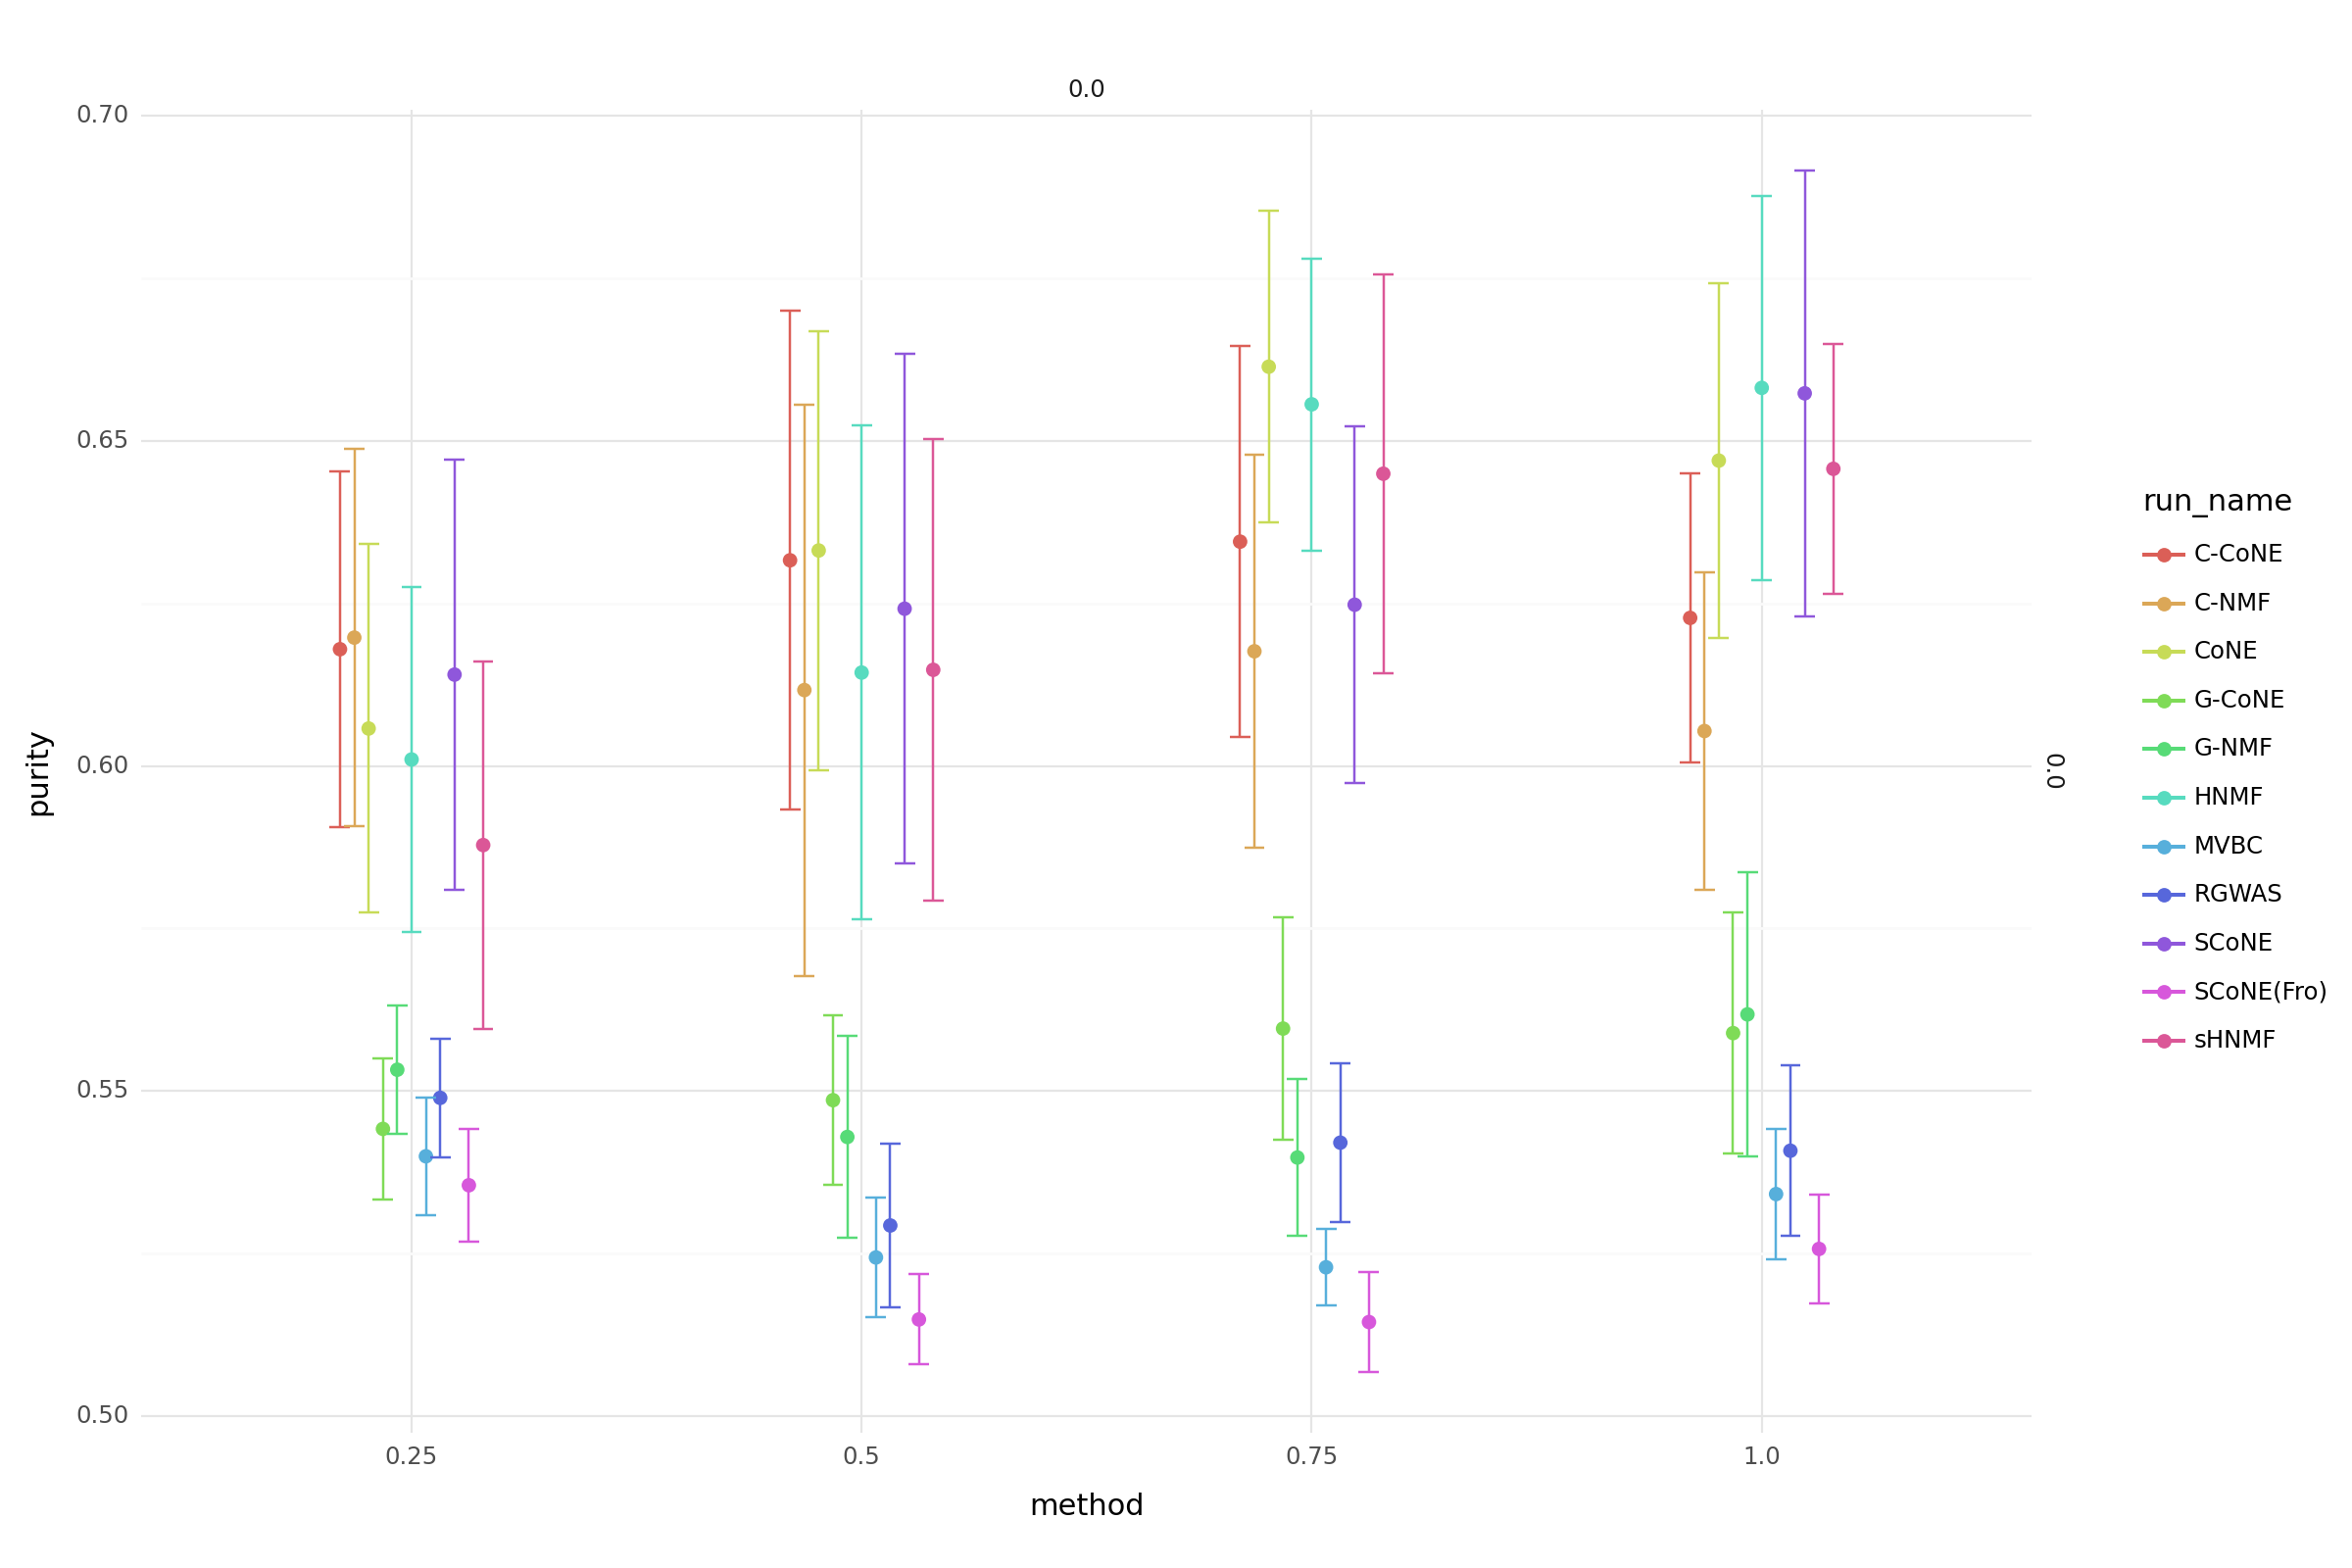

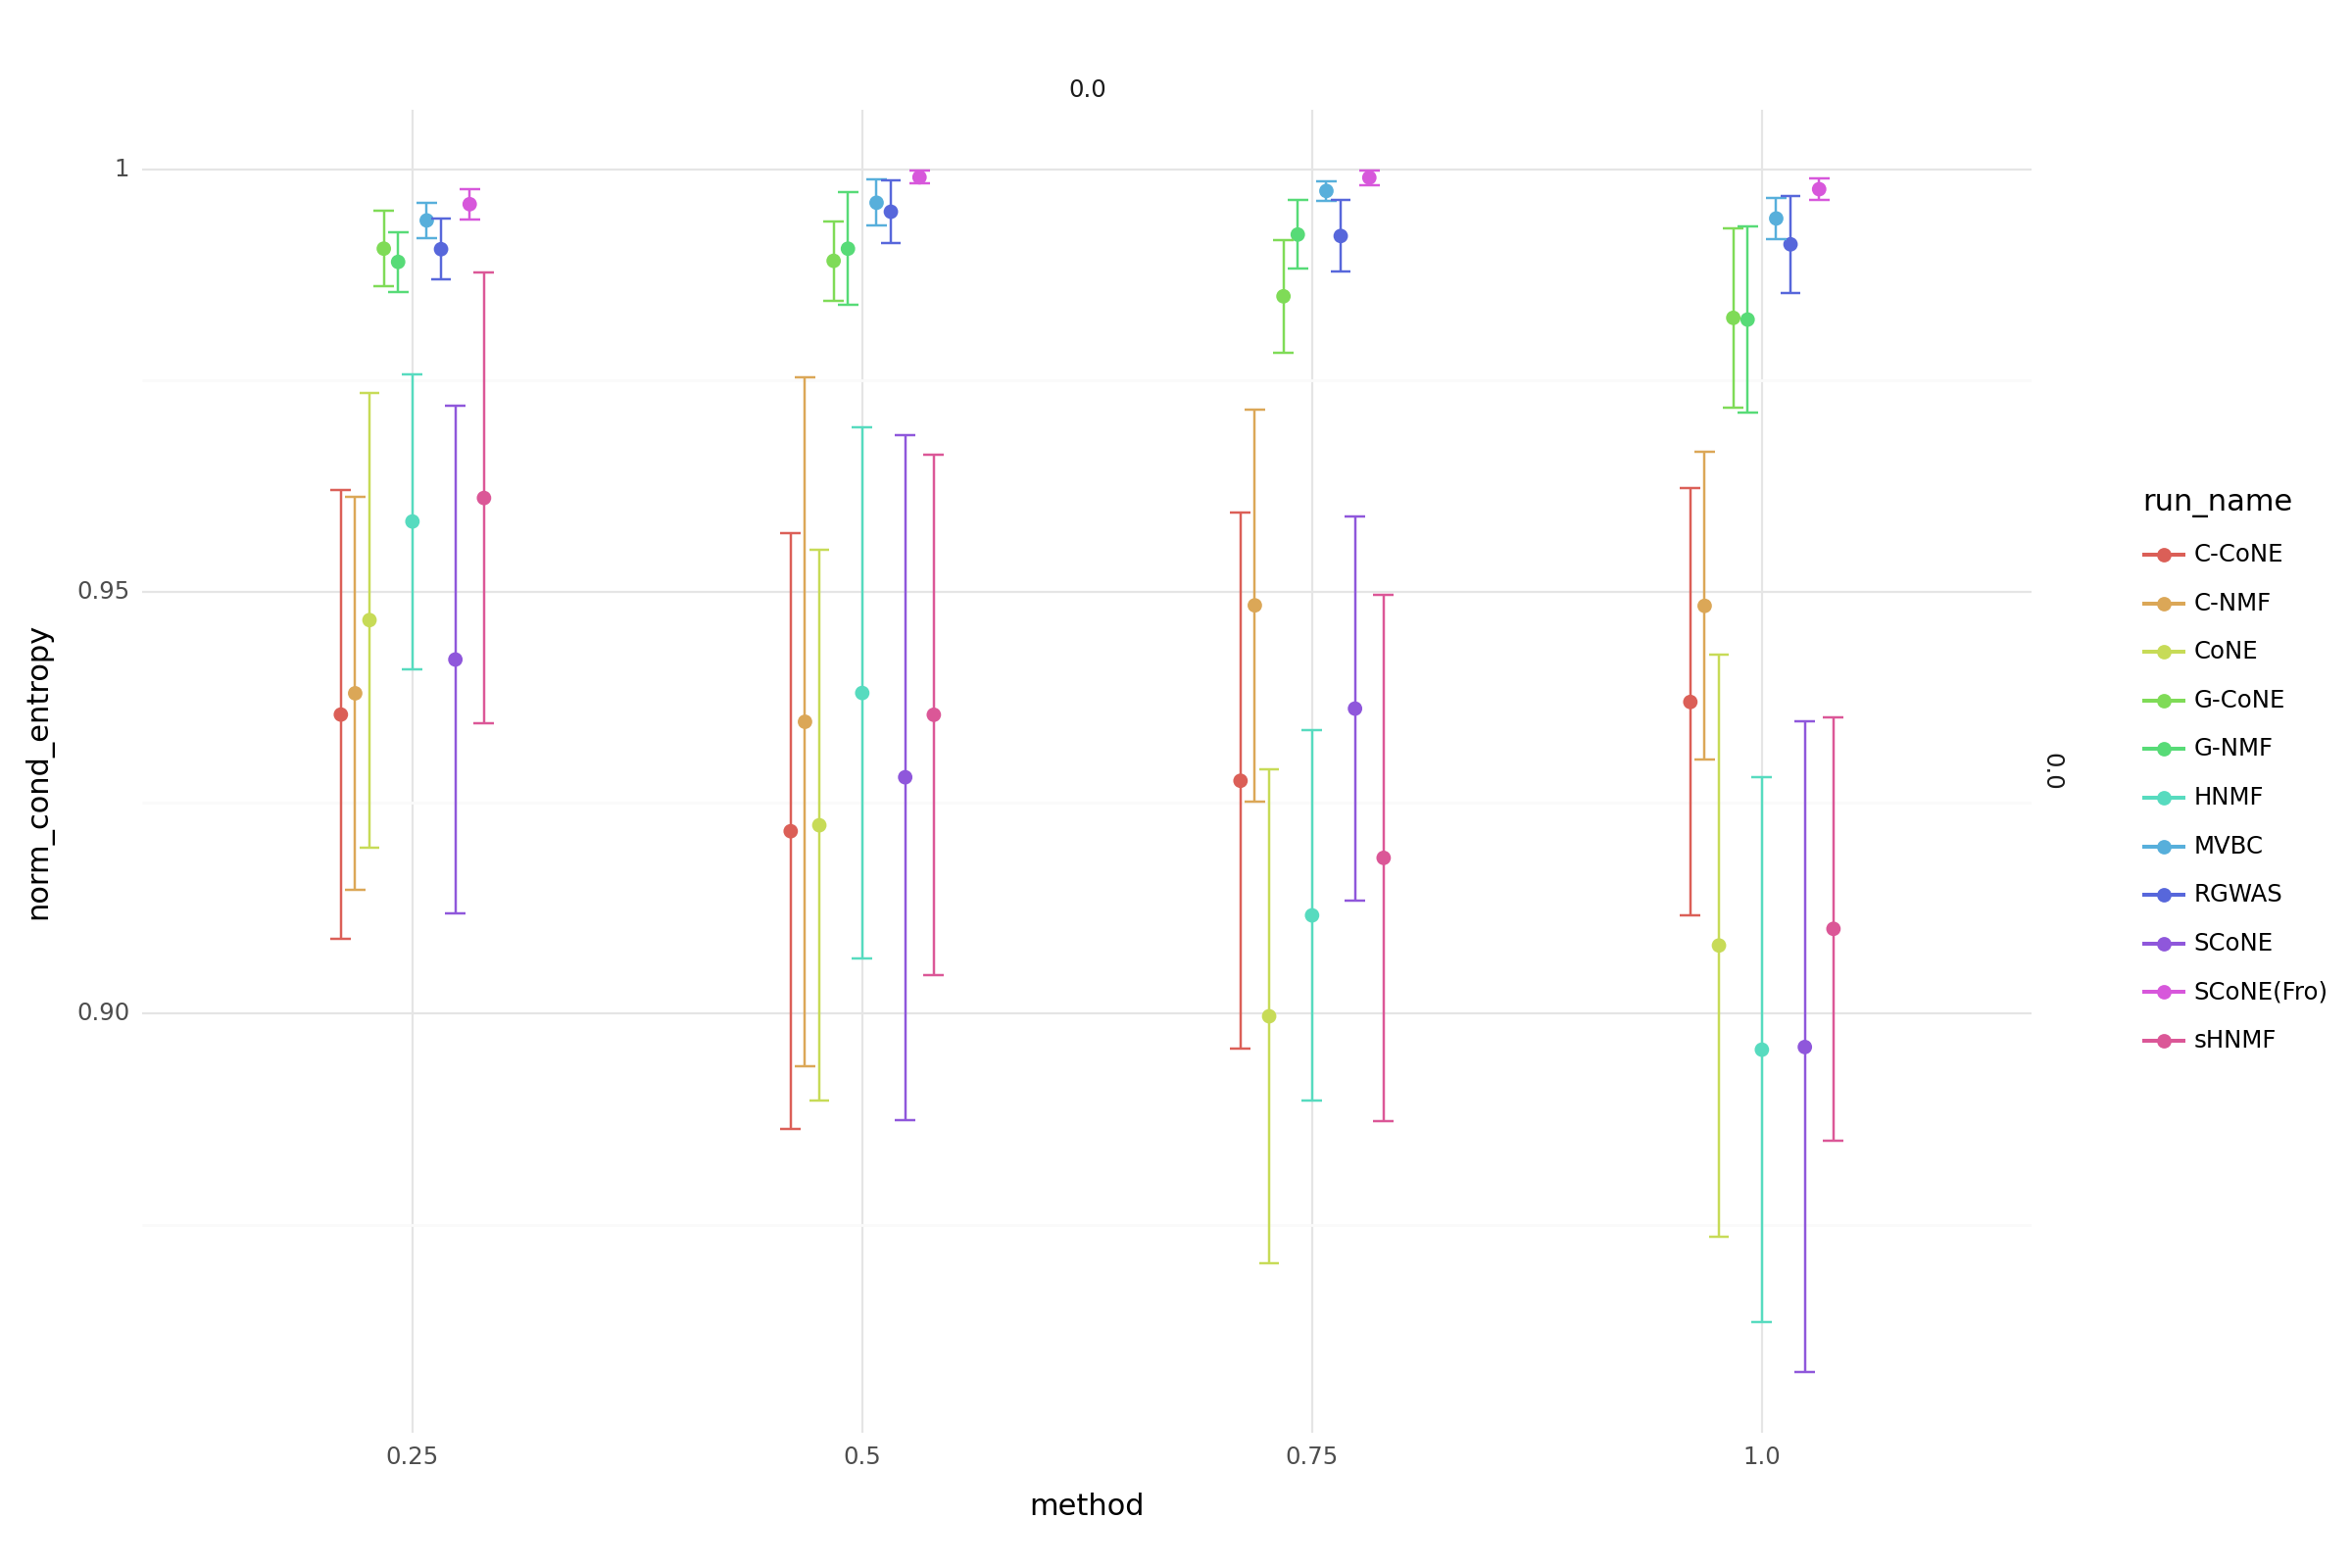

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 8 rows containing missing values.


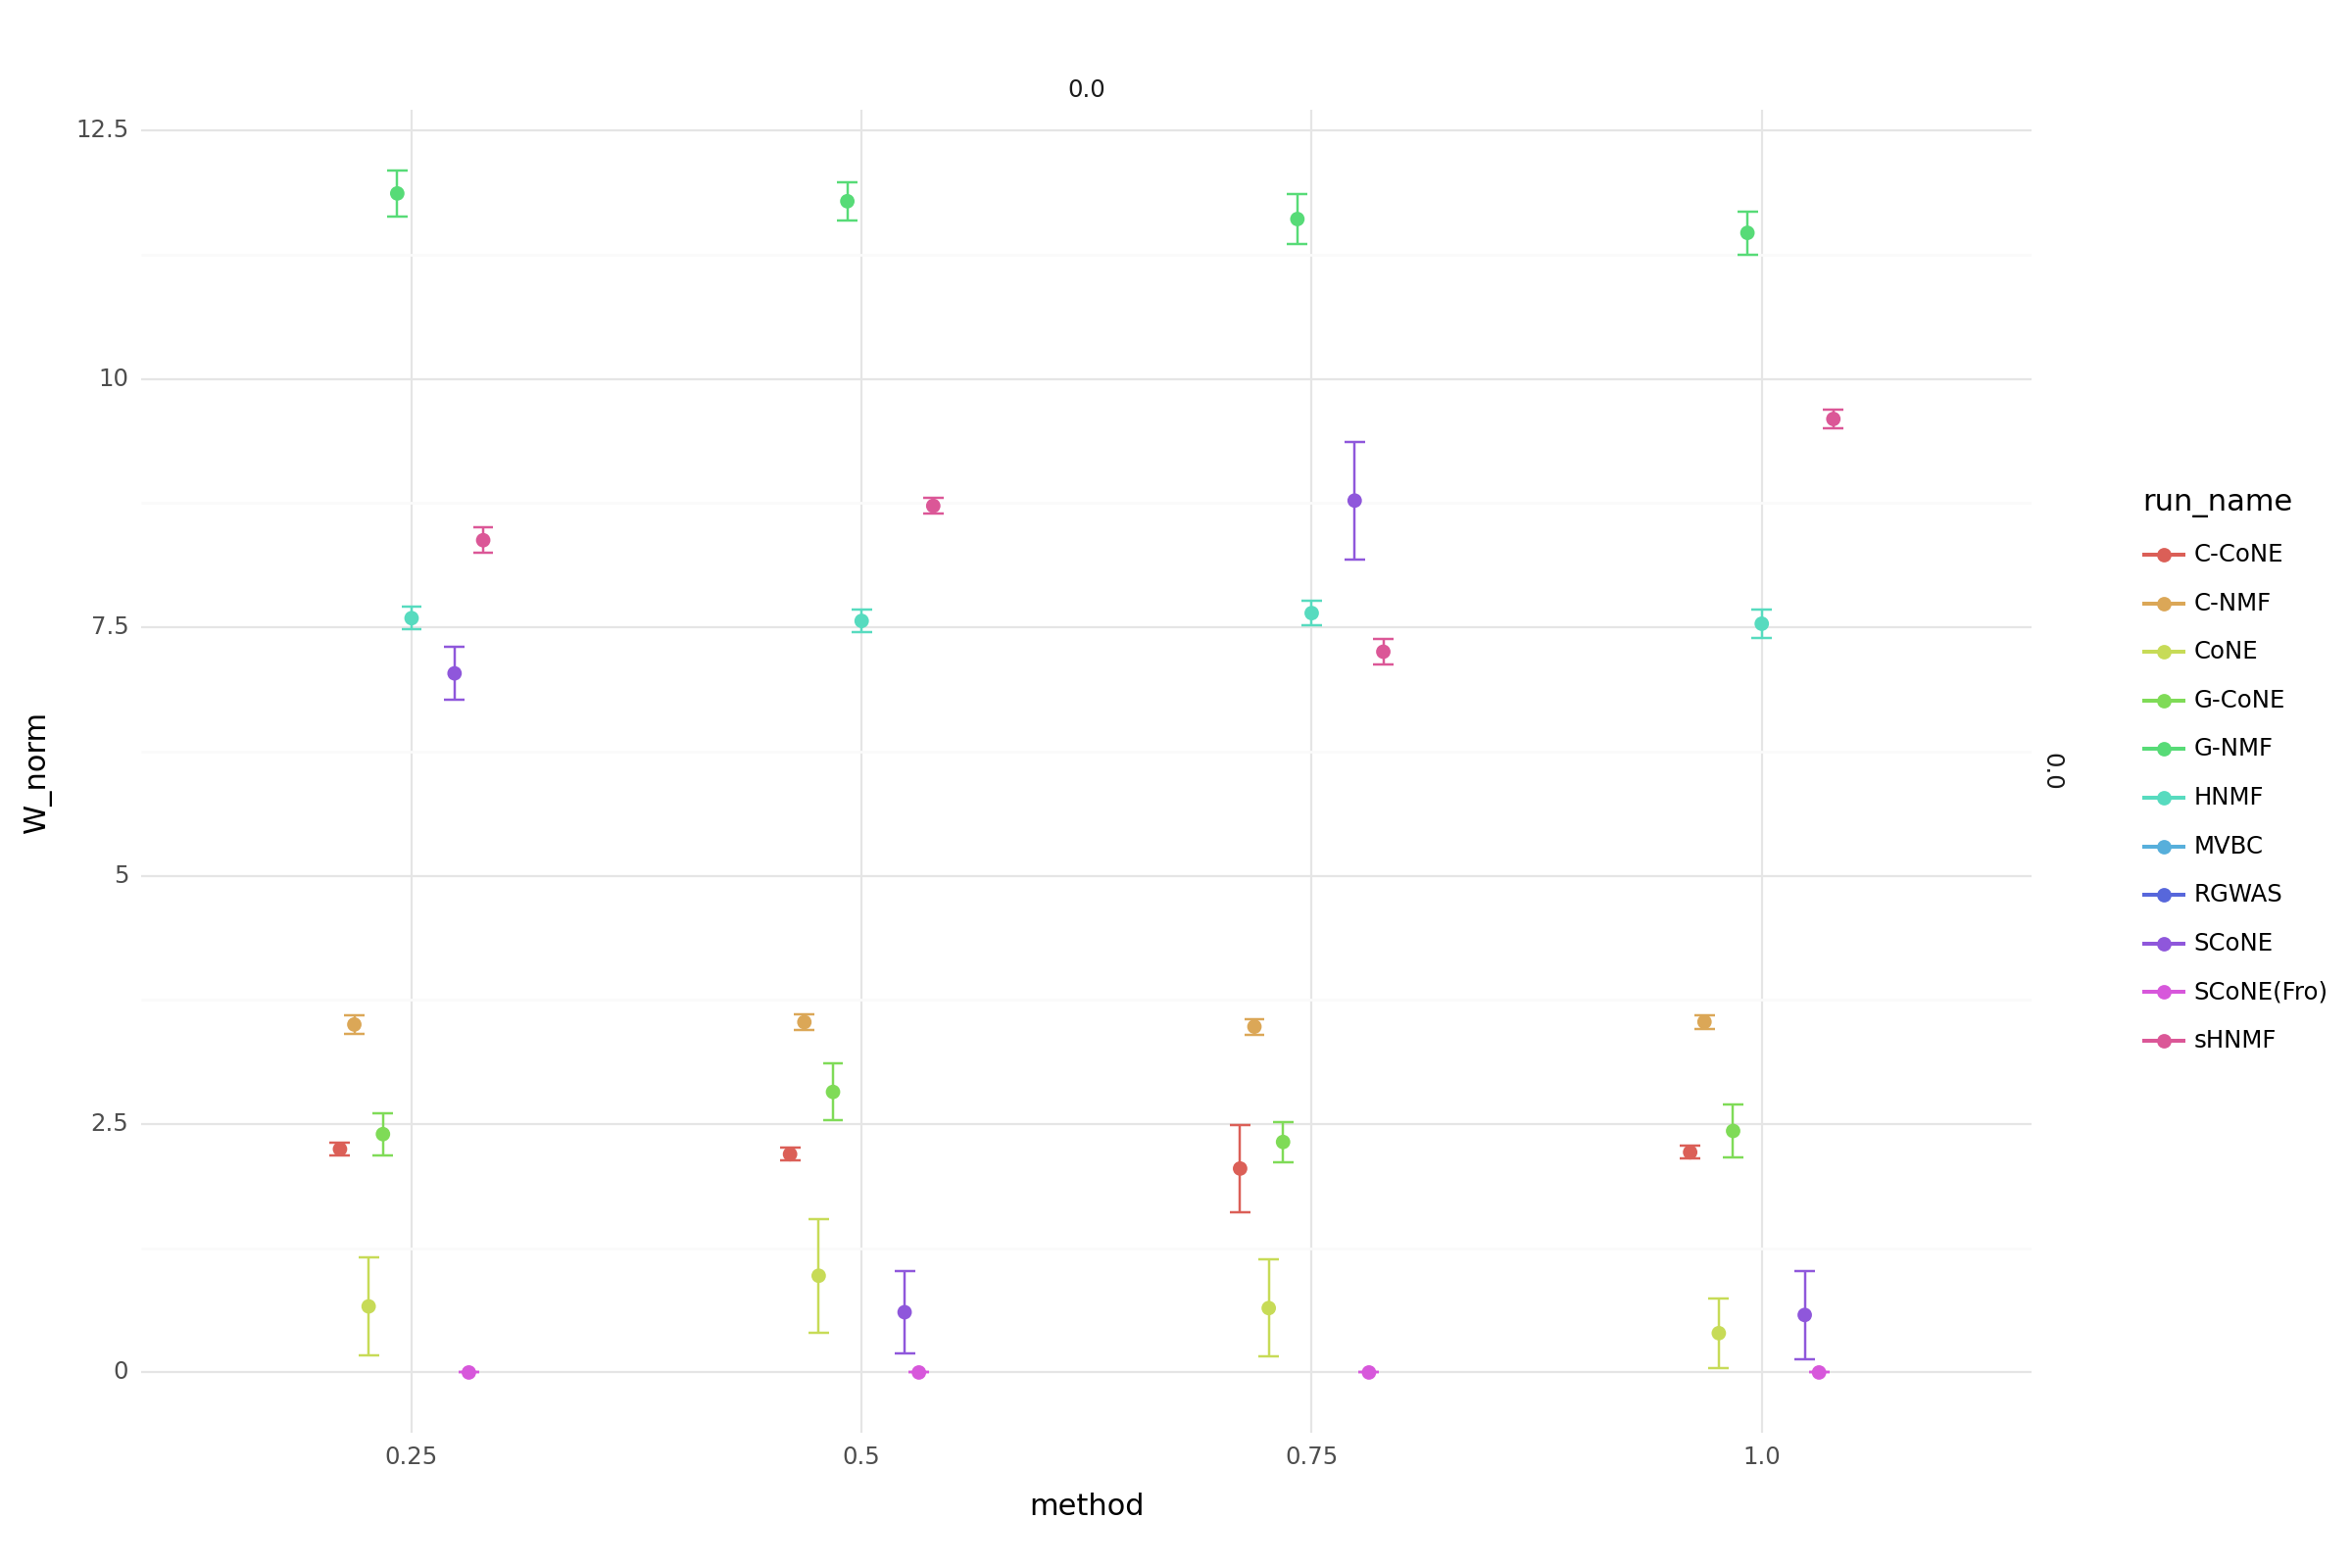

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 8 rows containing missing values.


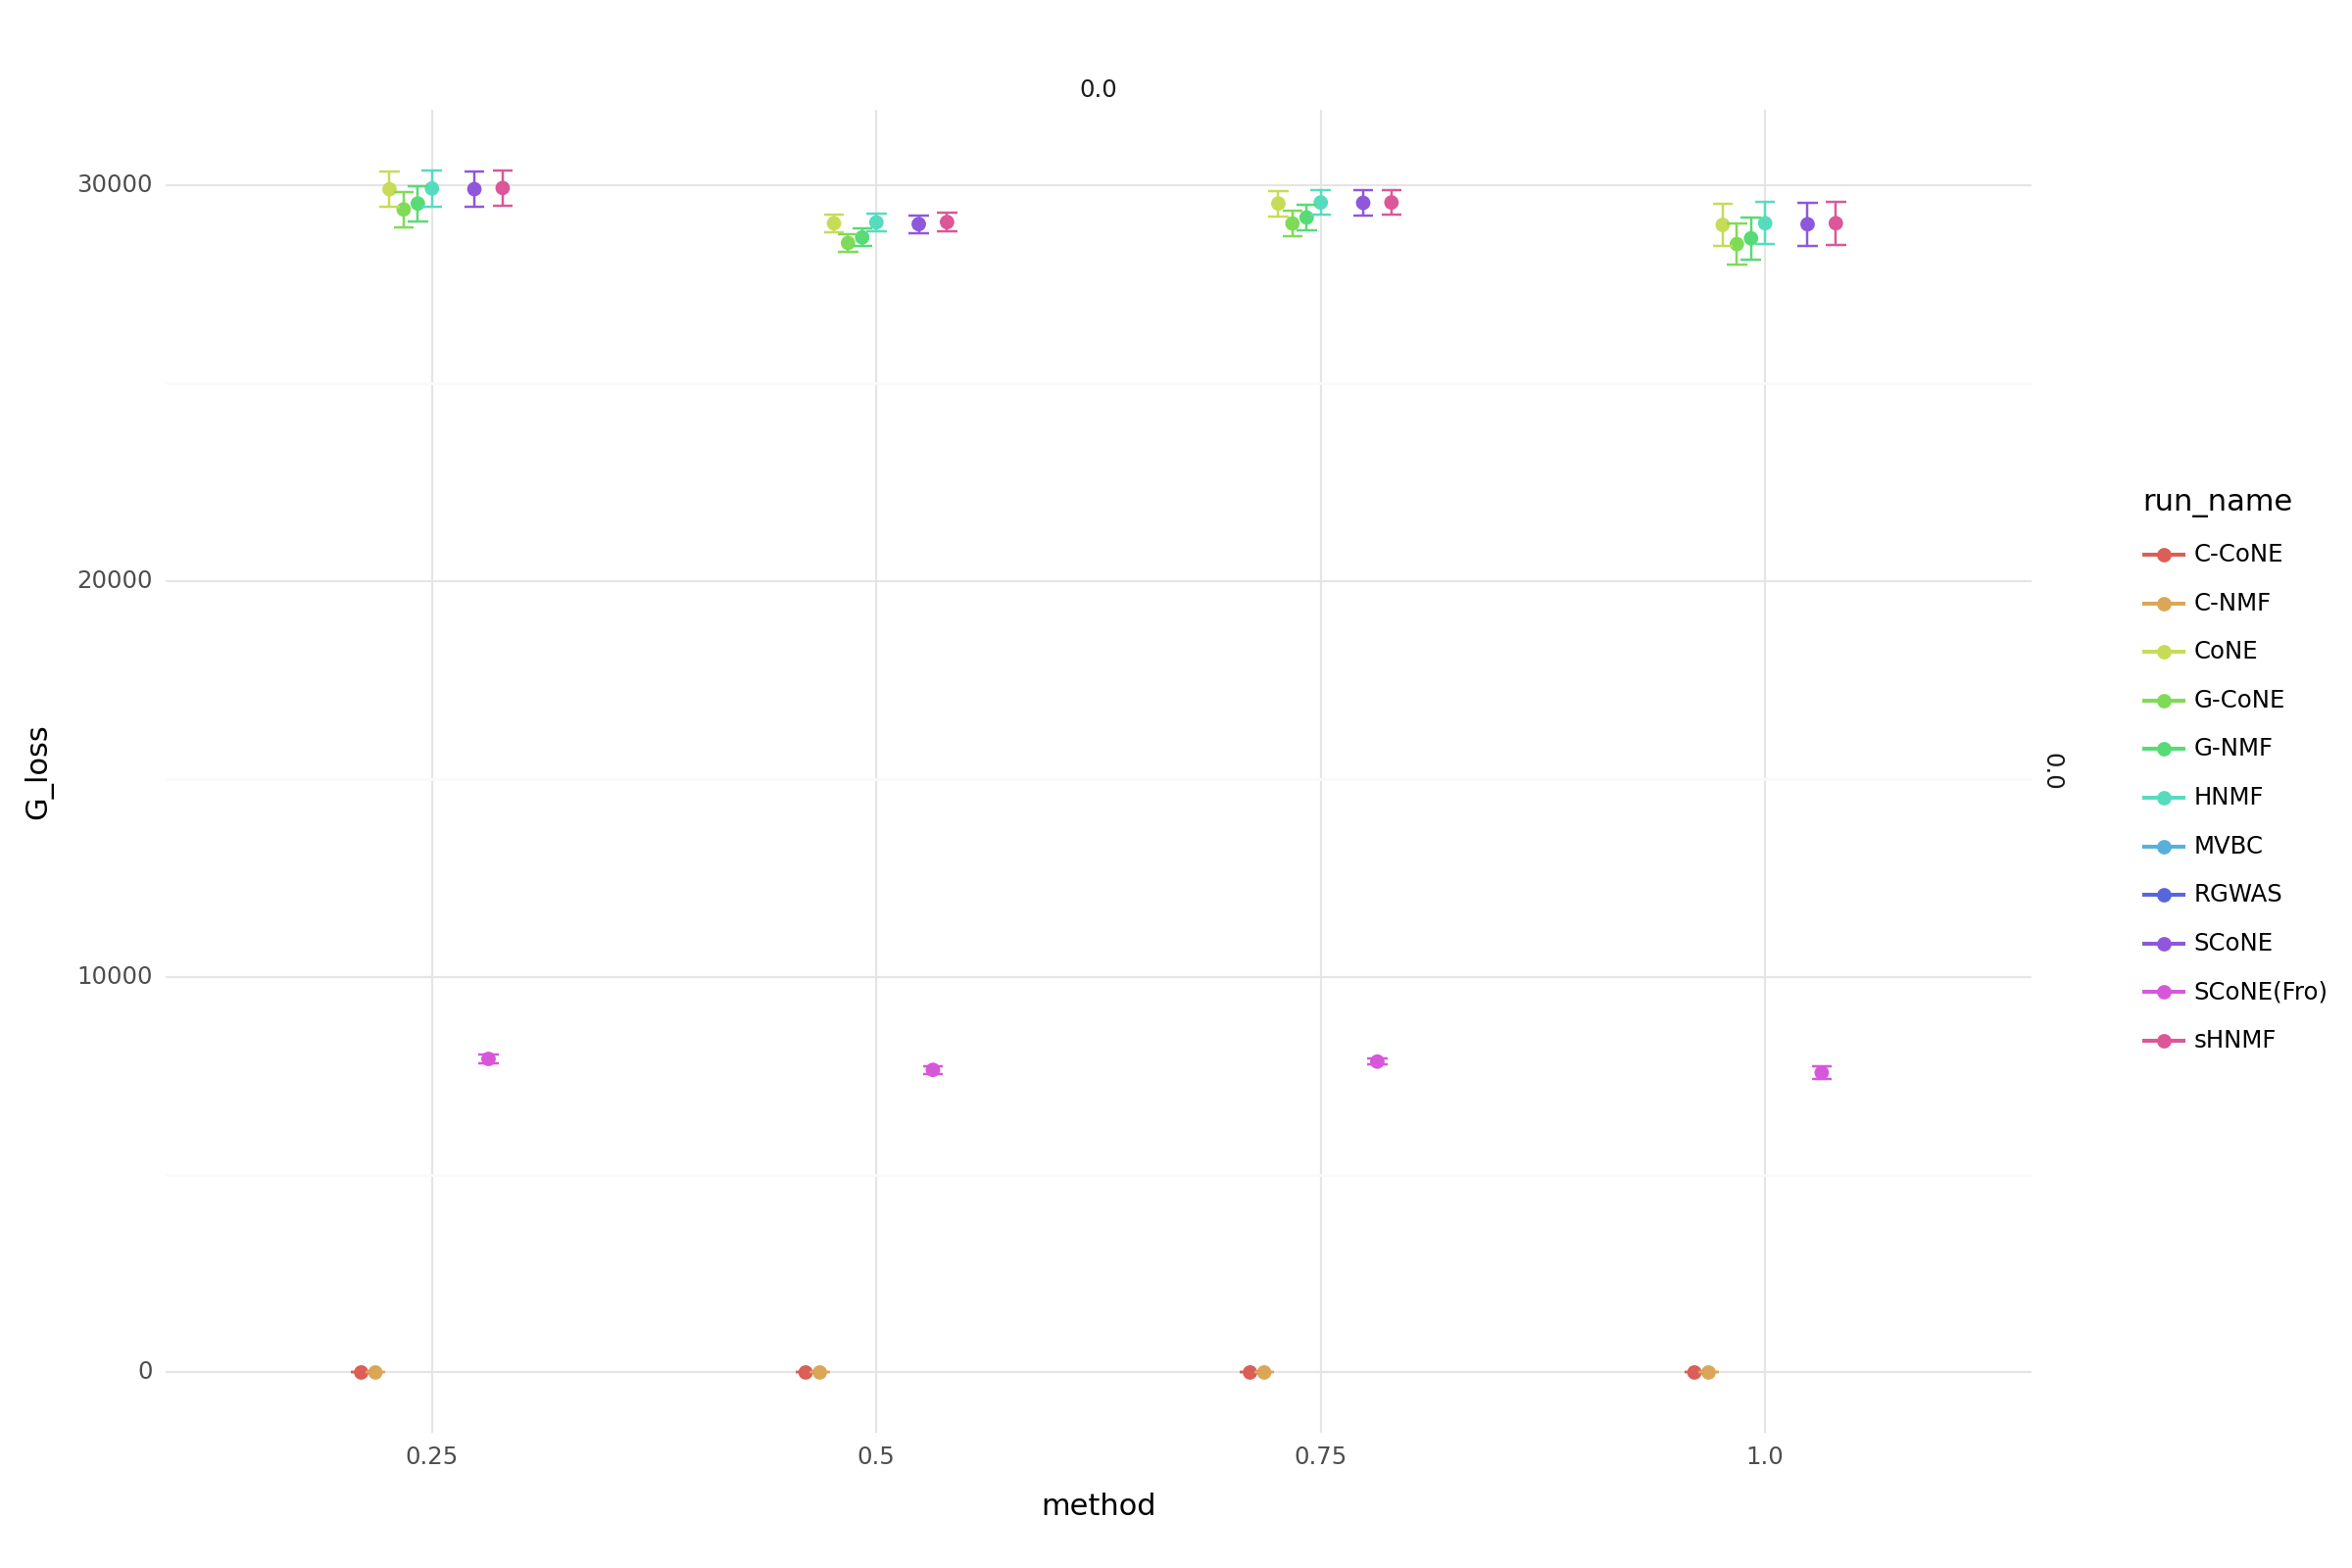

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 8 rows containing missing values.


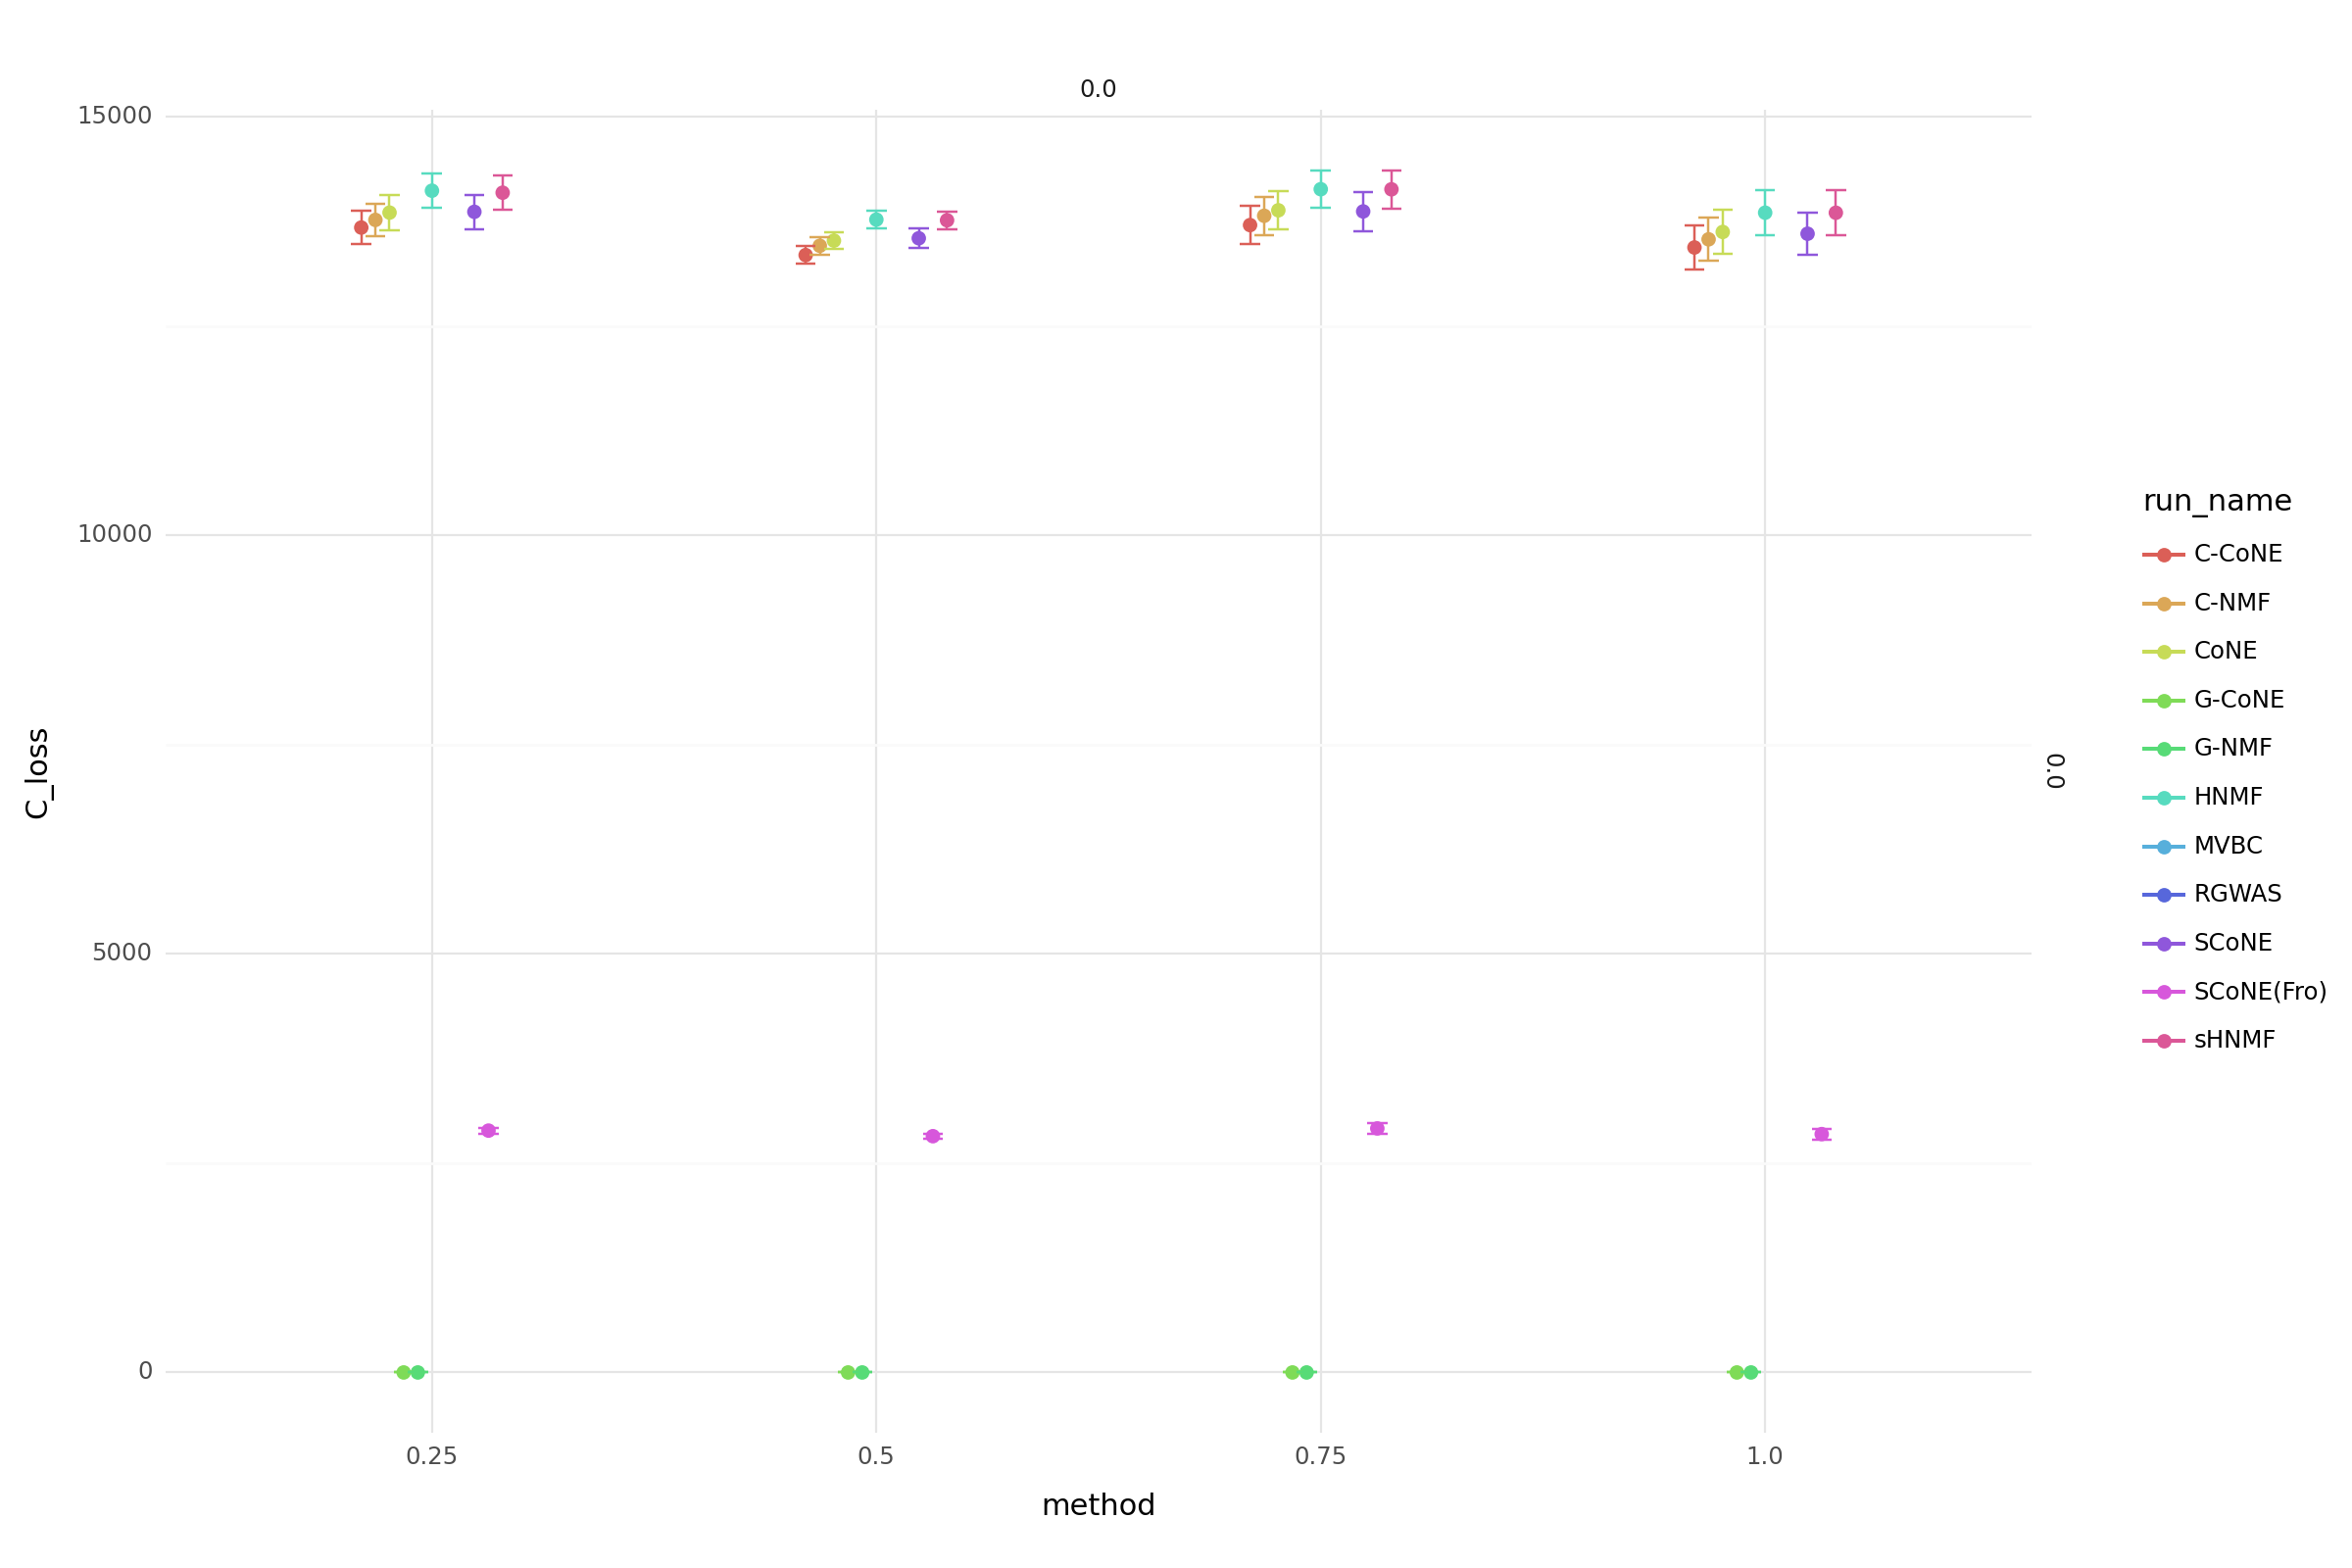

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 8 rows containing missing values.


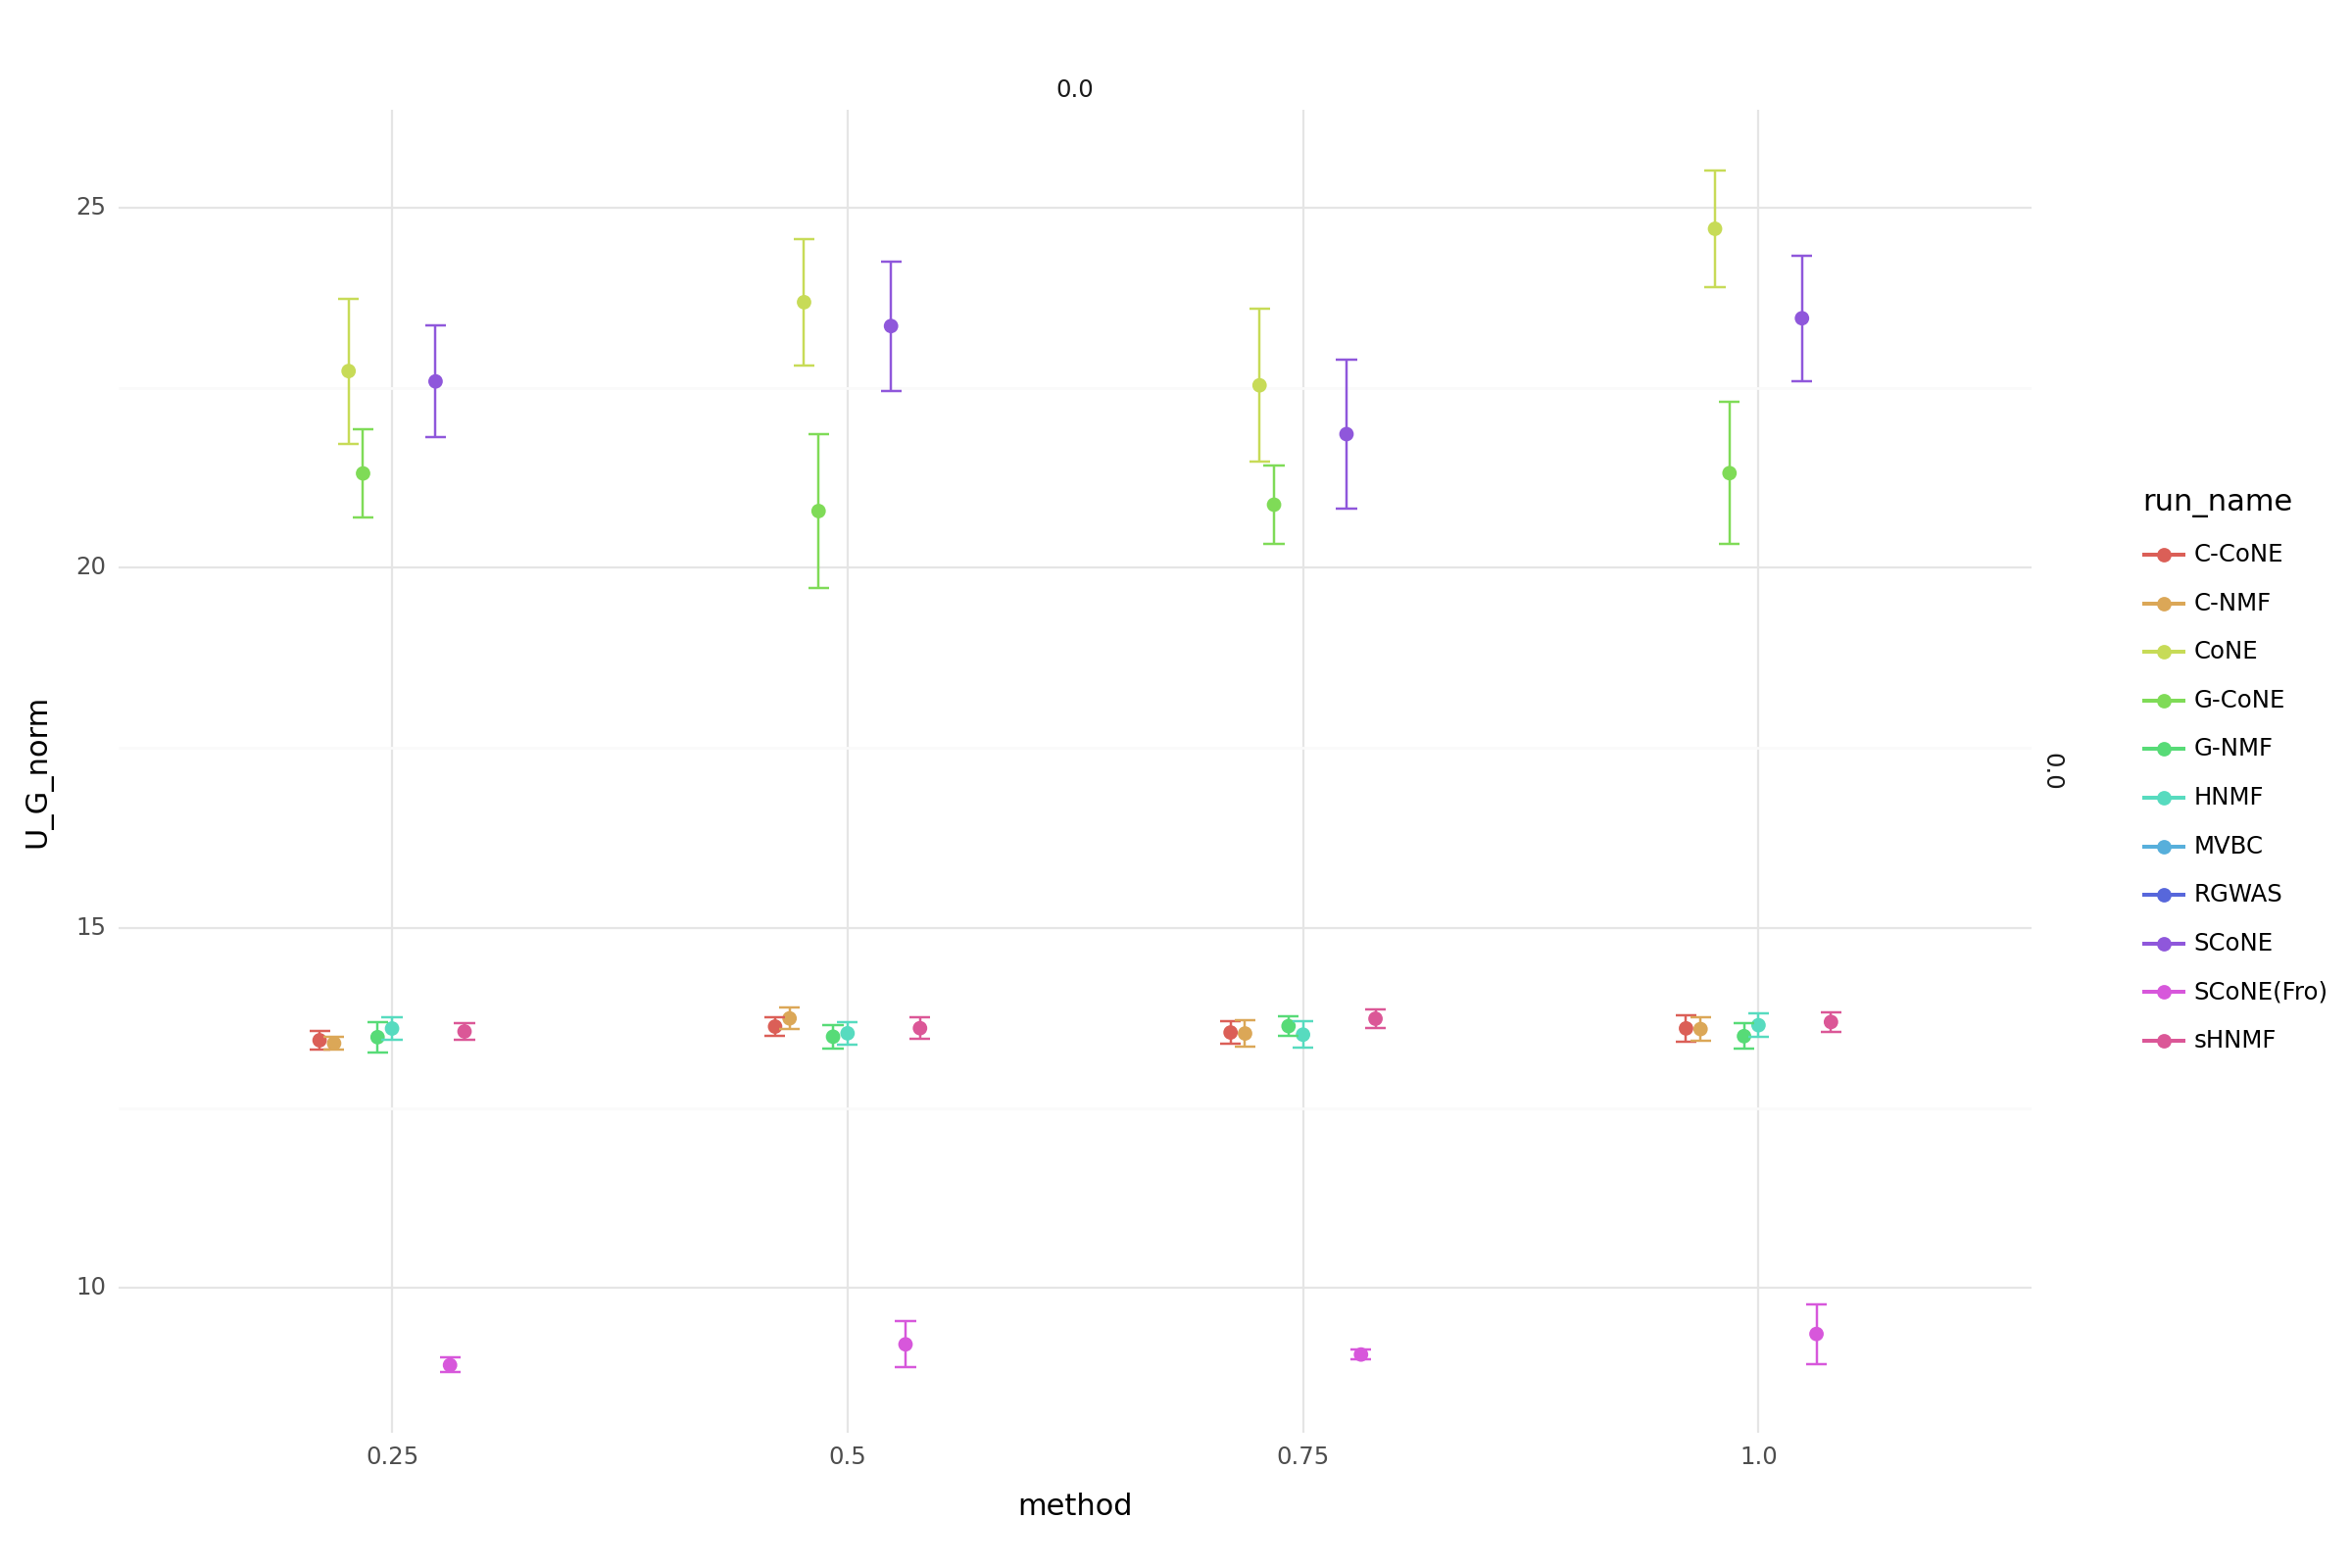

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 8 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 8 rows containing missing values.


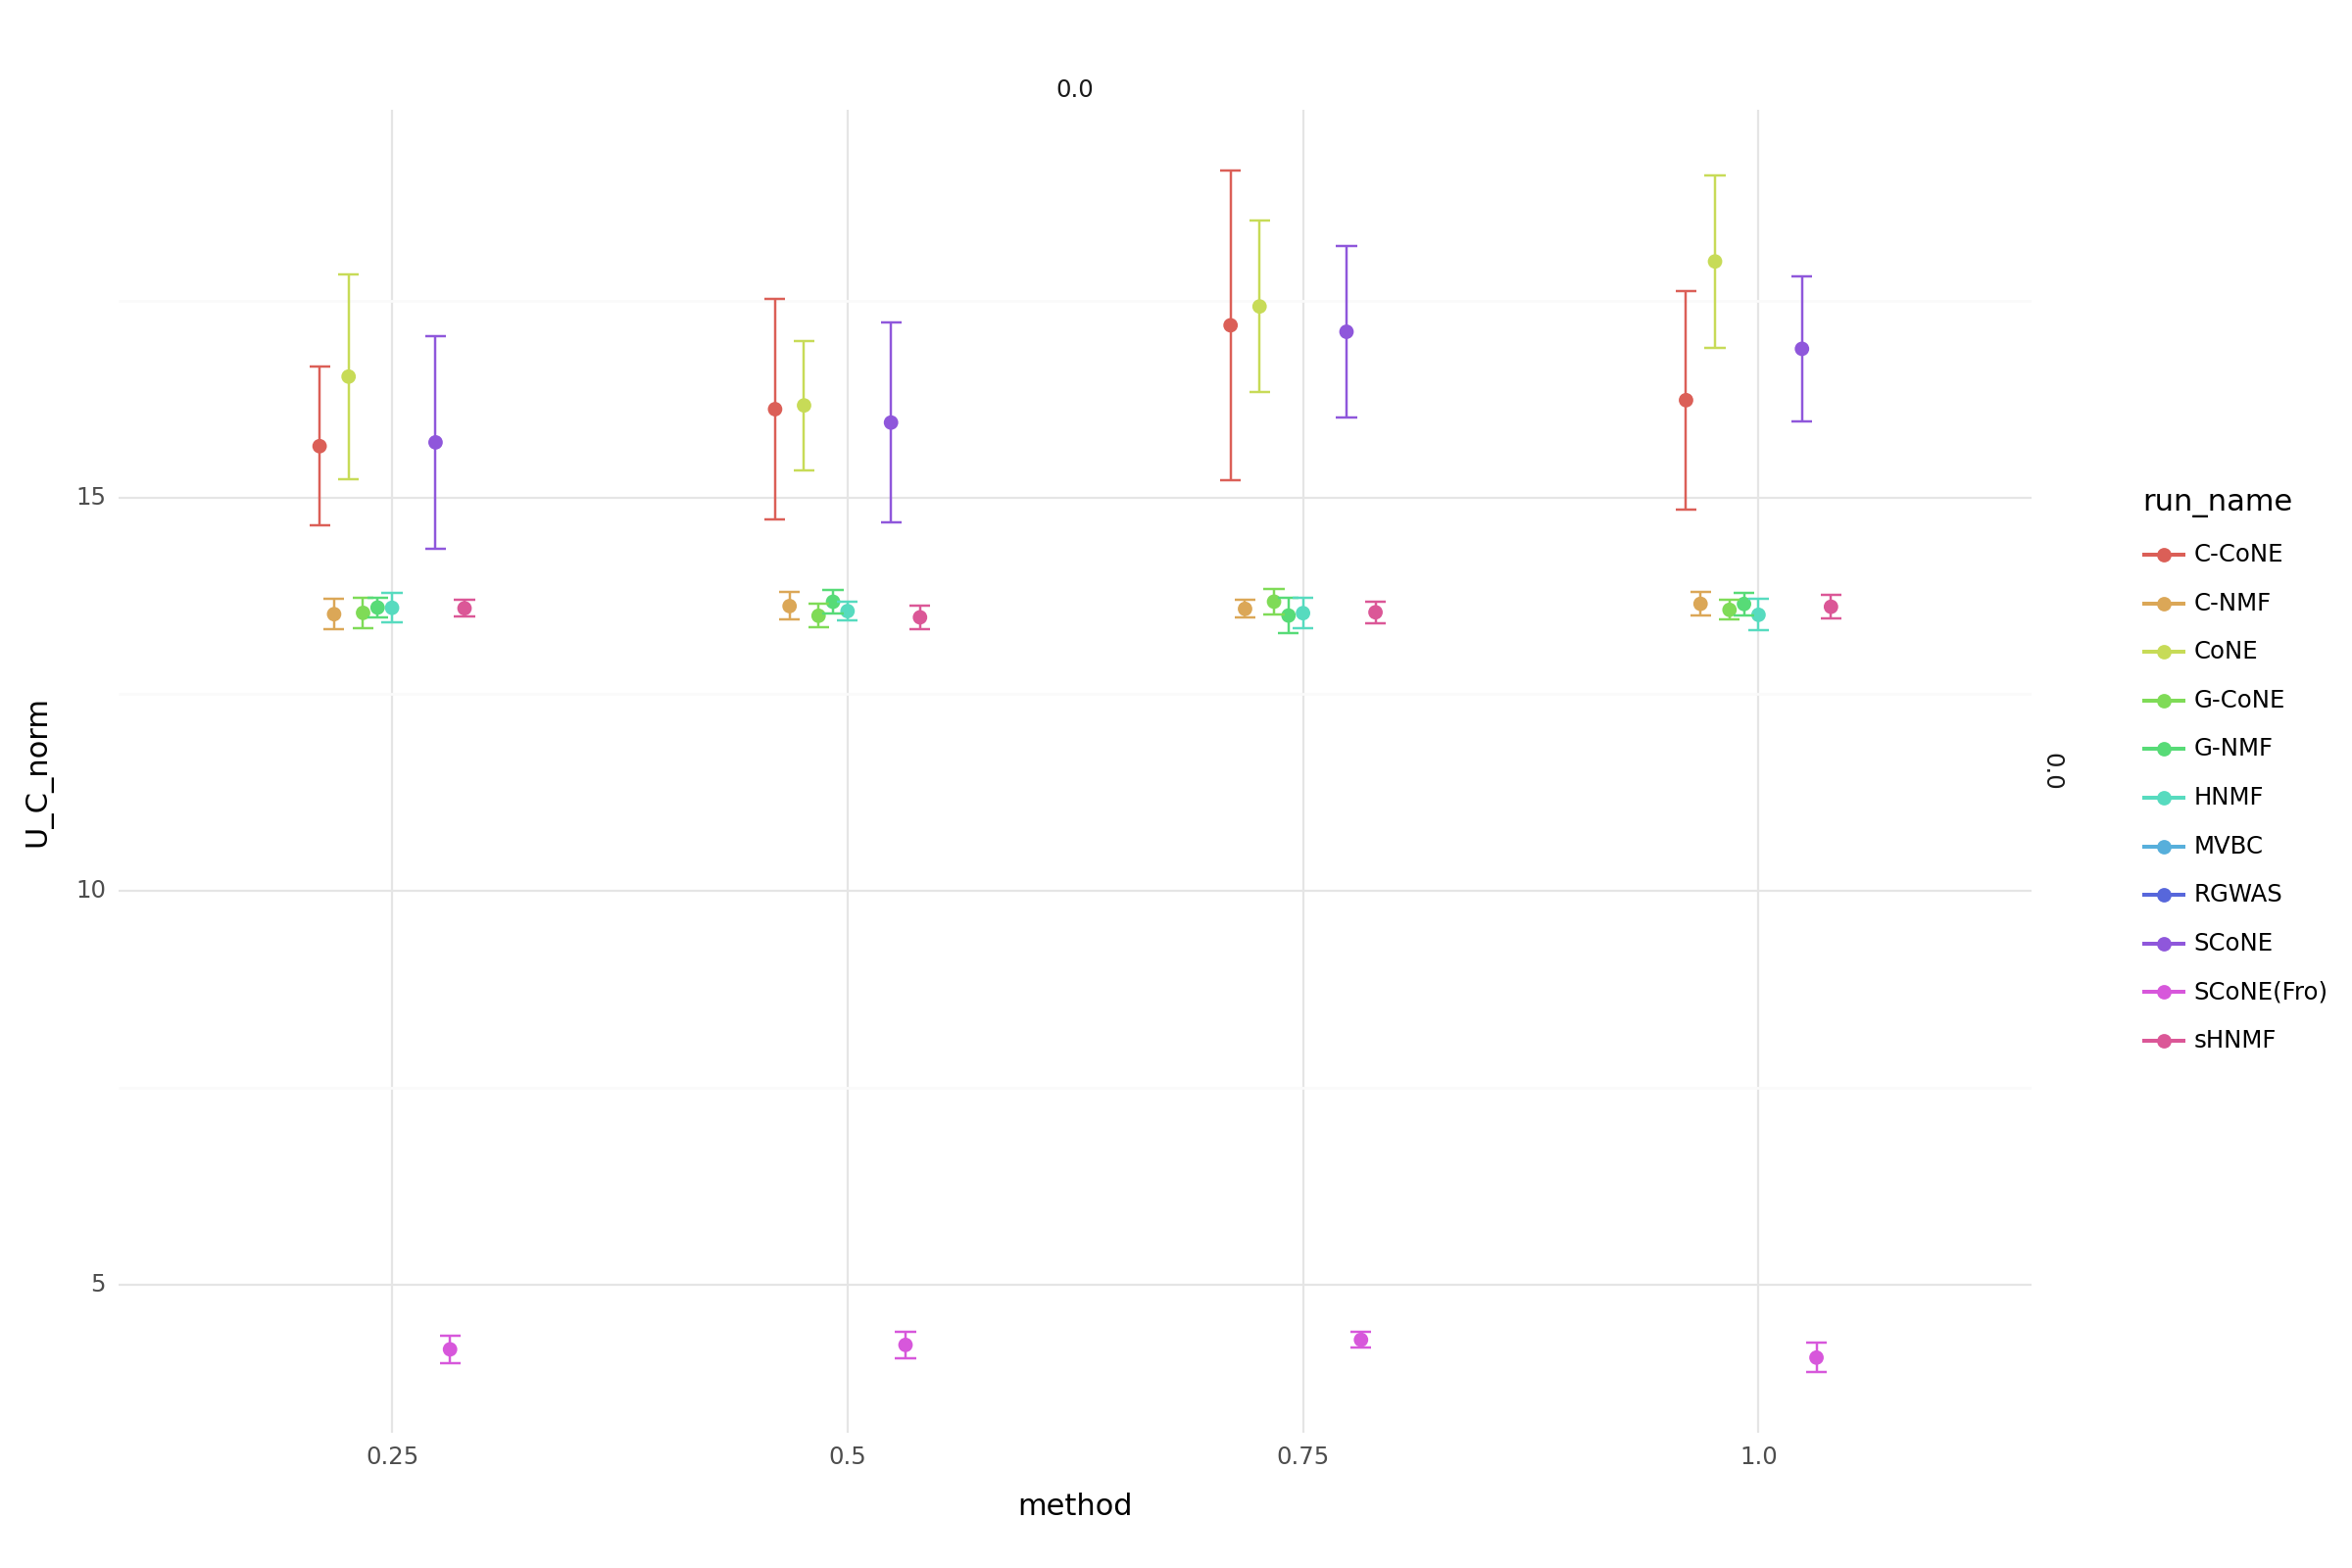

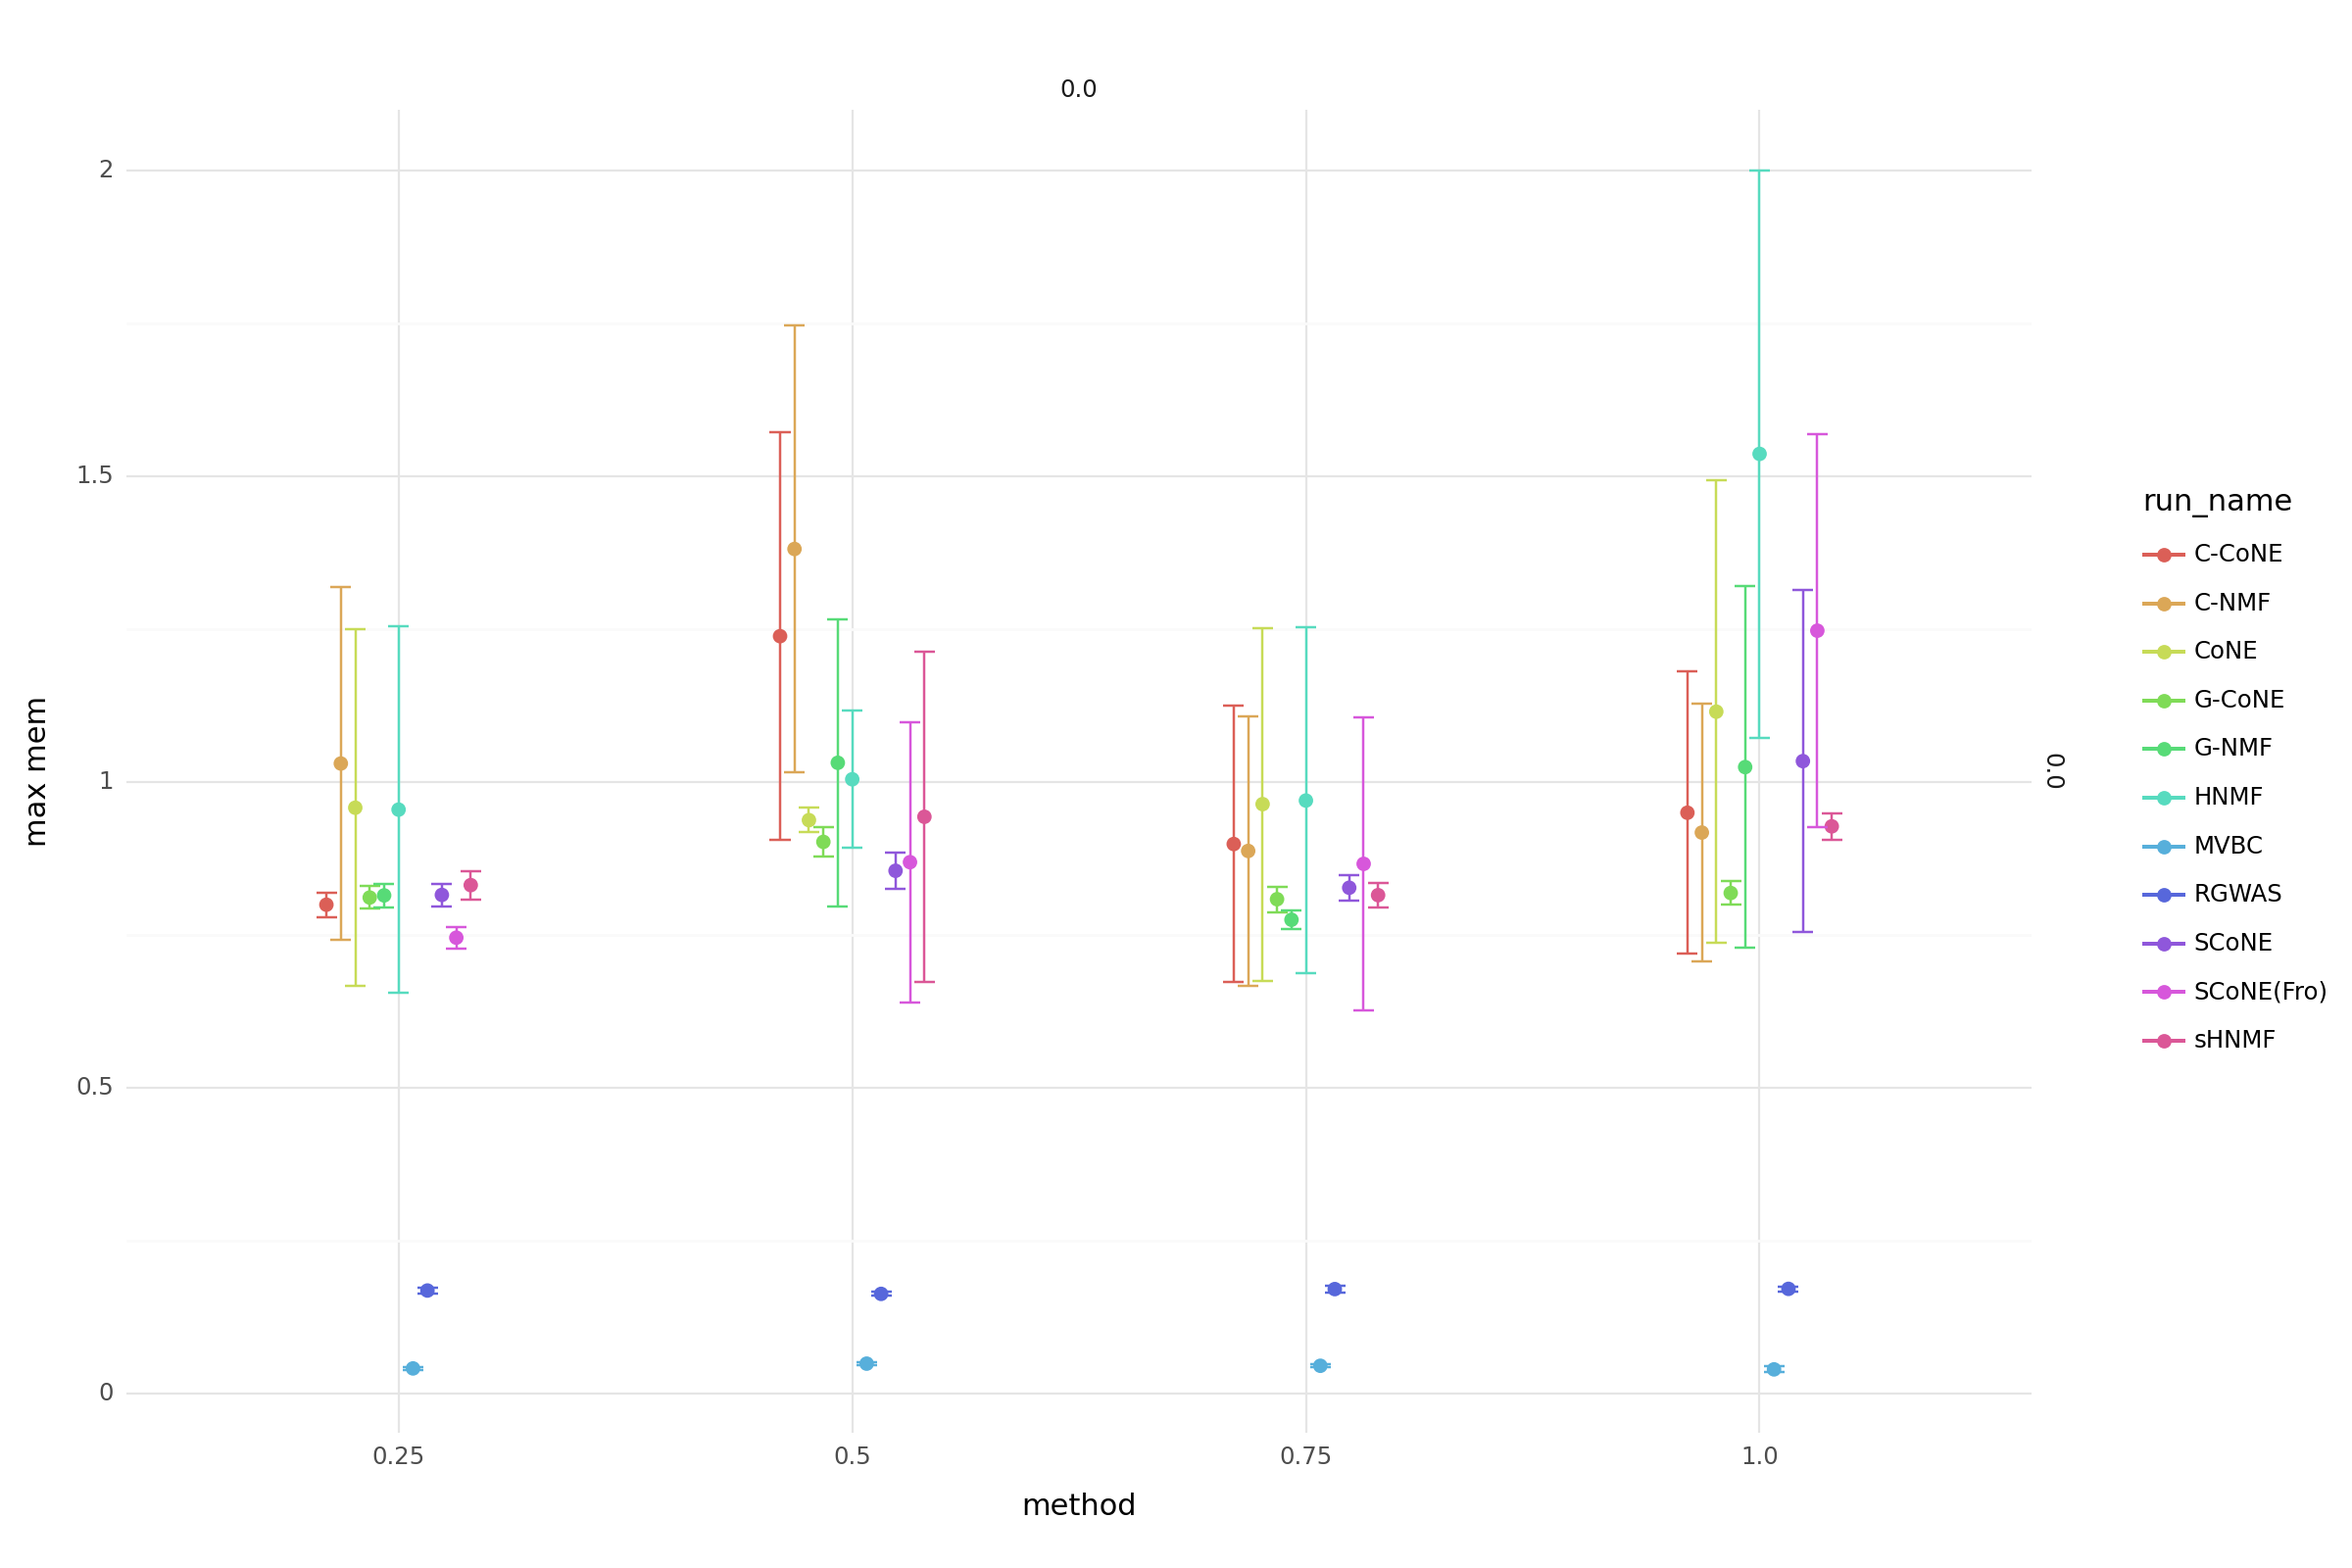

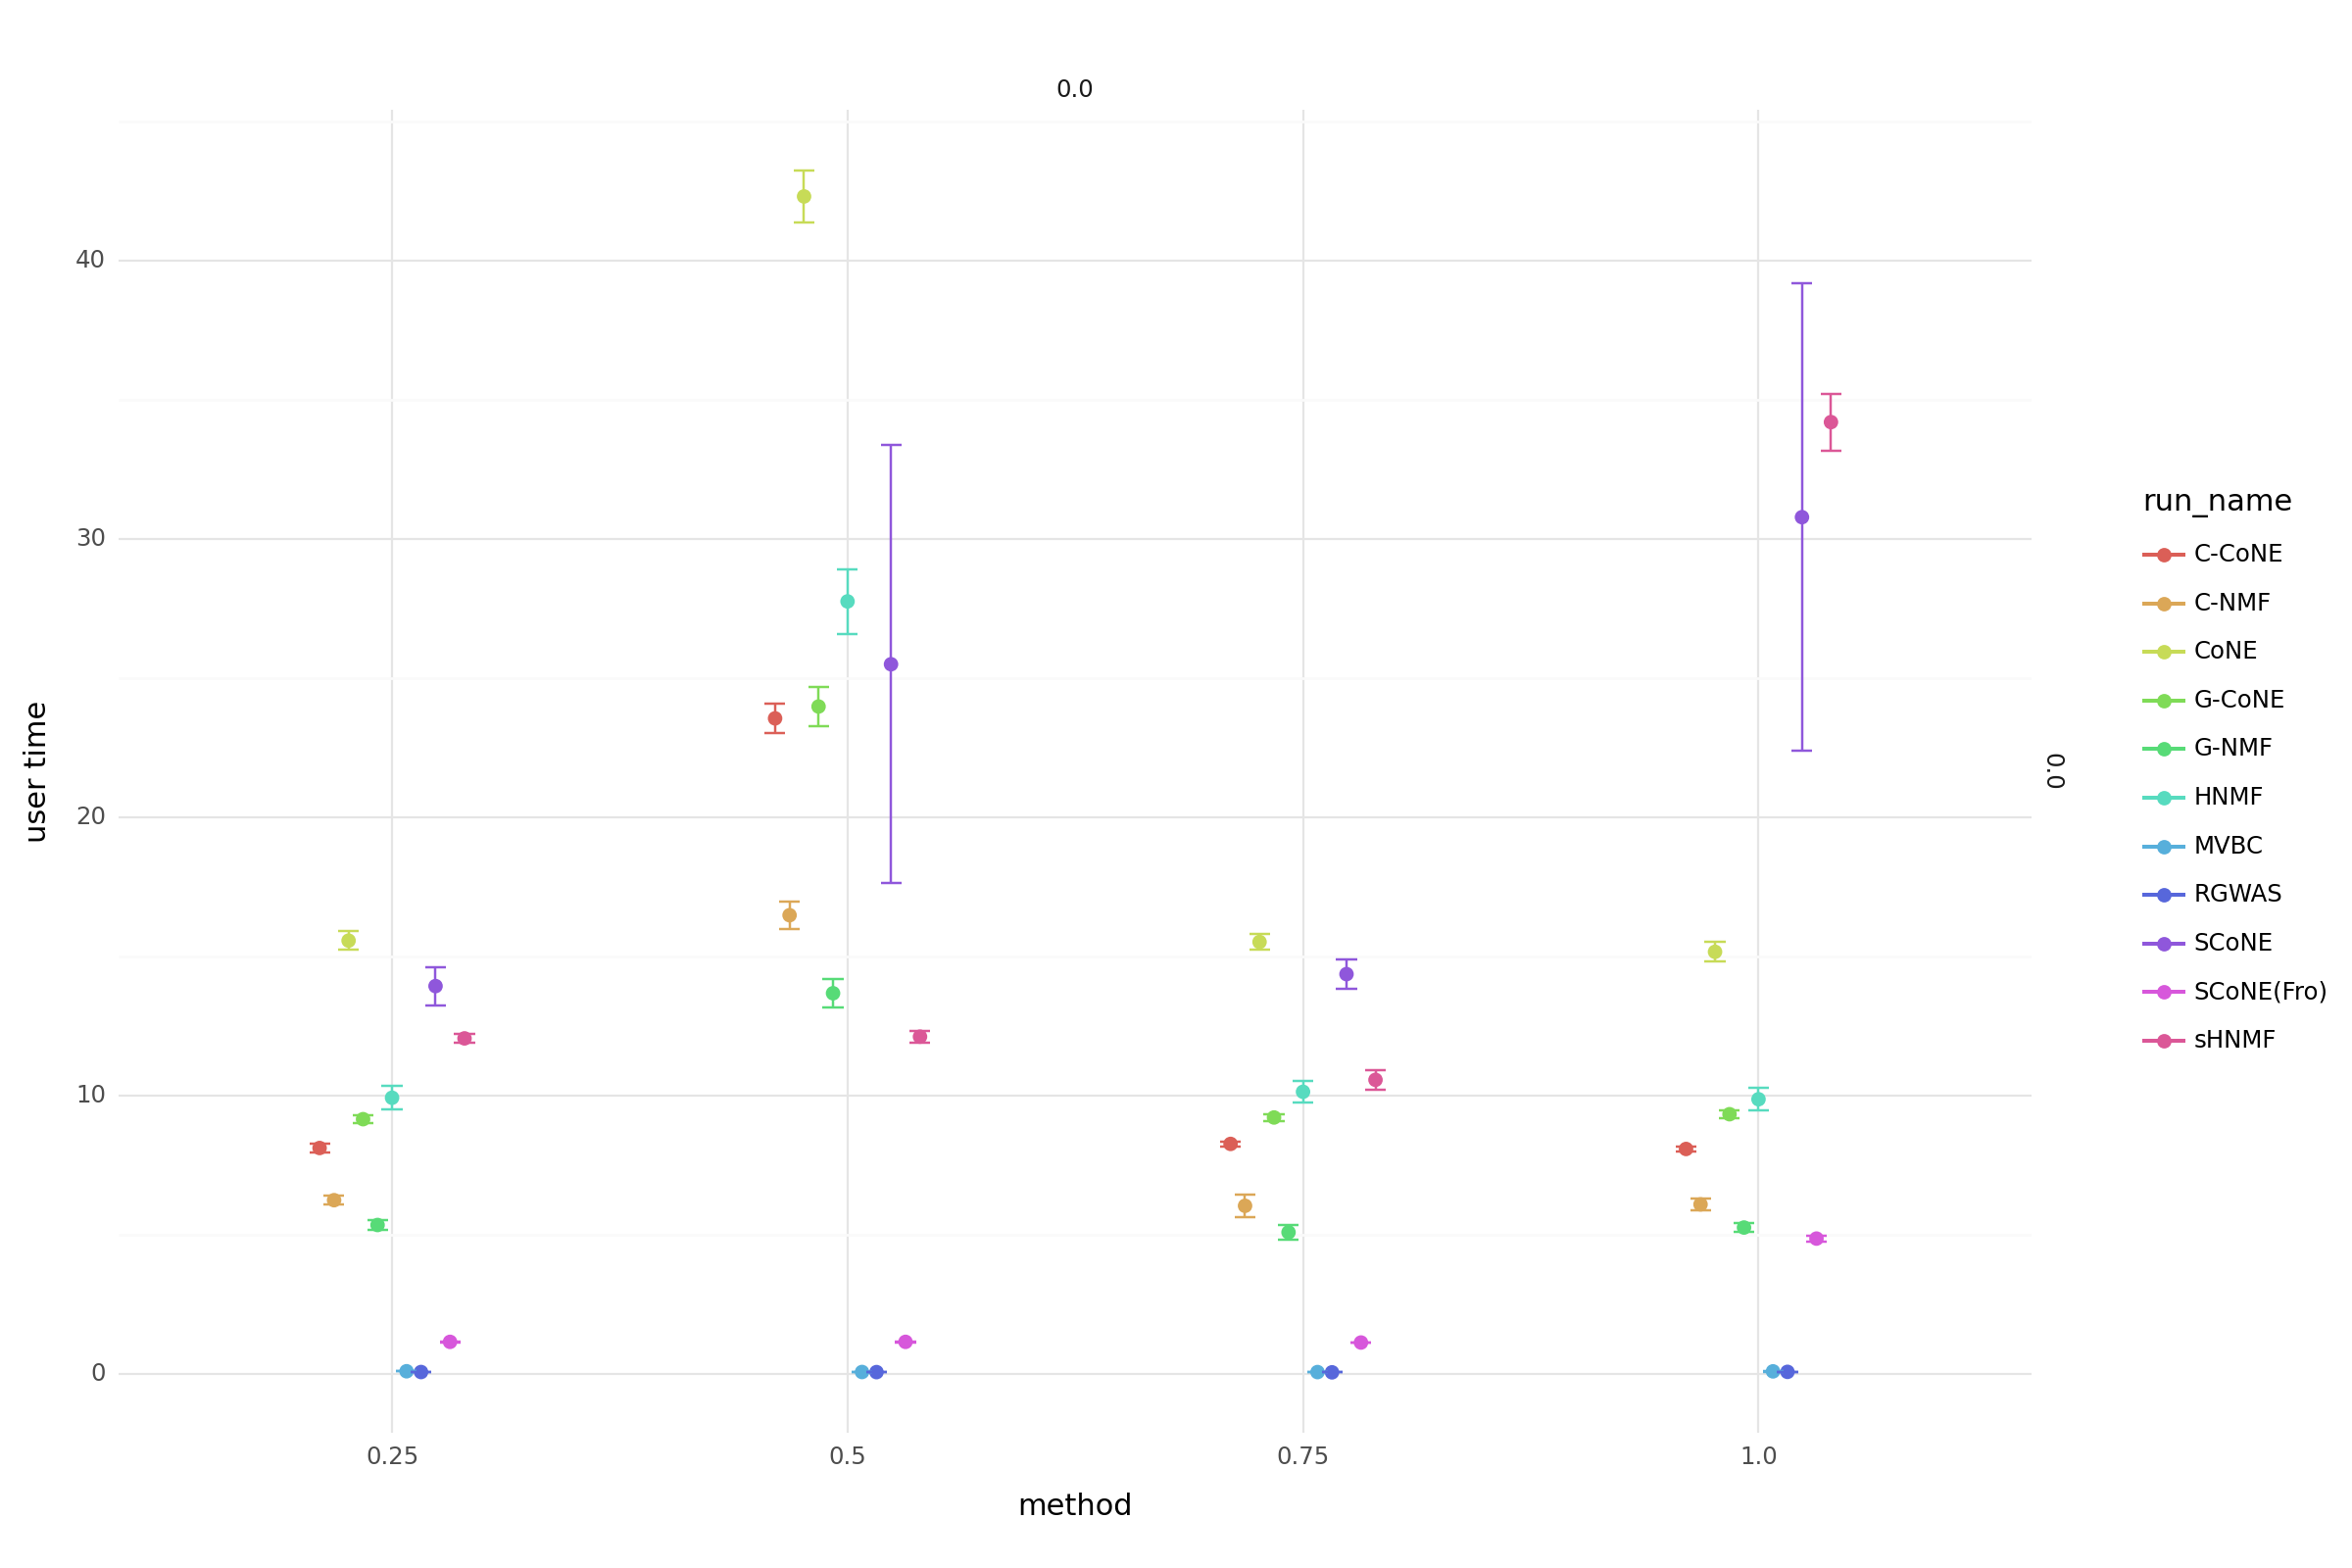

In [264]:
# get CI over 10 random datasets
# [all_runs['run_name'].isin(['RGWAS','MVBC','HNMF','SCoNE'])]
for metric in ['nmi','purity','norm_cond_entropy','W_norm','G_loss','C_loss','U_G_norm','U_C_norm','max mem','user time']:
    summary = (
        all_runs.groupby(["run_name", "g_ps", "c_ps", "e"])[metric]
            .agg(n='count', mean='mean', std='std').reset_index()
    )
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    summary["ymin"] = summary["mean"] - summary["ci95"]
    summary["ymax"] = summary["mean"] + summary["ci95"]
    p = (
    ggplot(summary, aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
    + geom_point(size=2,position=dodge)
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
    + labs(x="method", y=metric, title='')
    + facet_grid('g_ps ~ c_ps')
    + theme_minimal()
    + theme(figure_size=(12,8))
    )
    print(p)


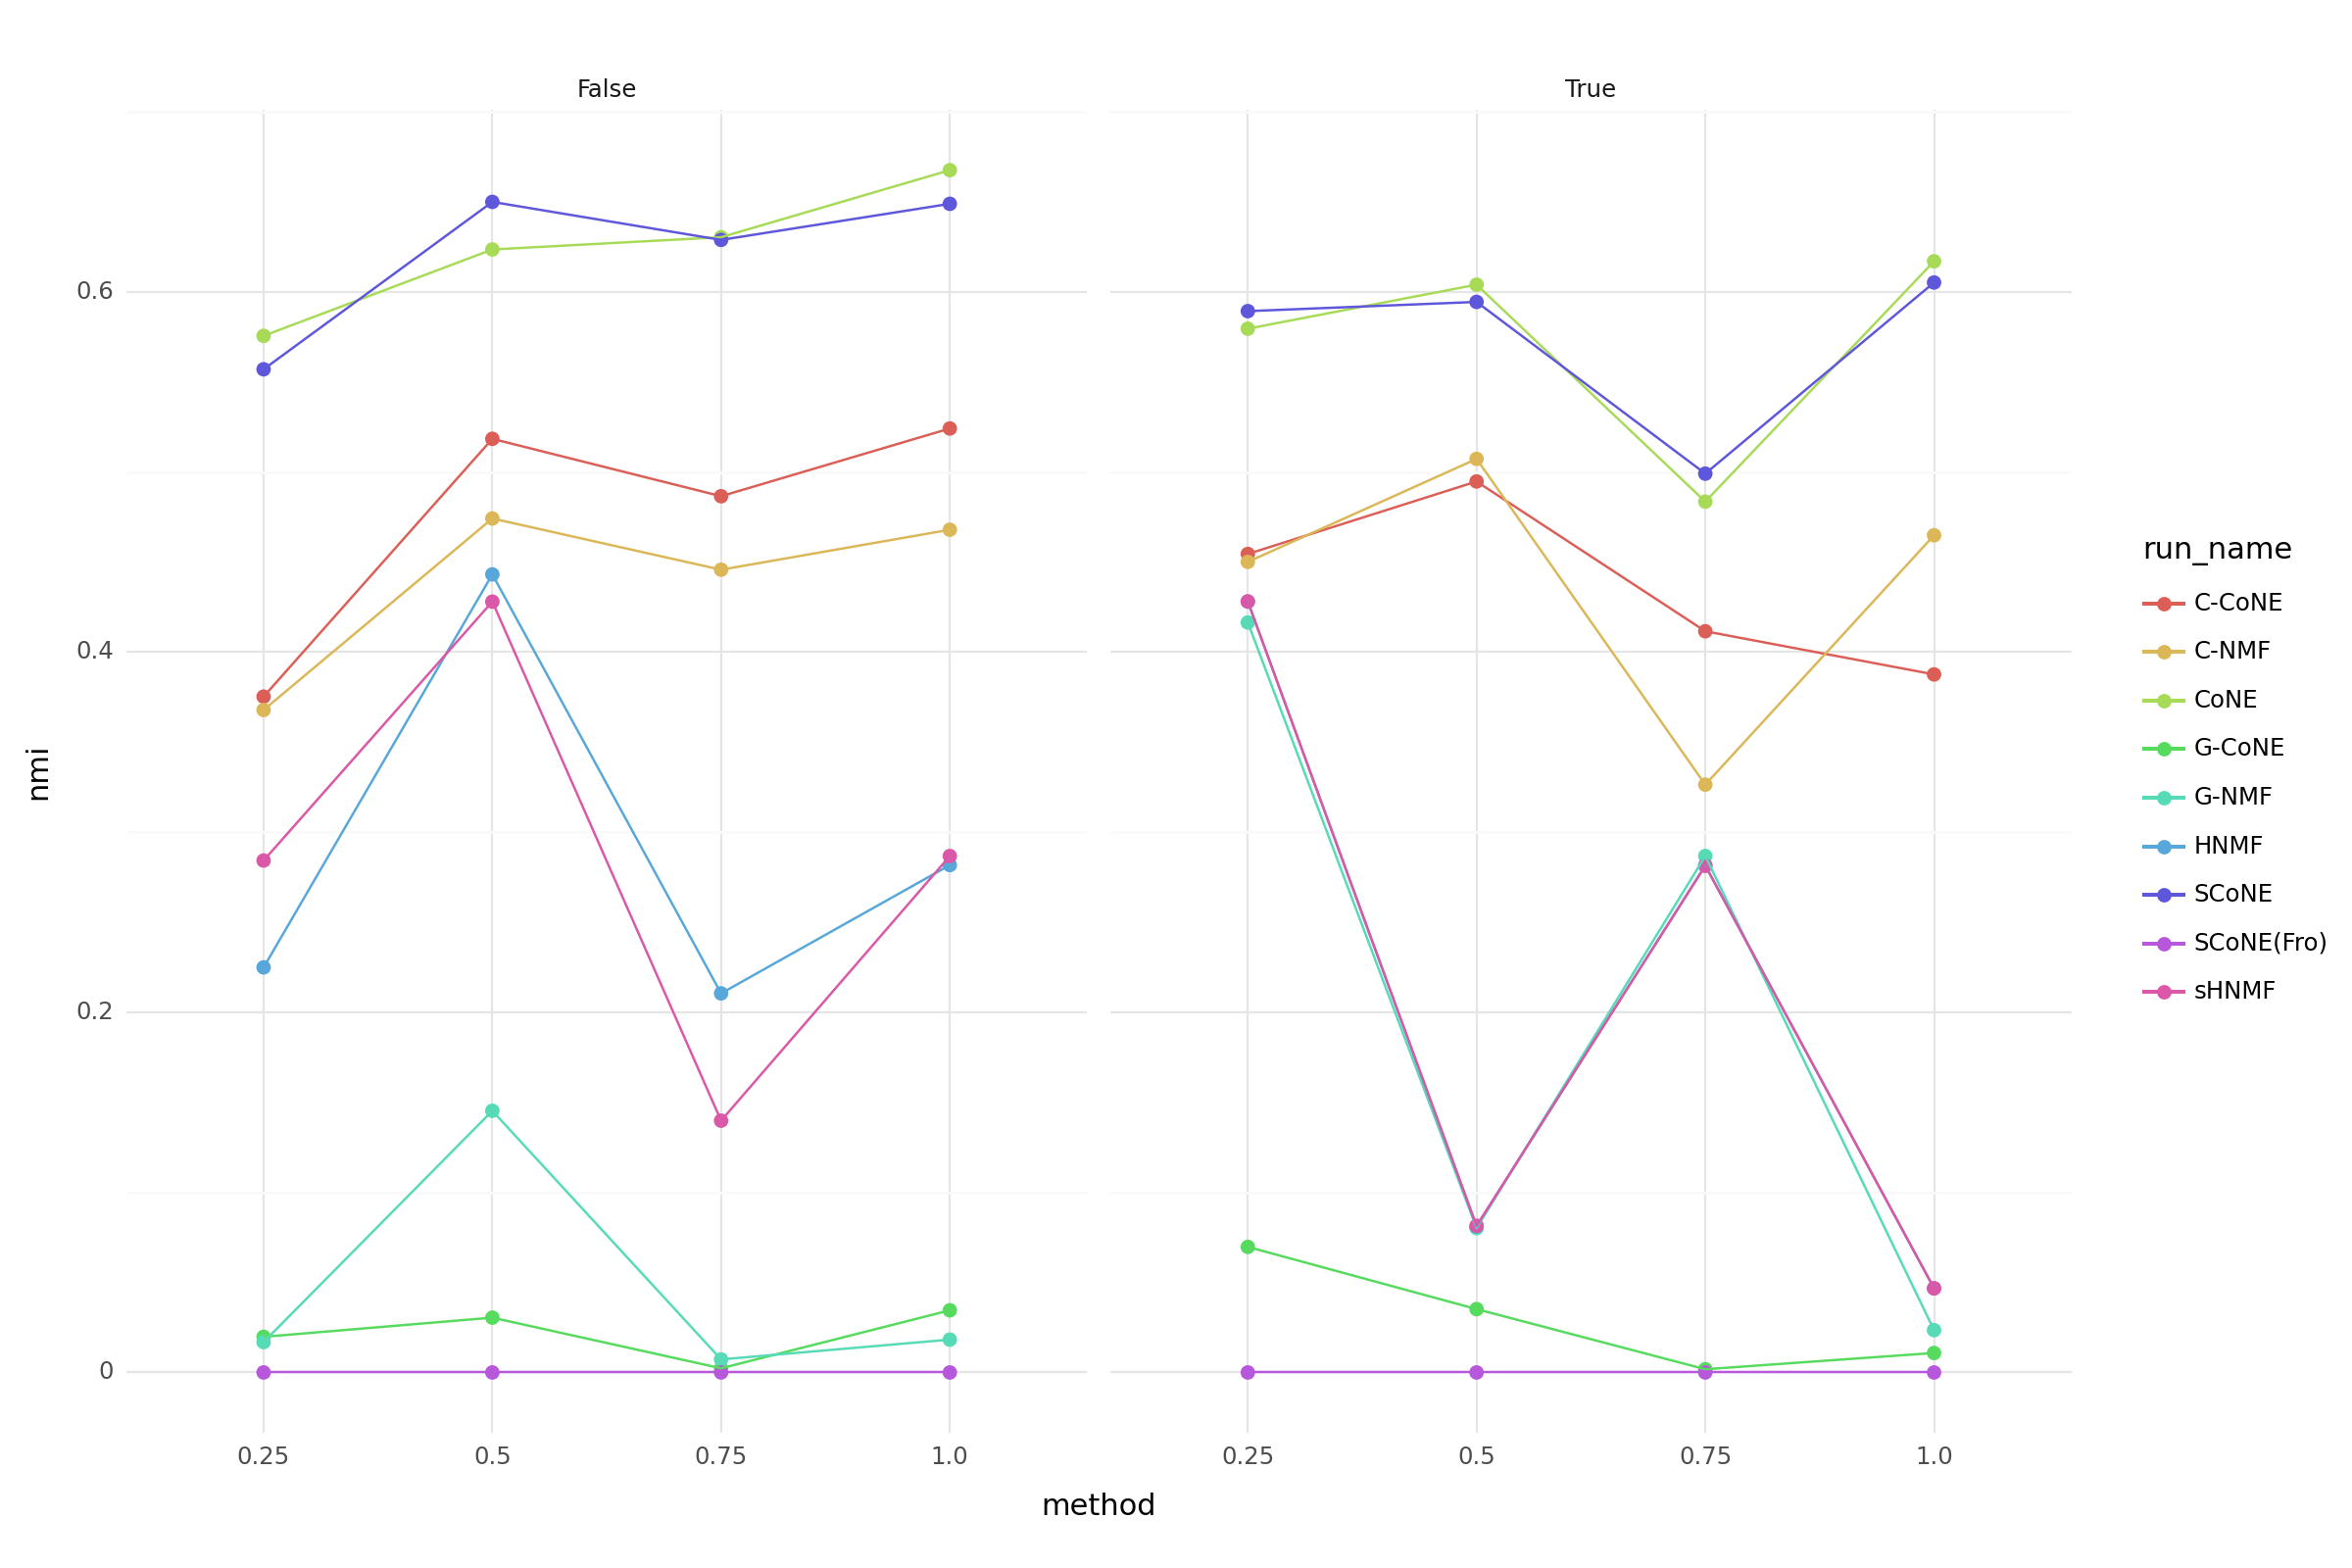

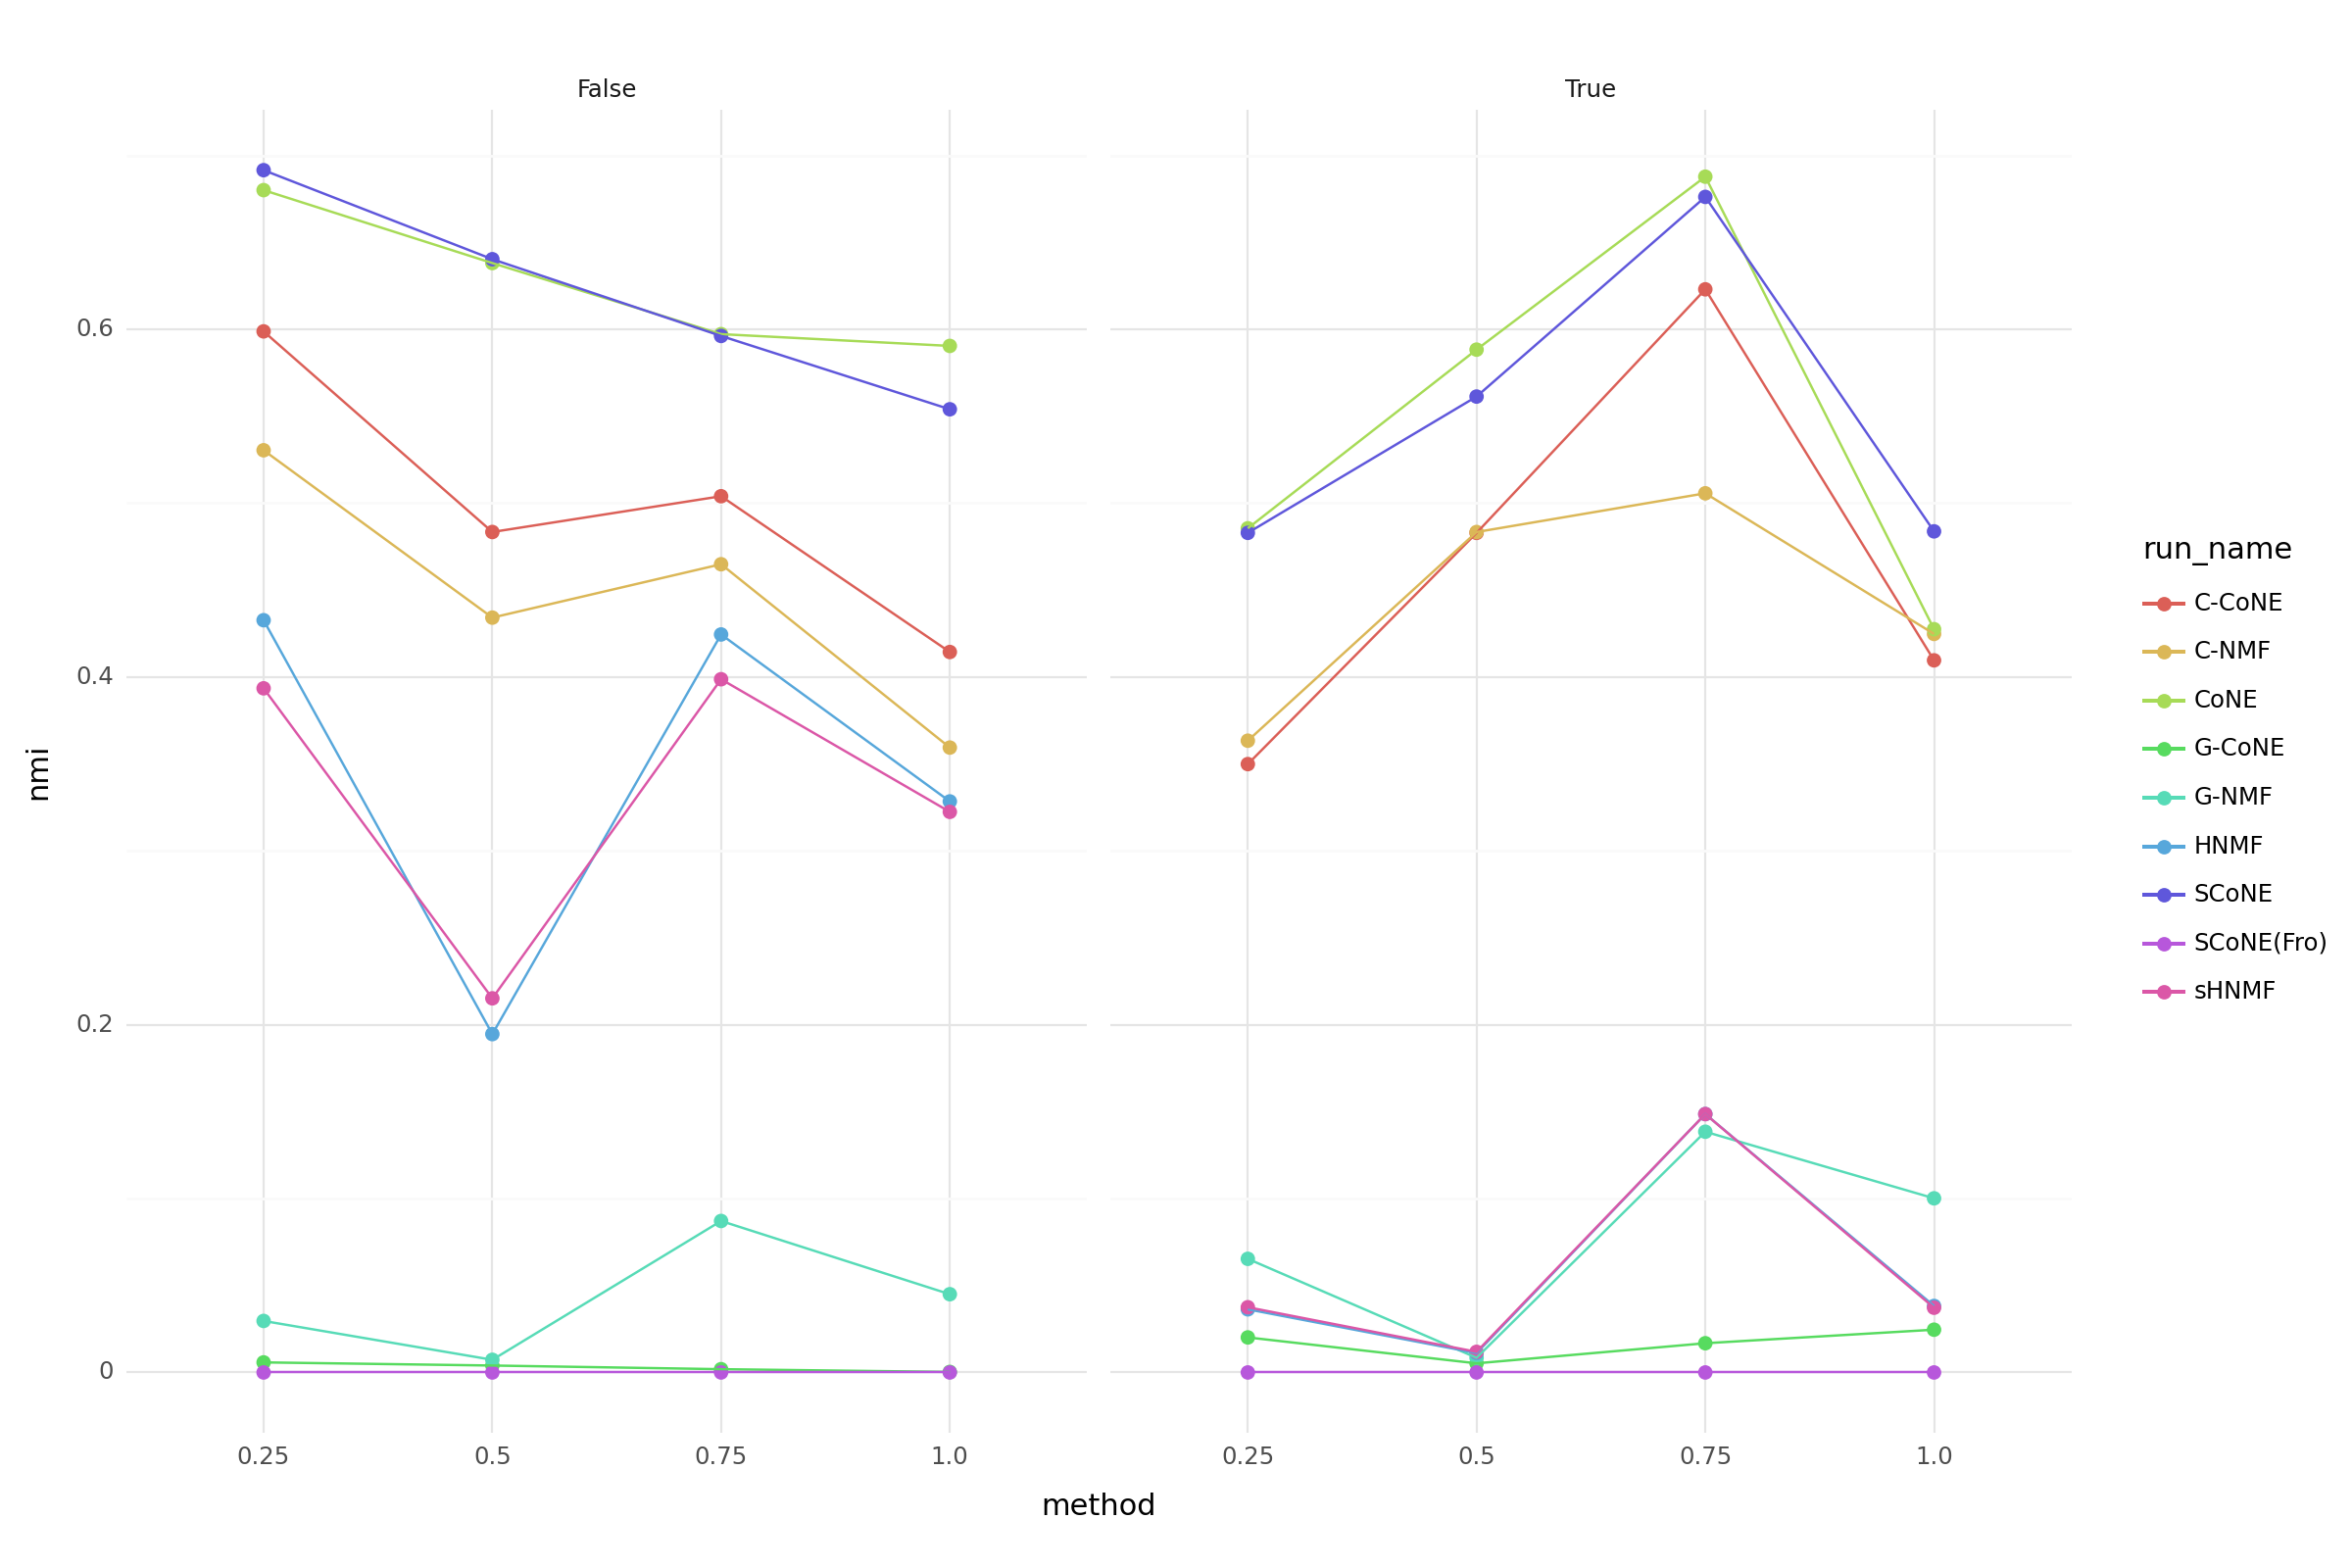

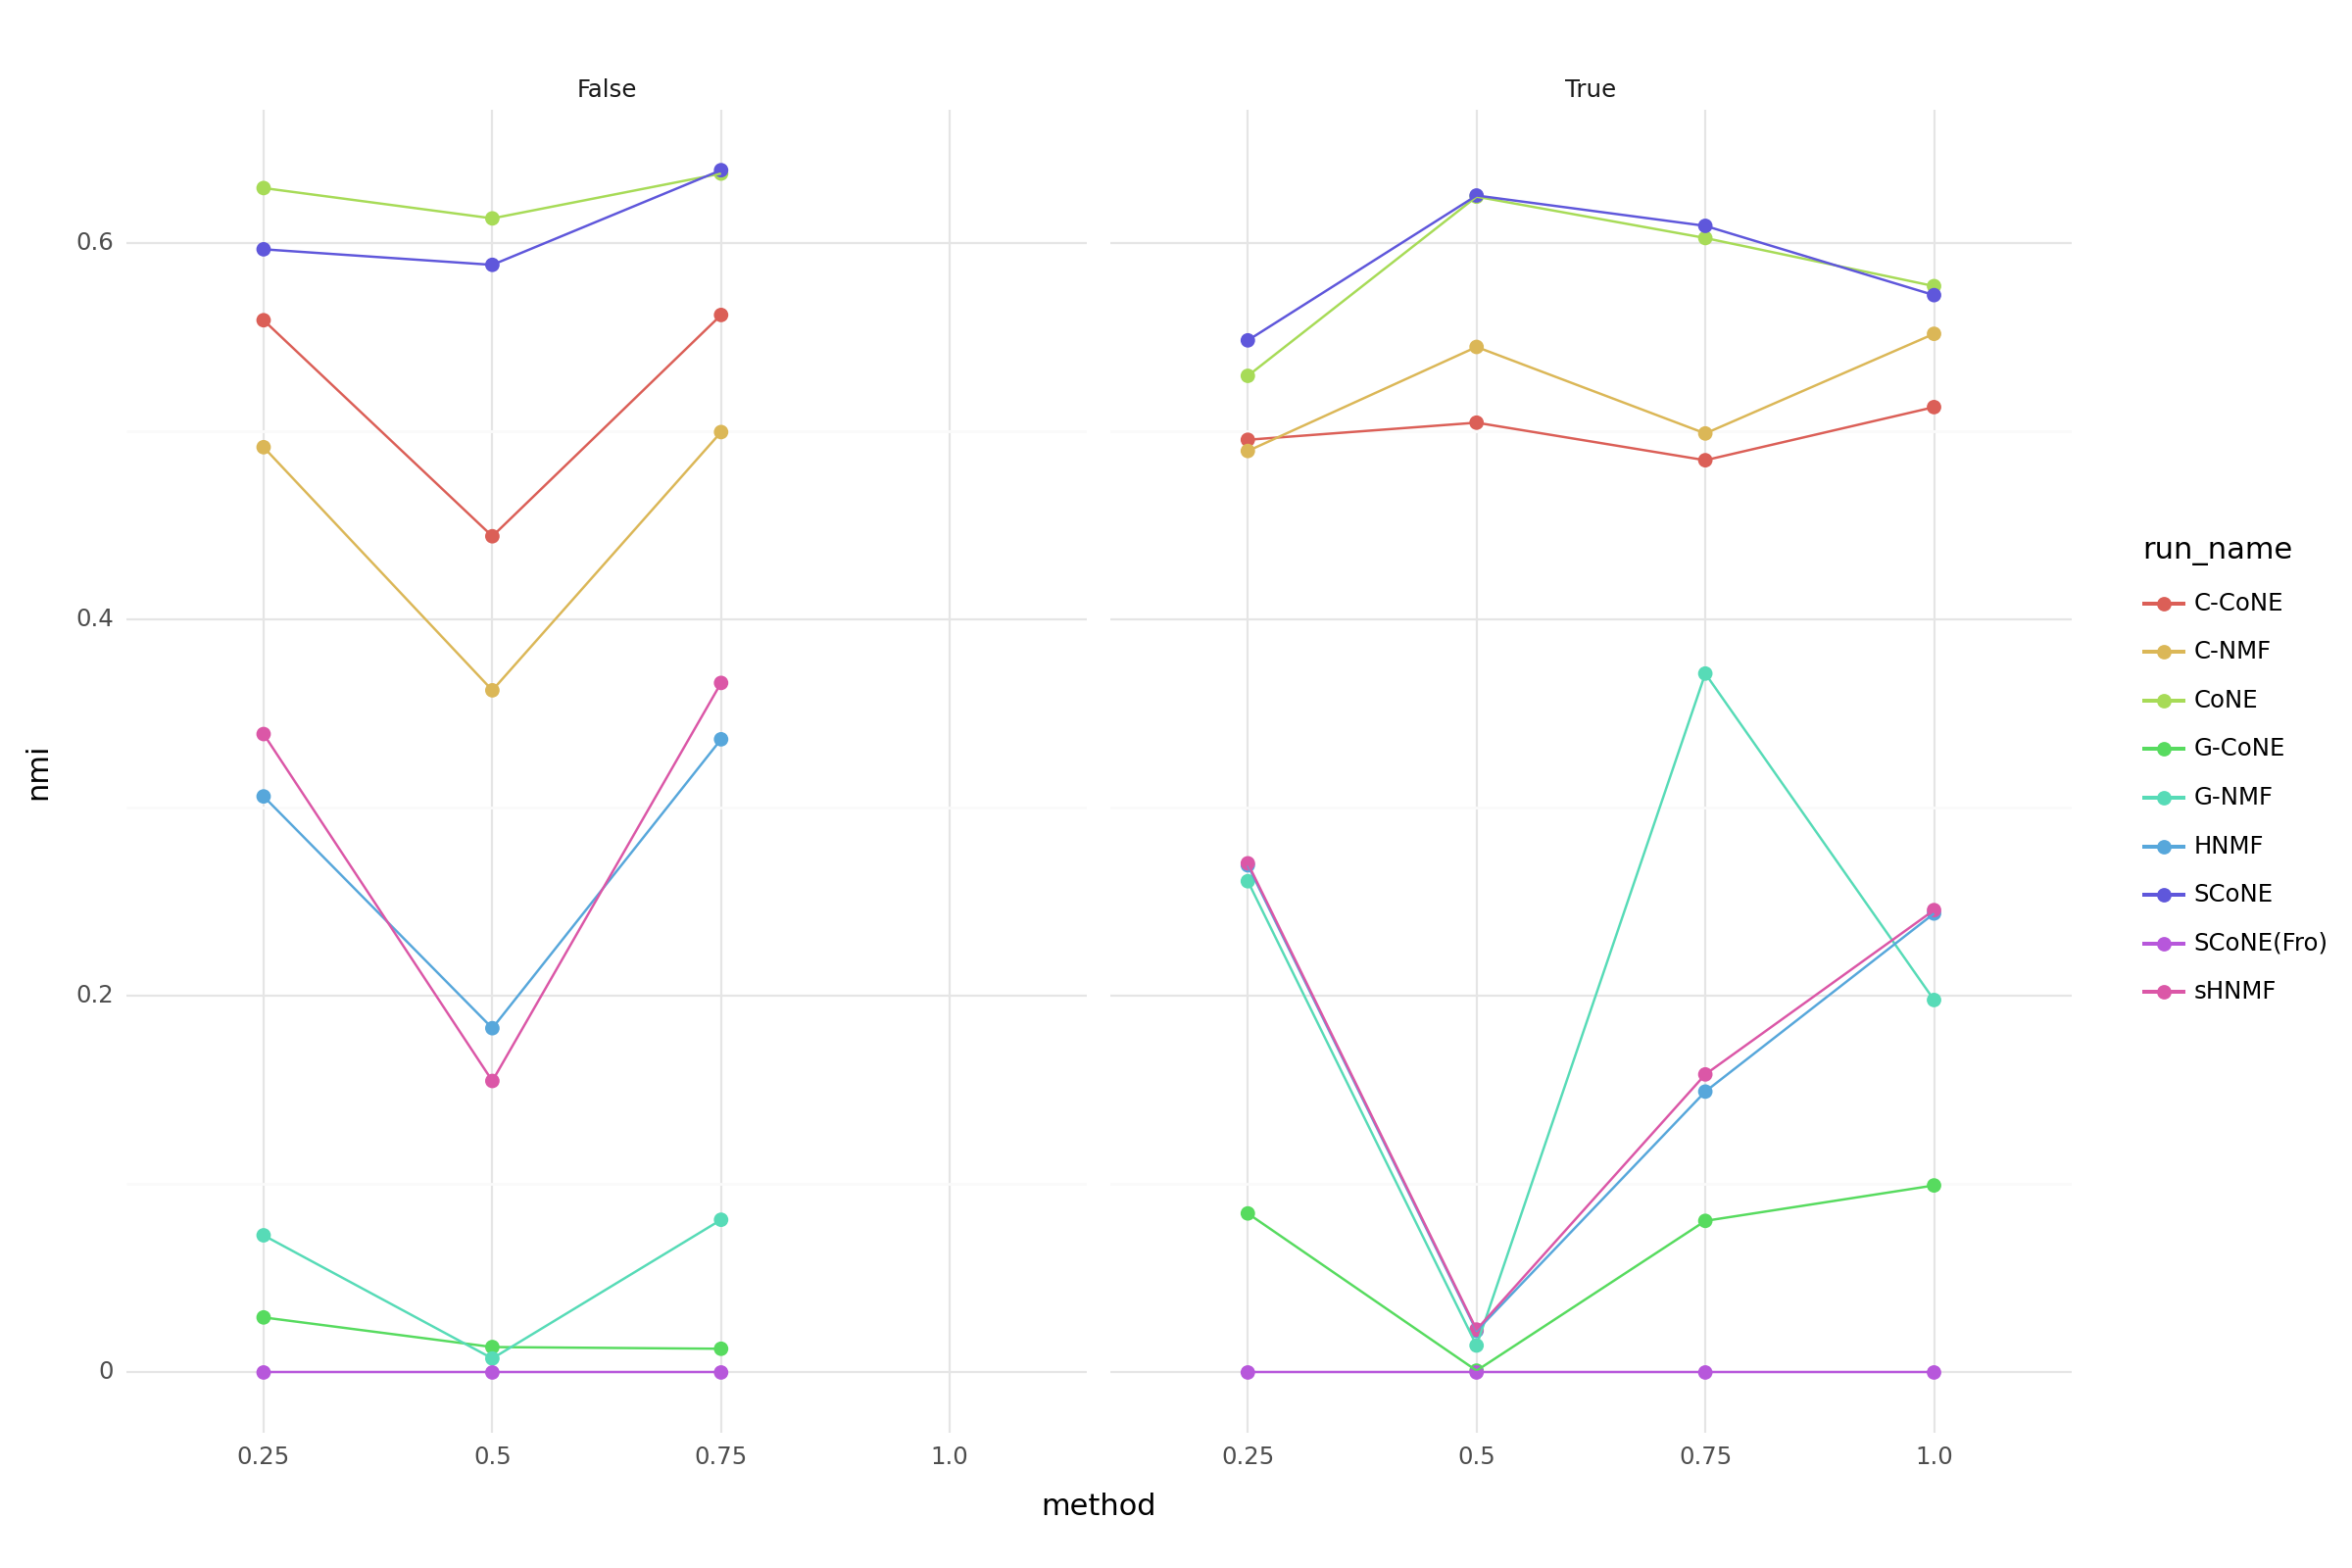

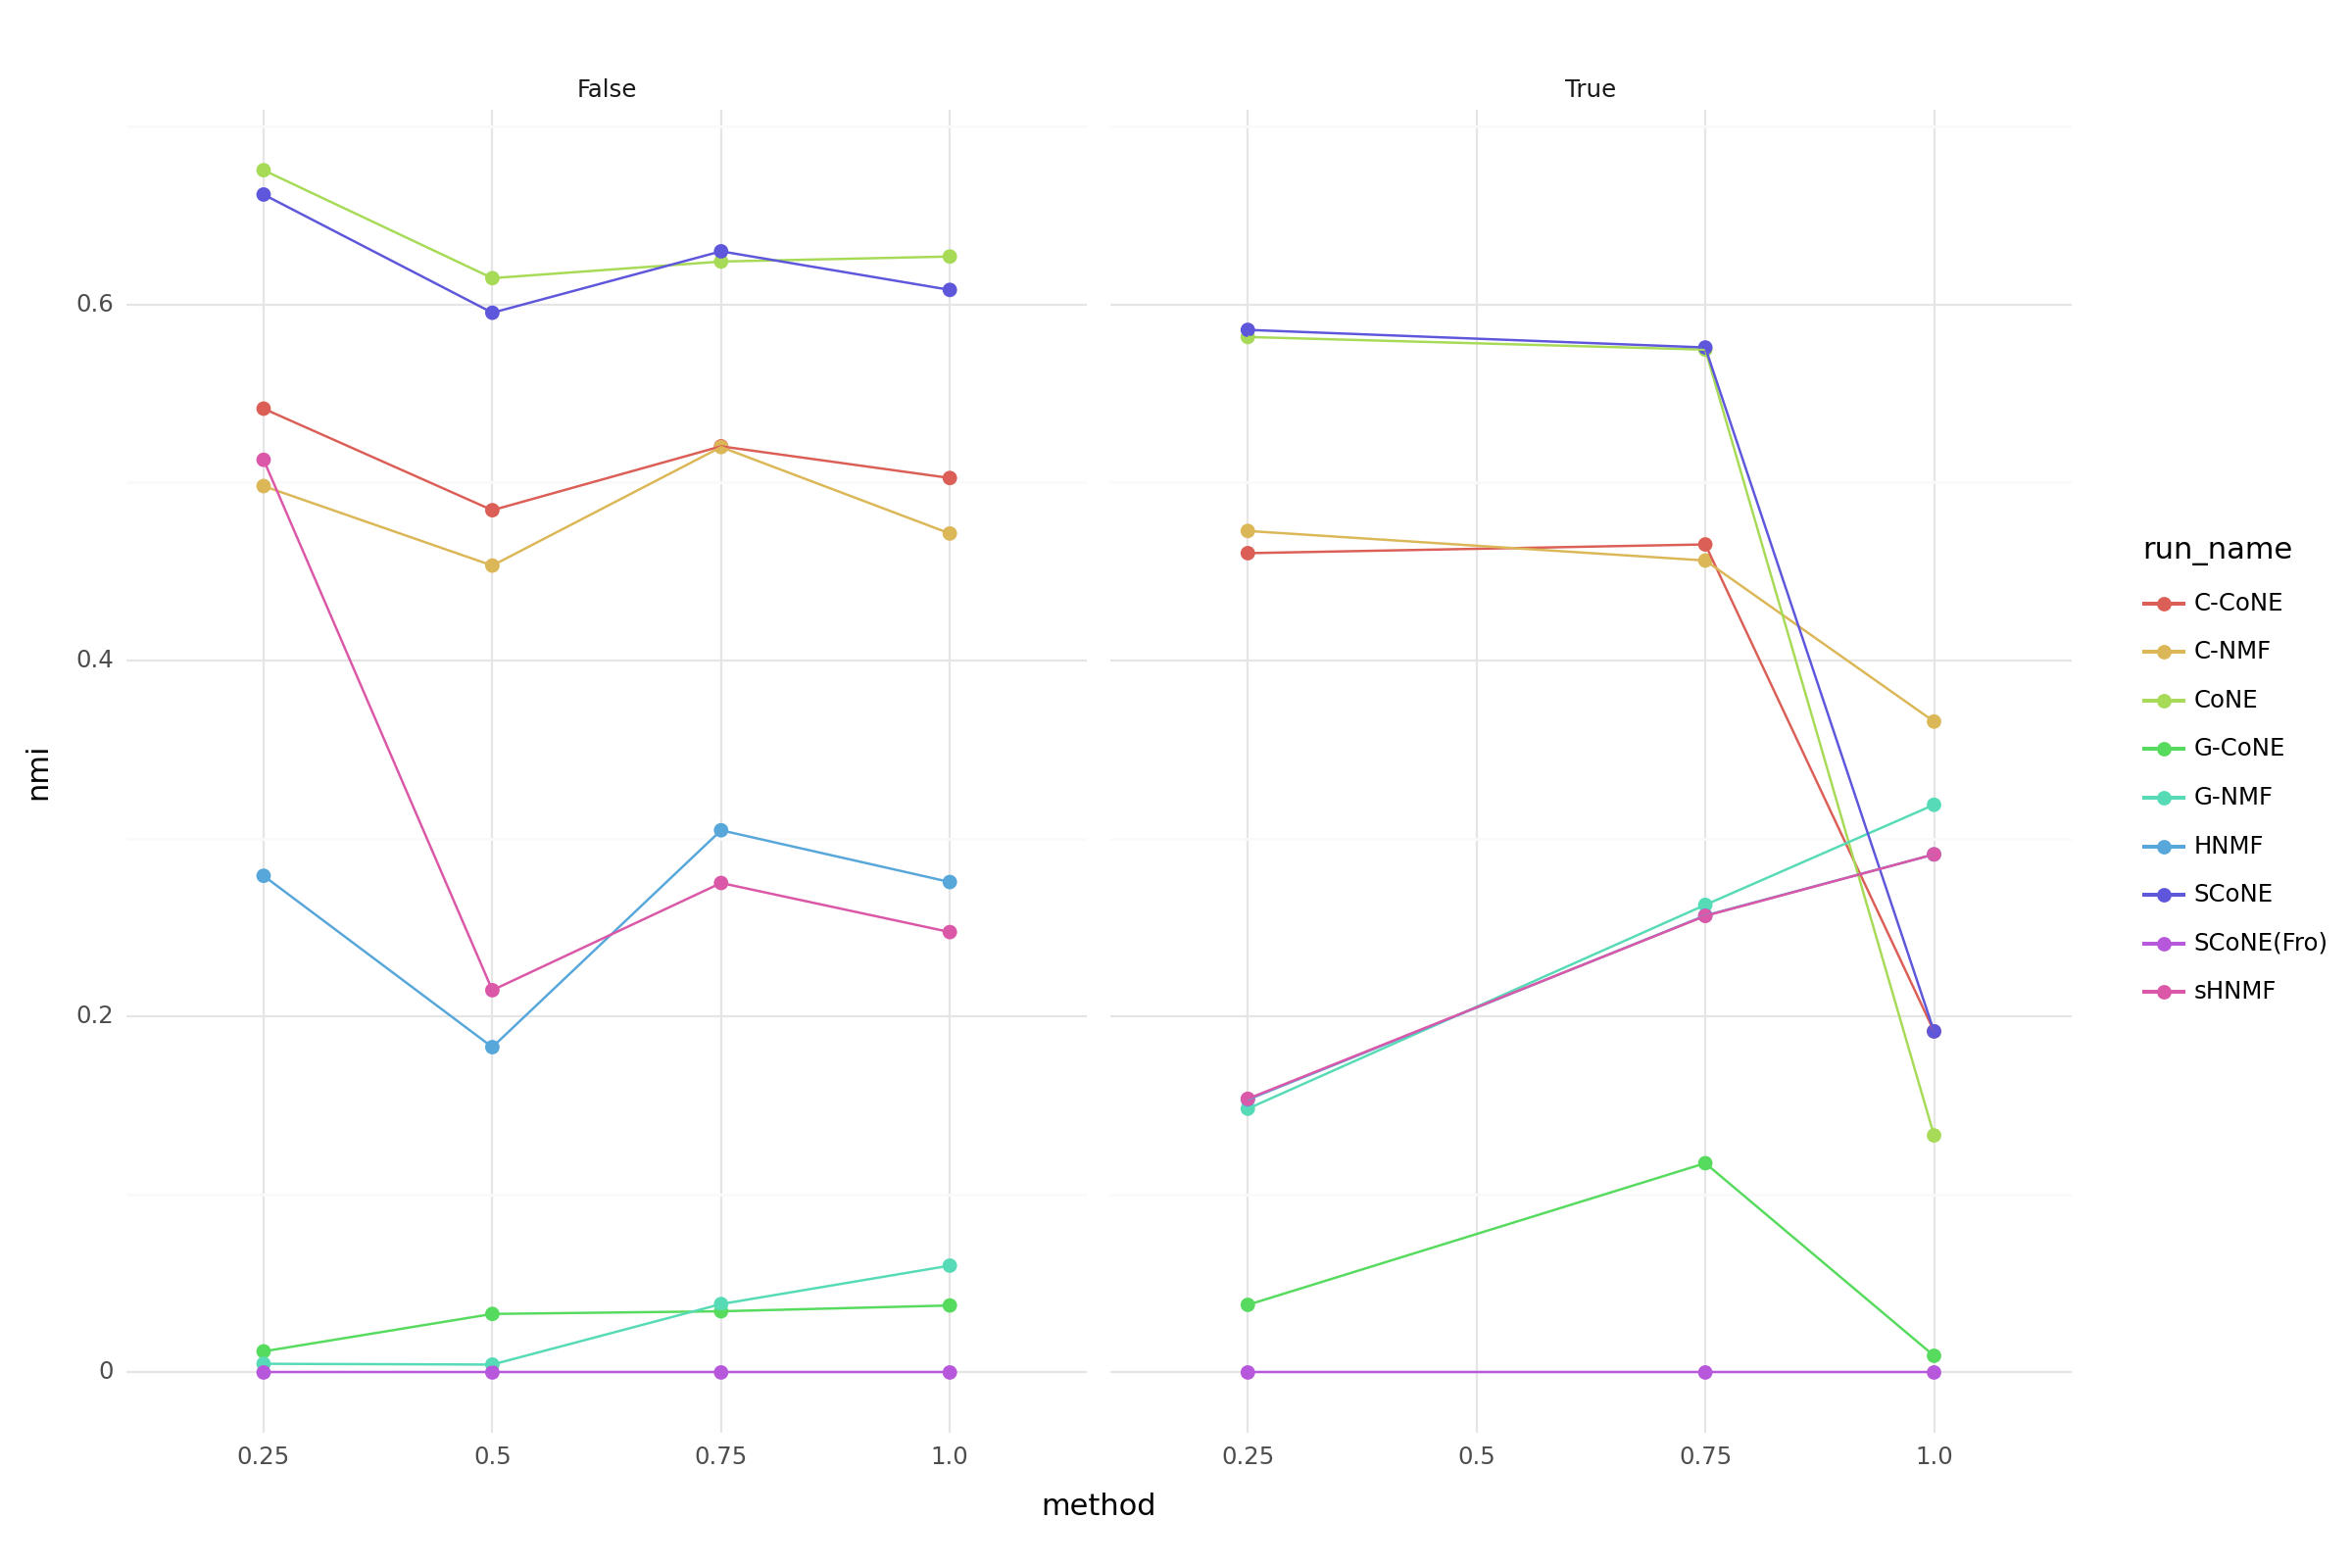

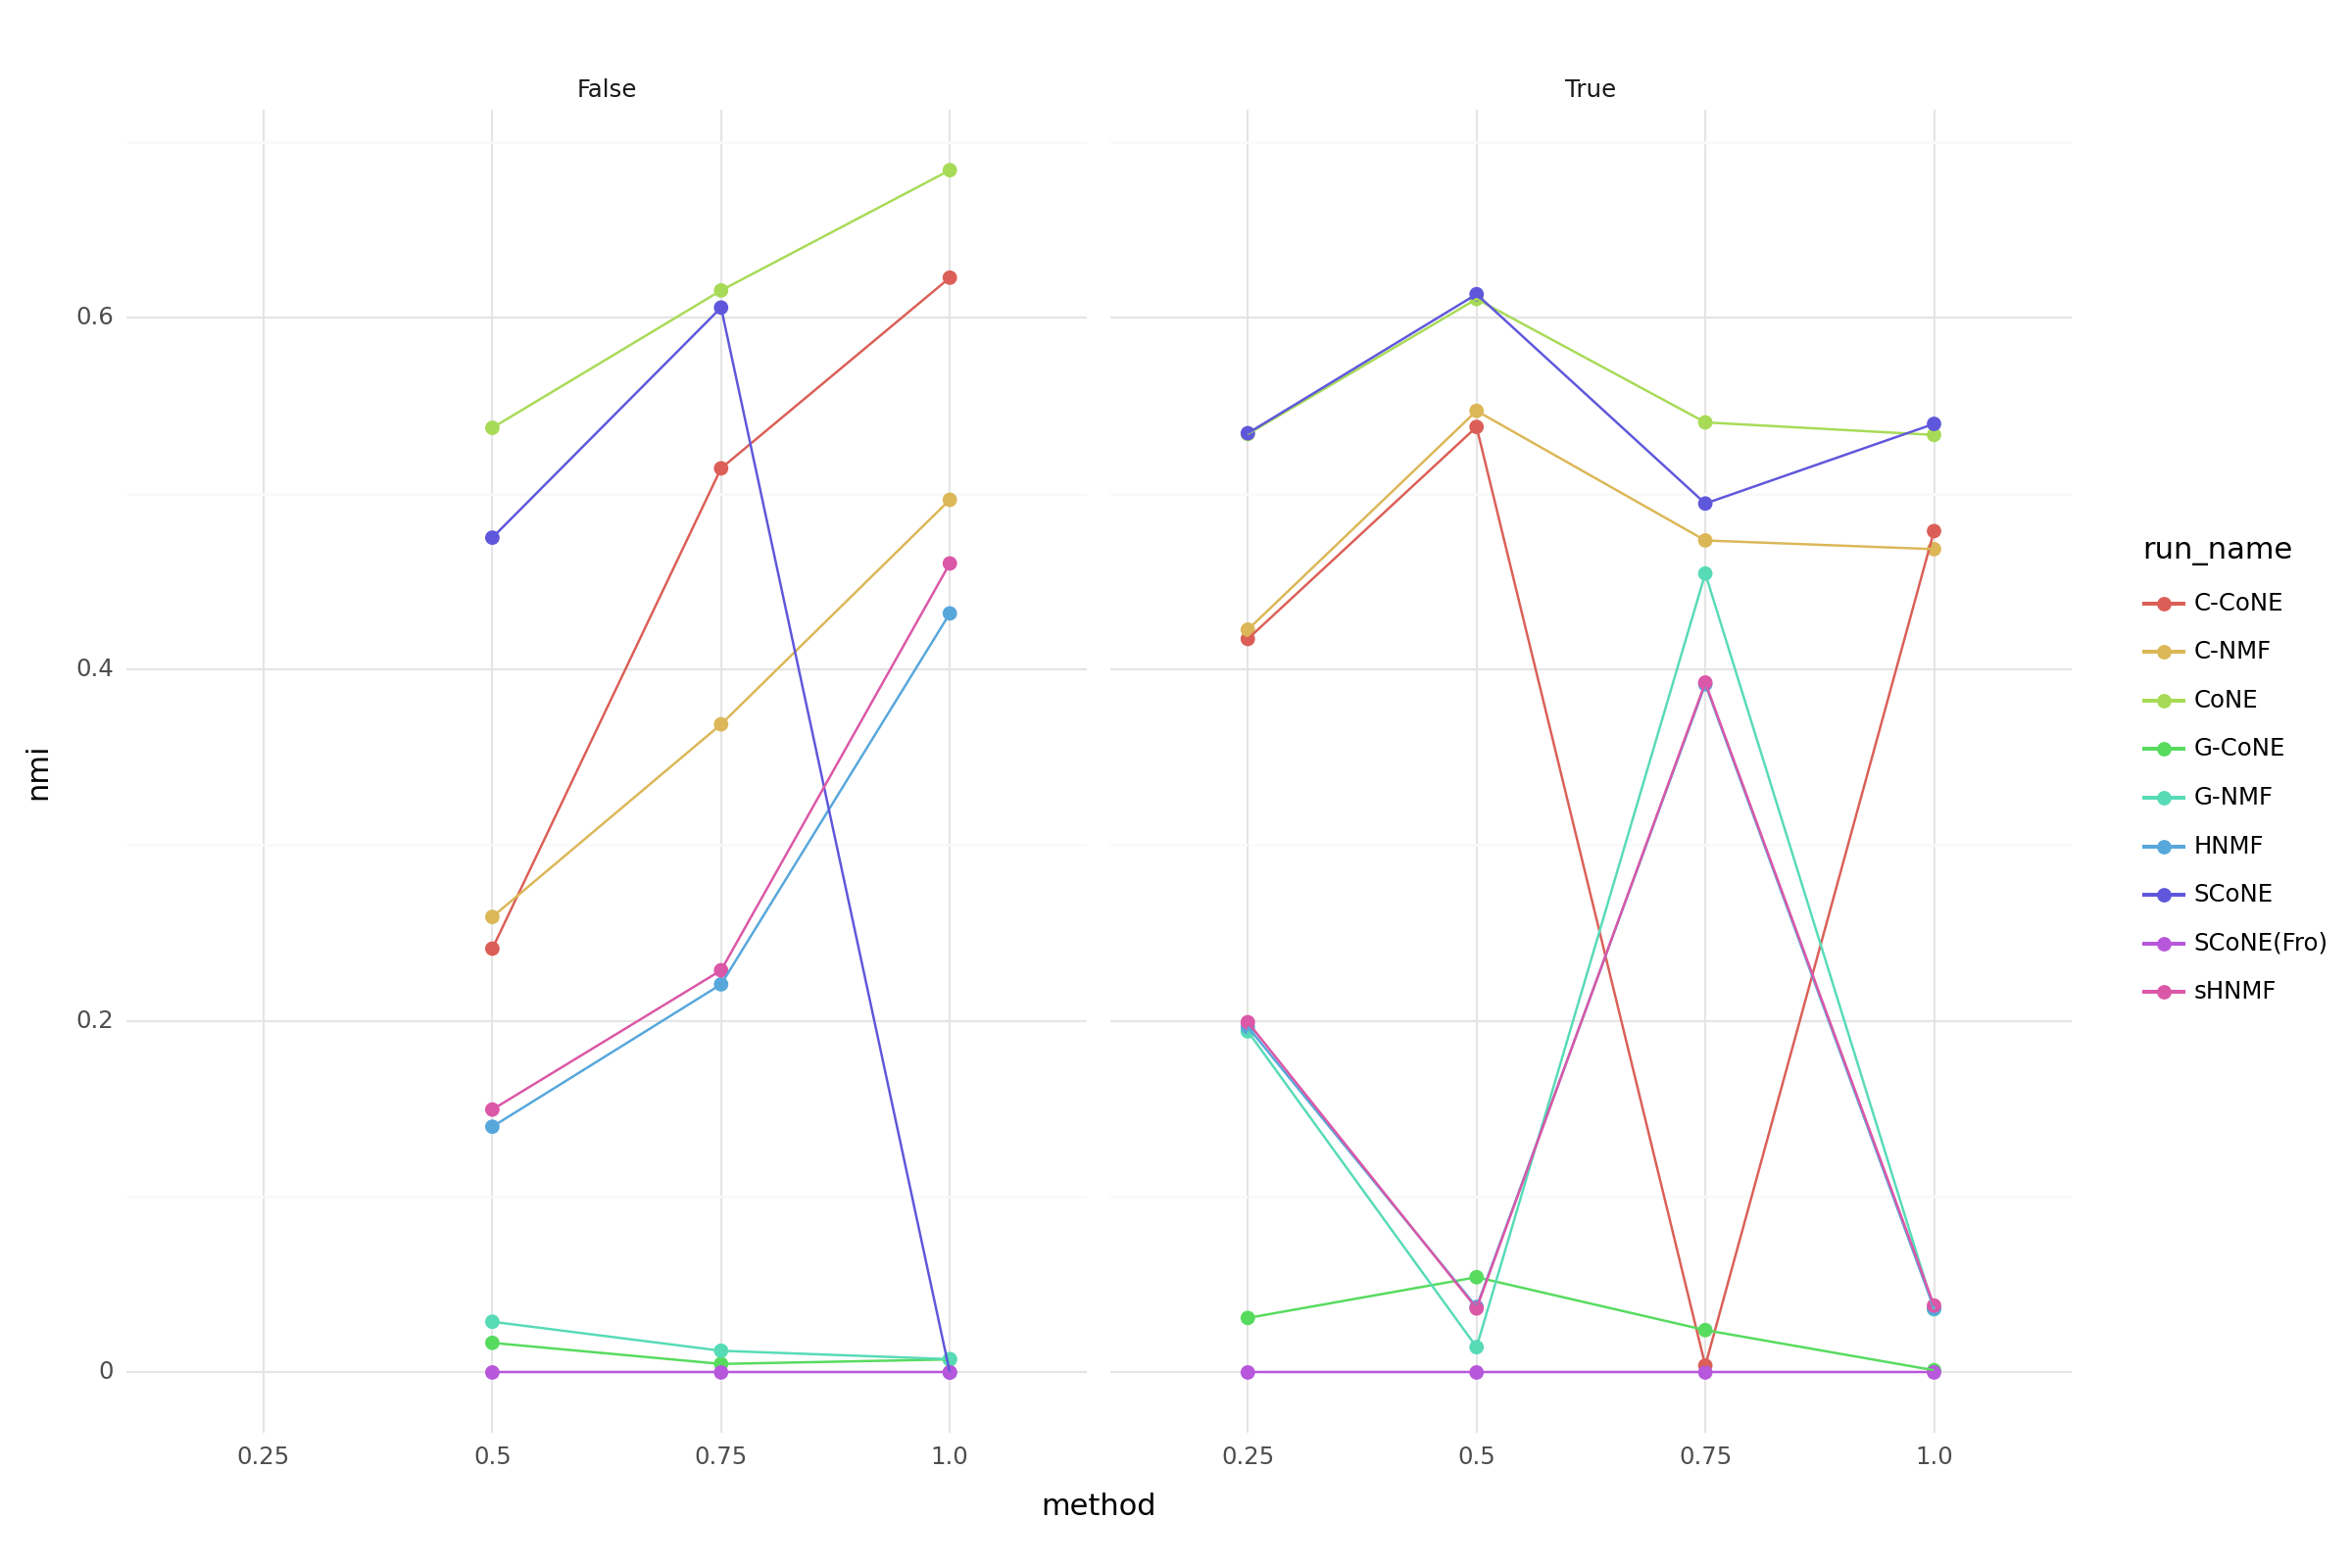

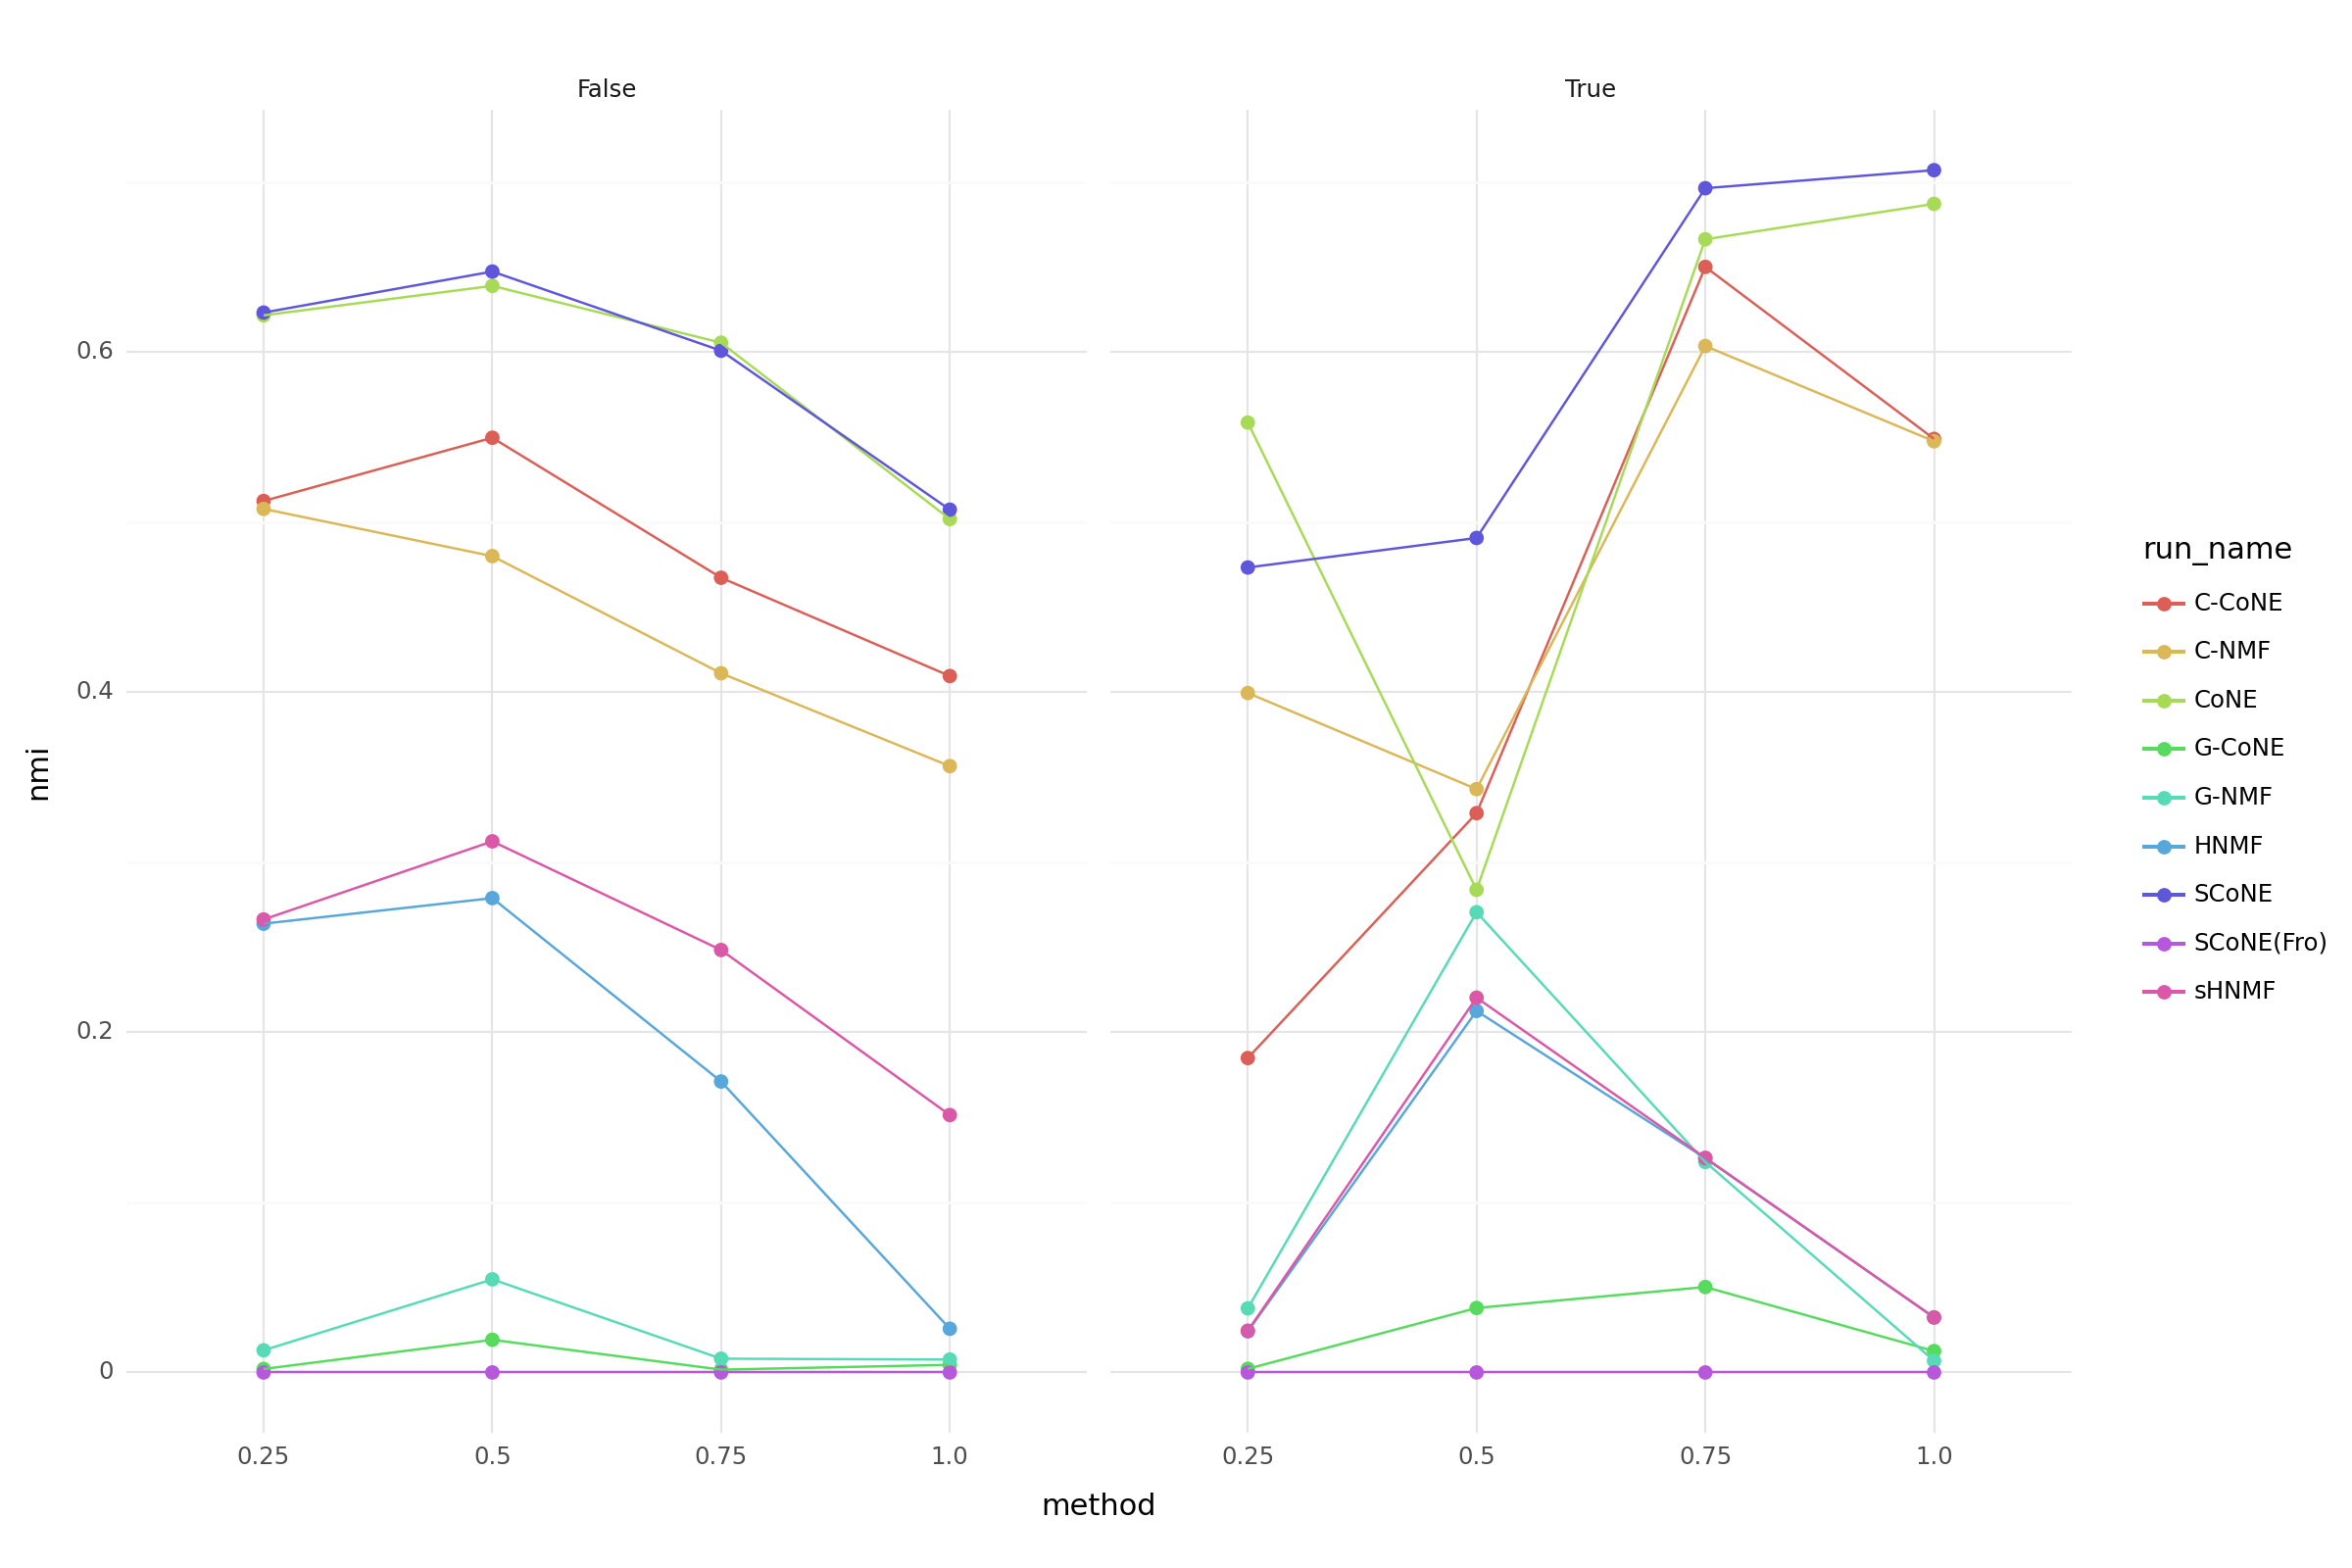

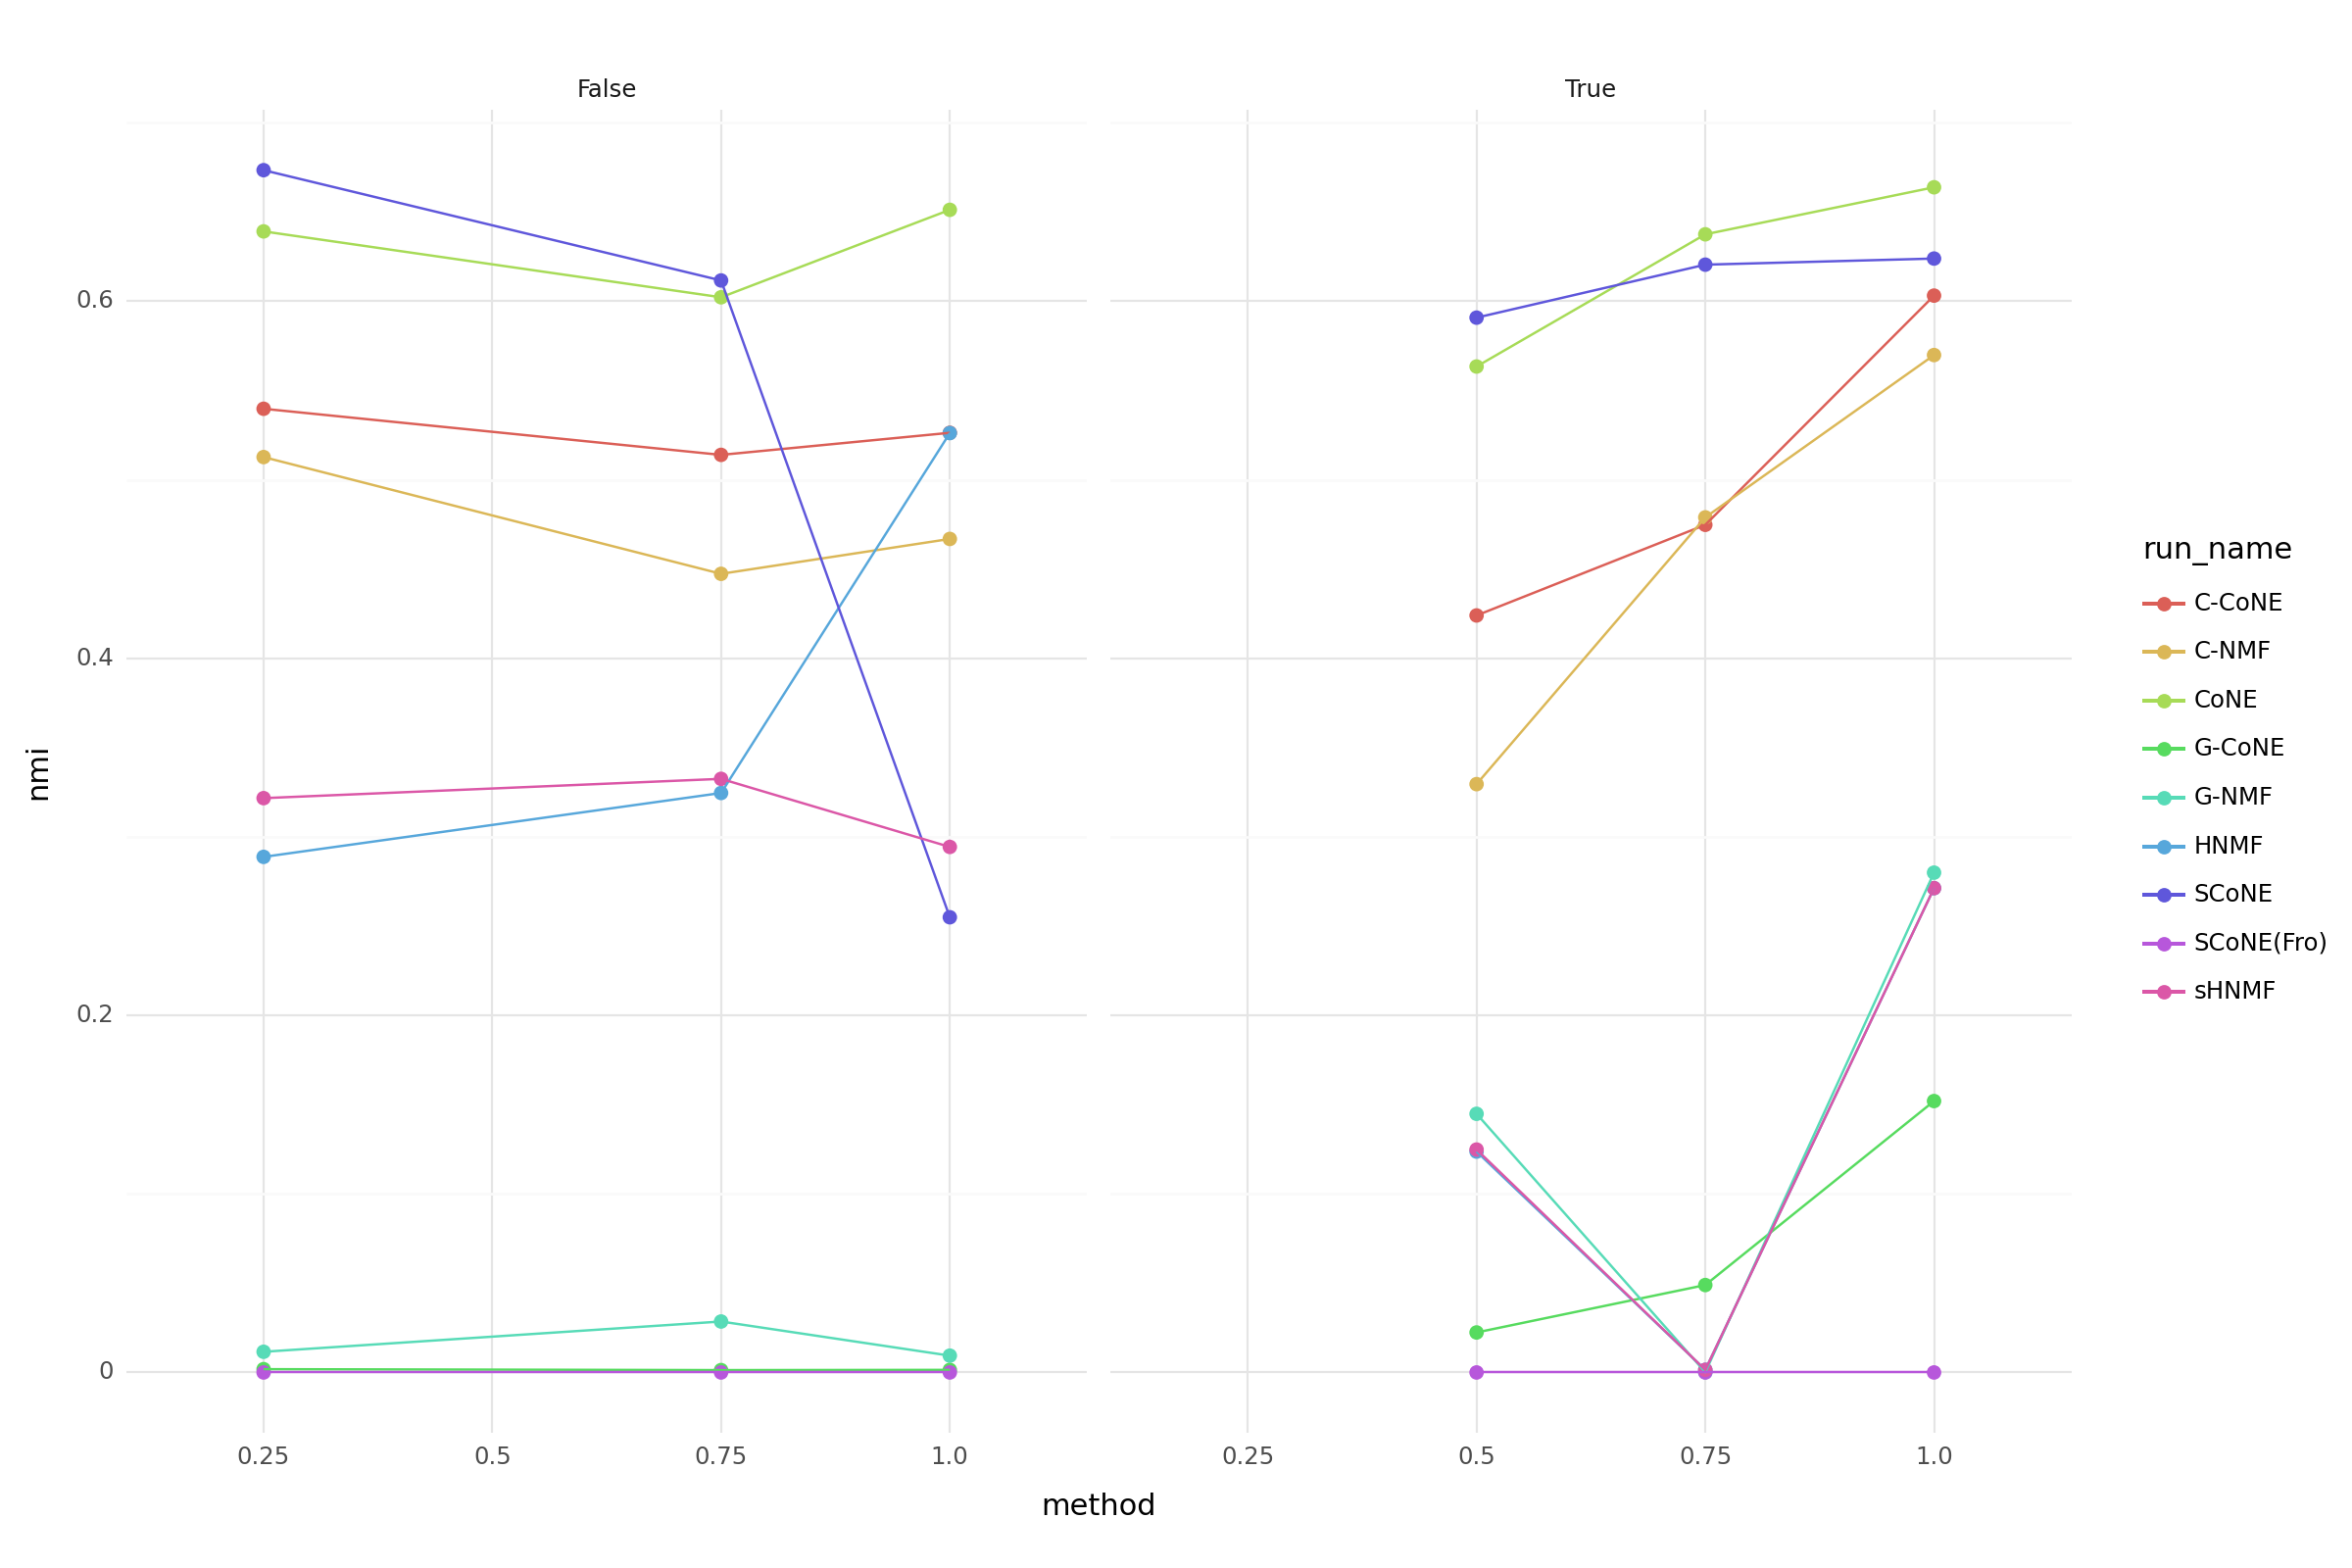

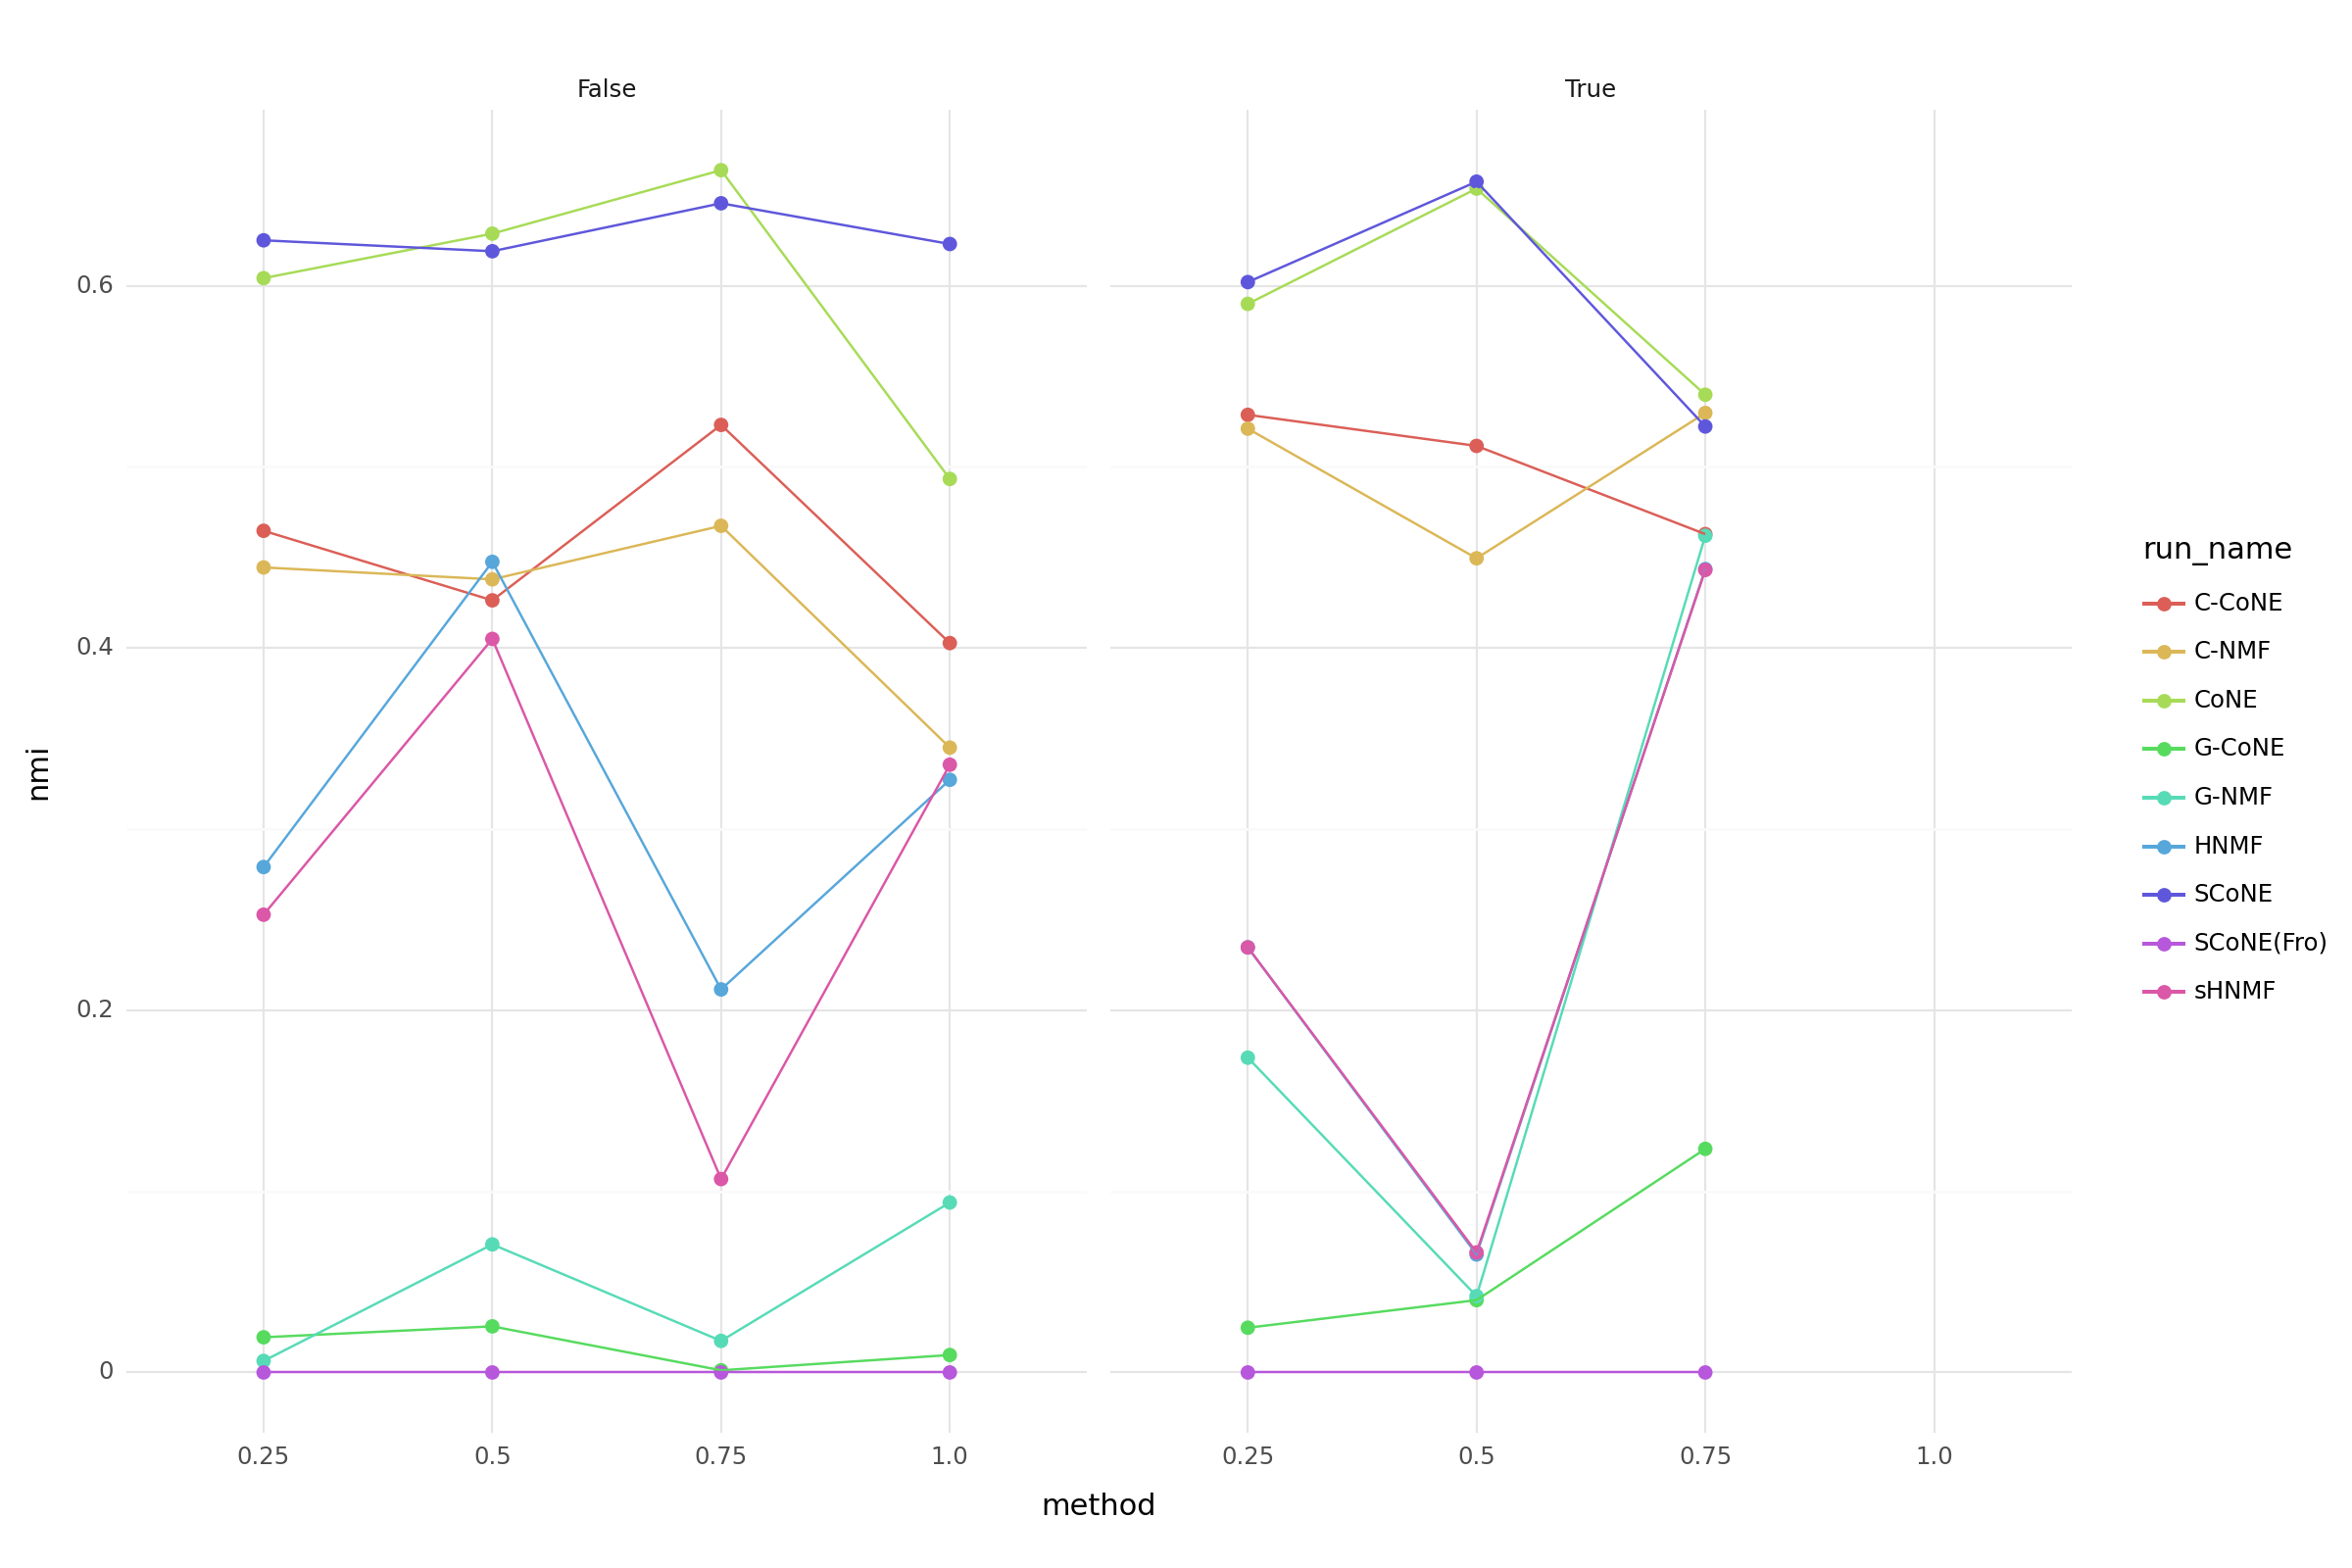

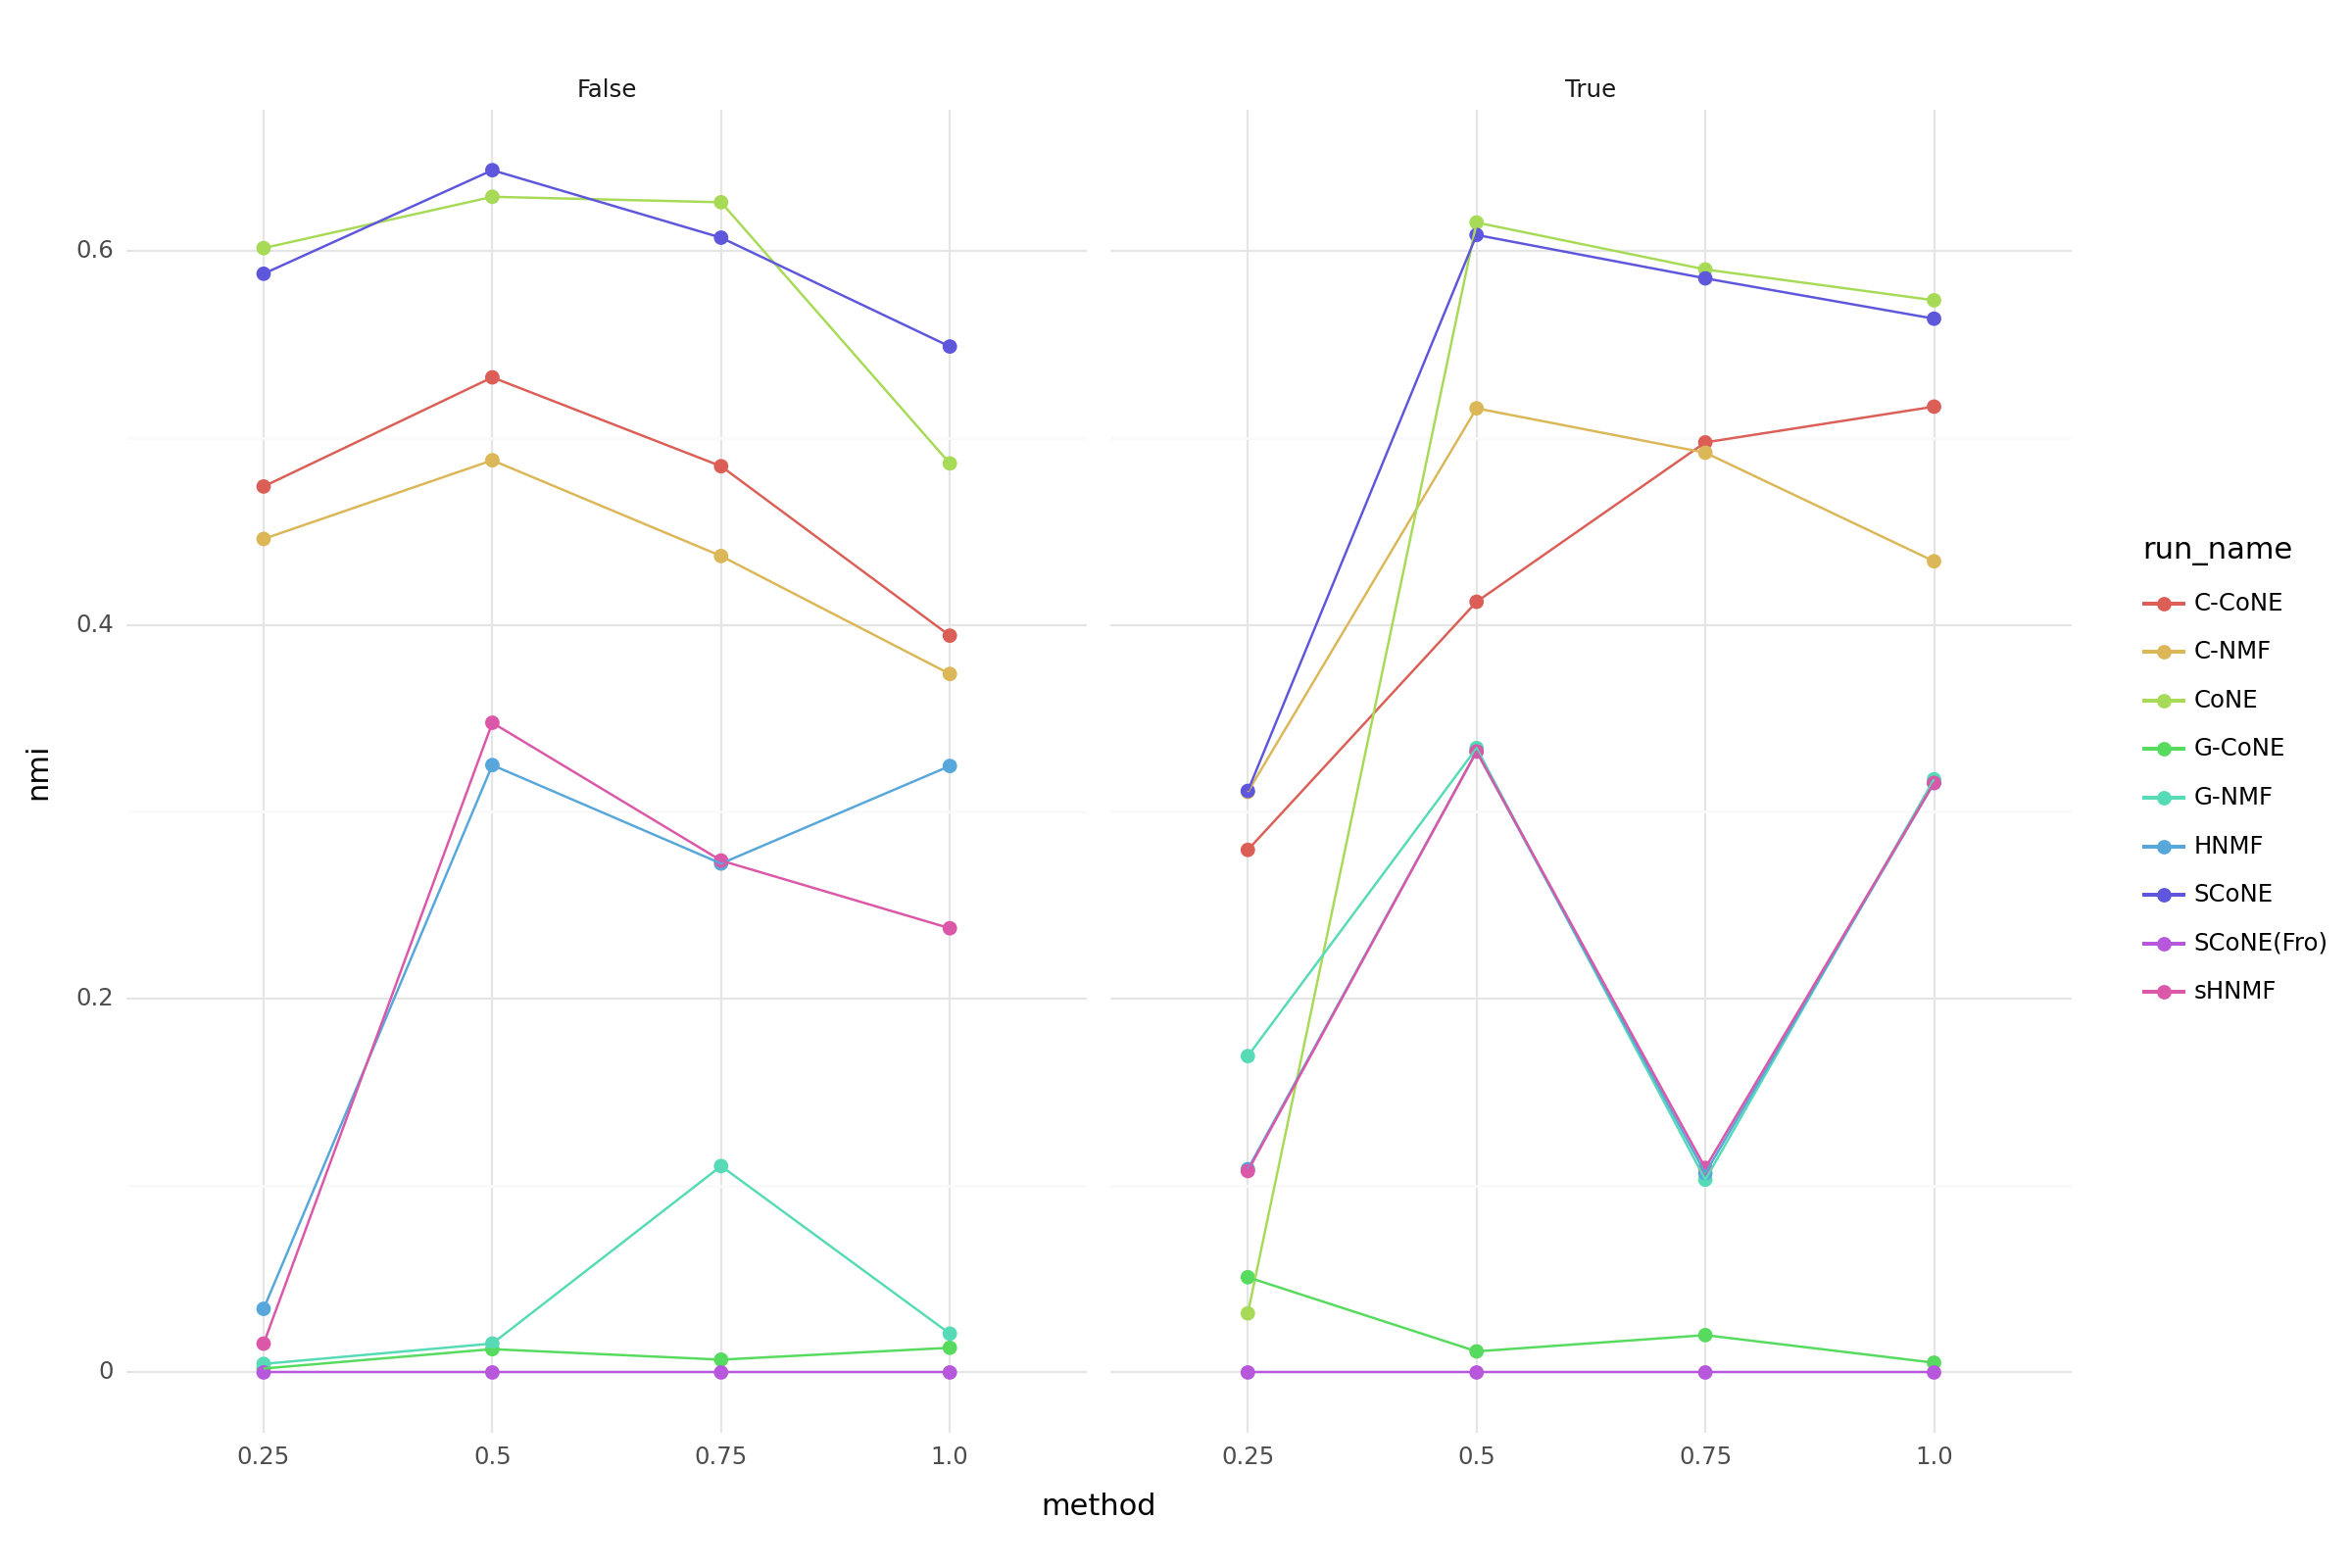

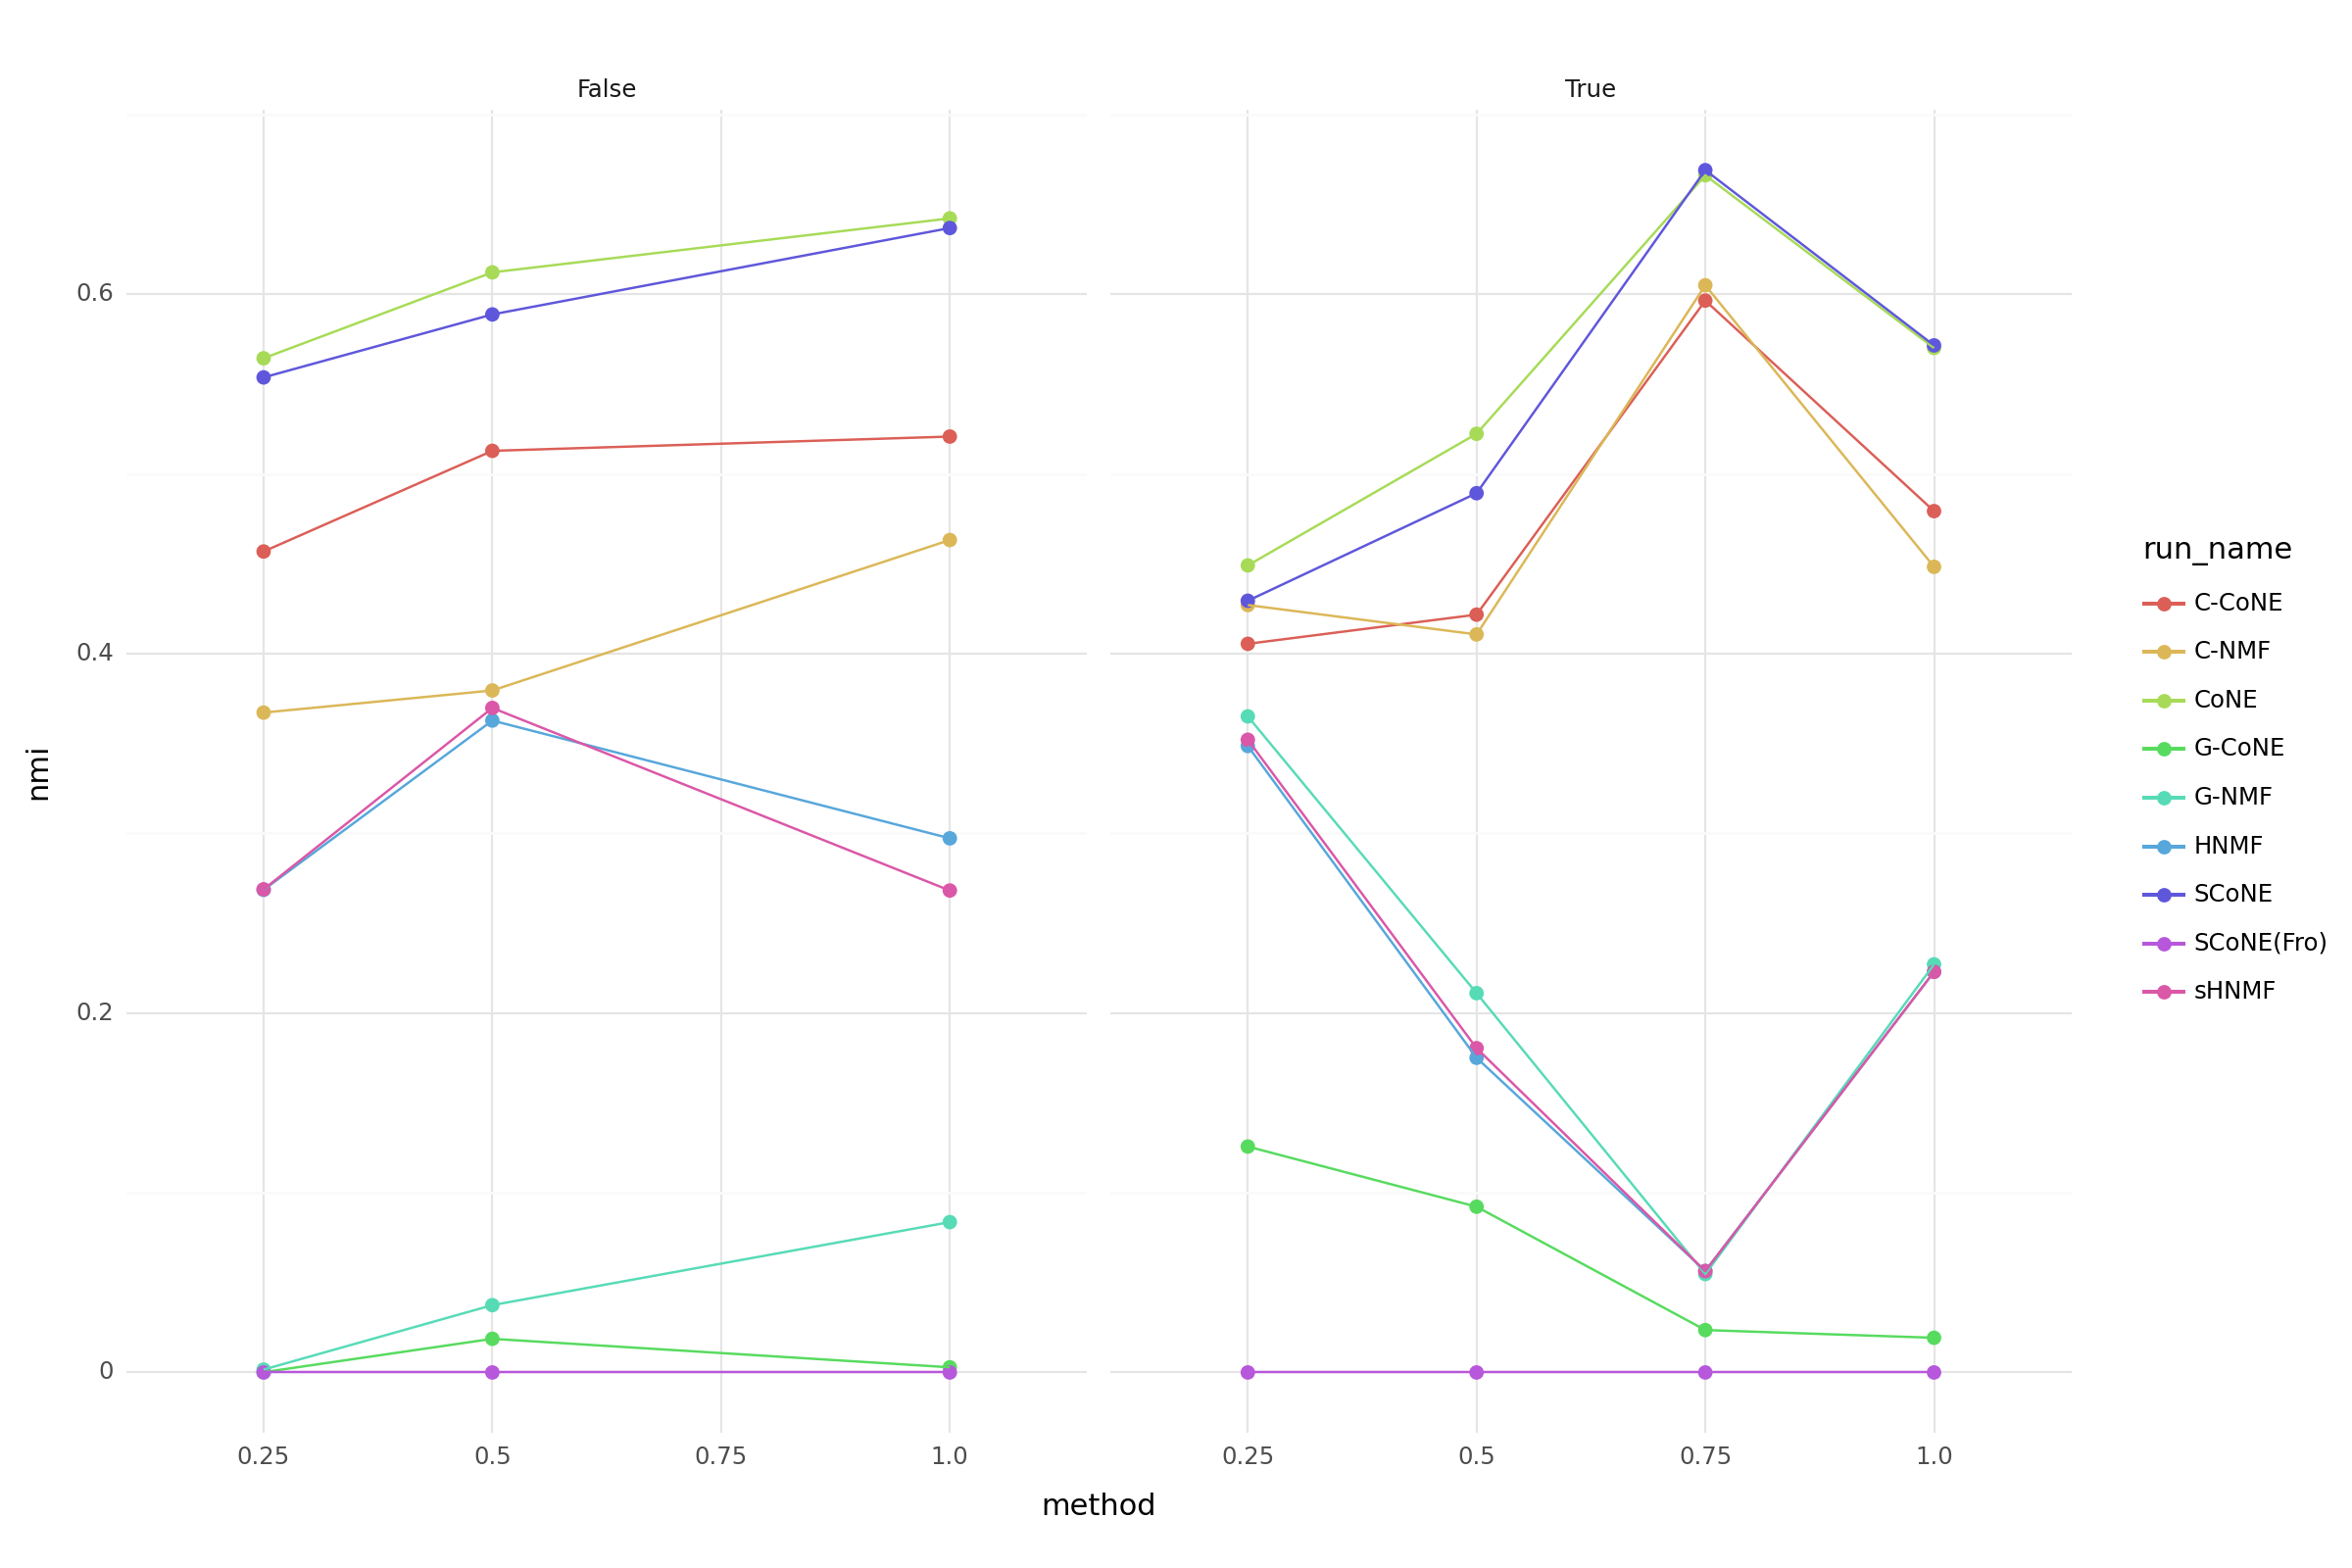

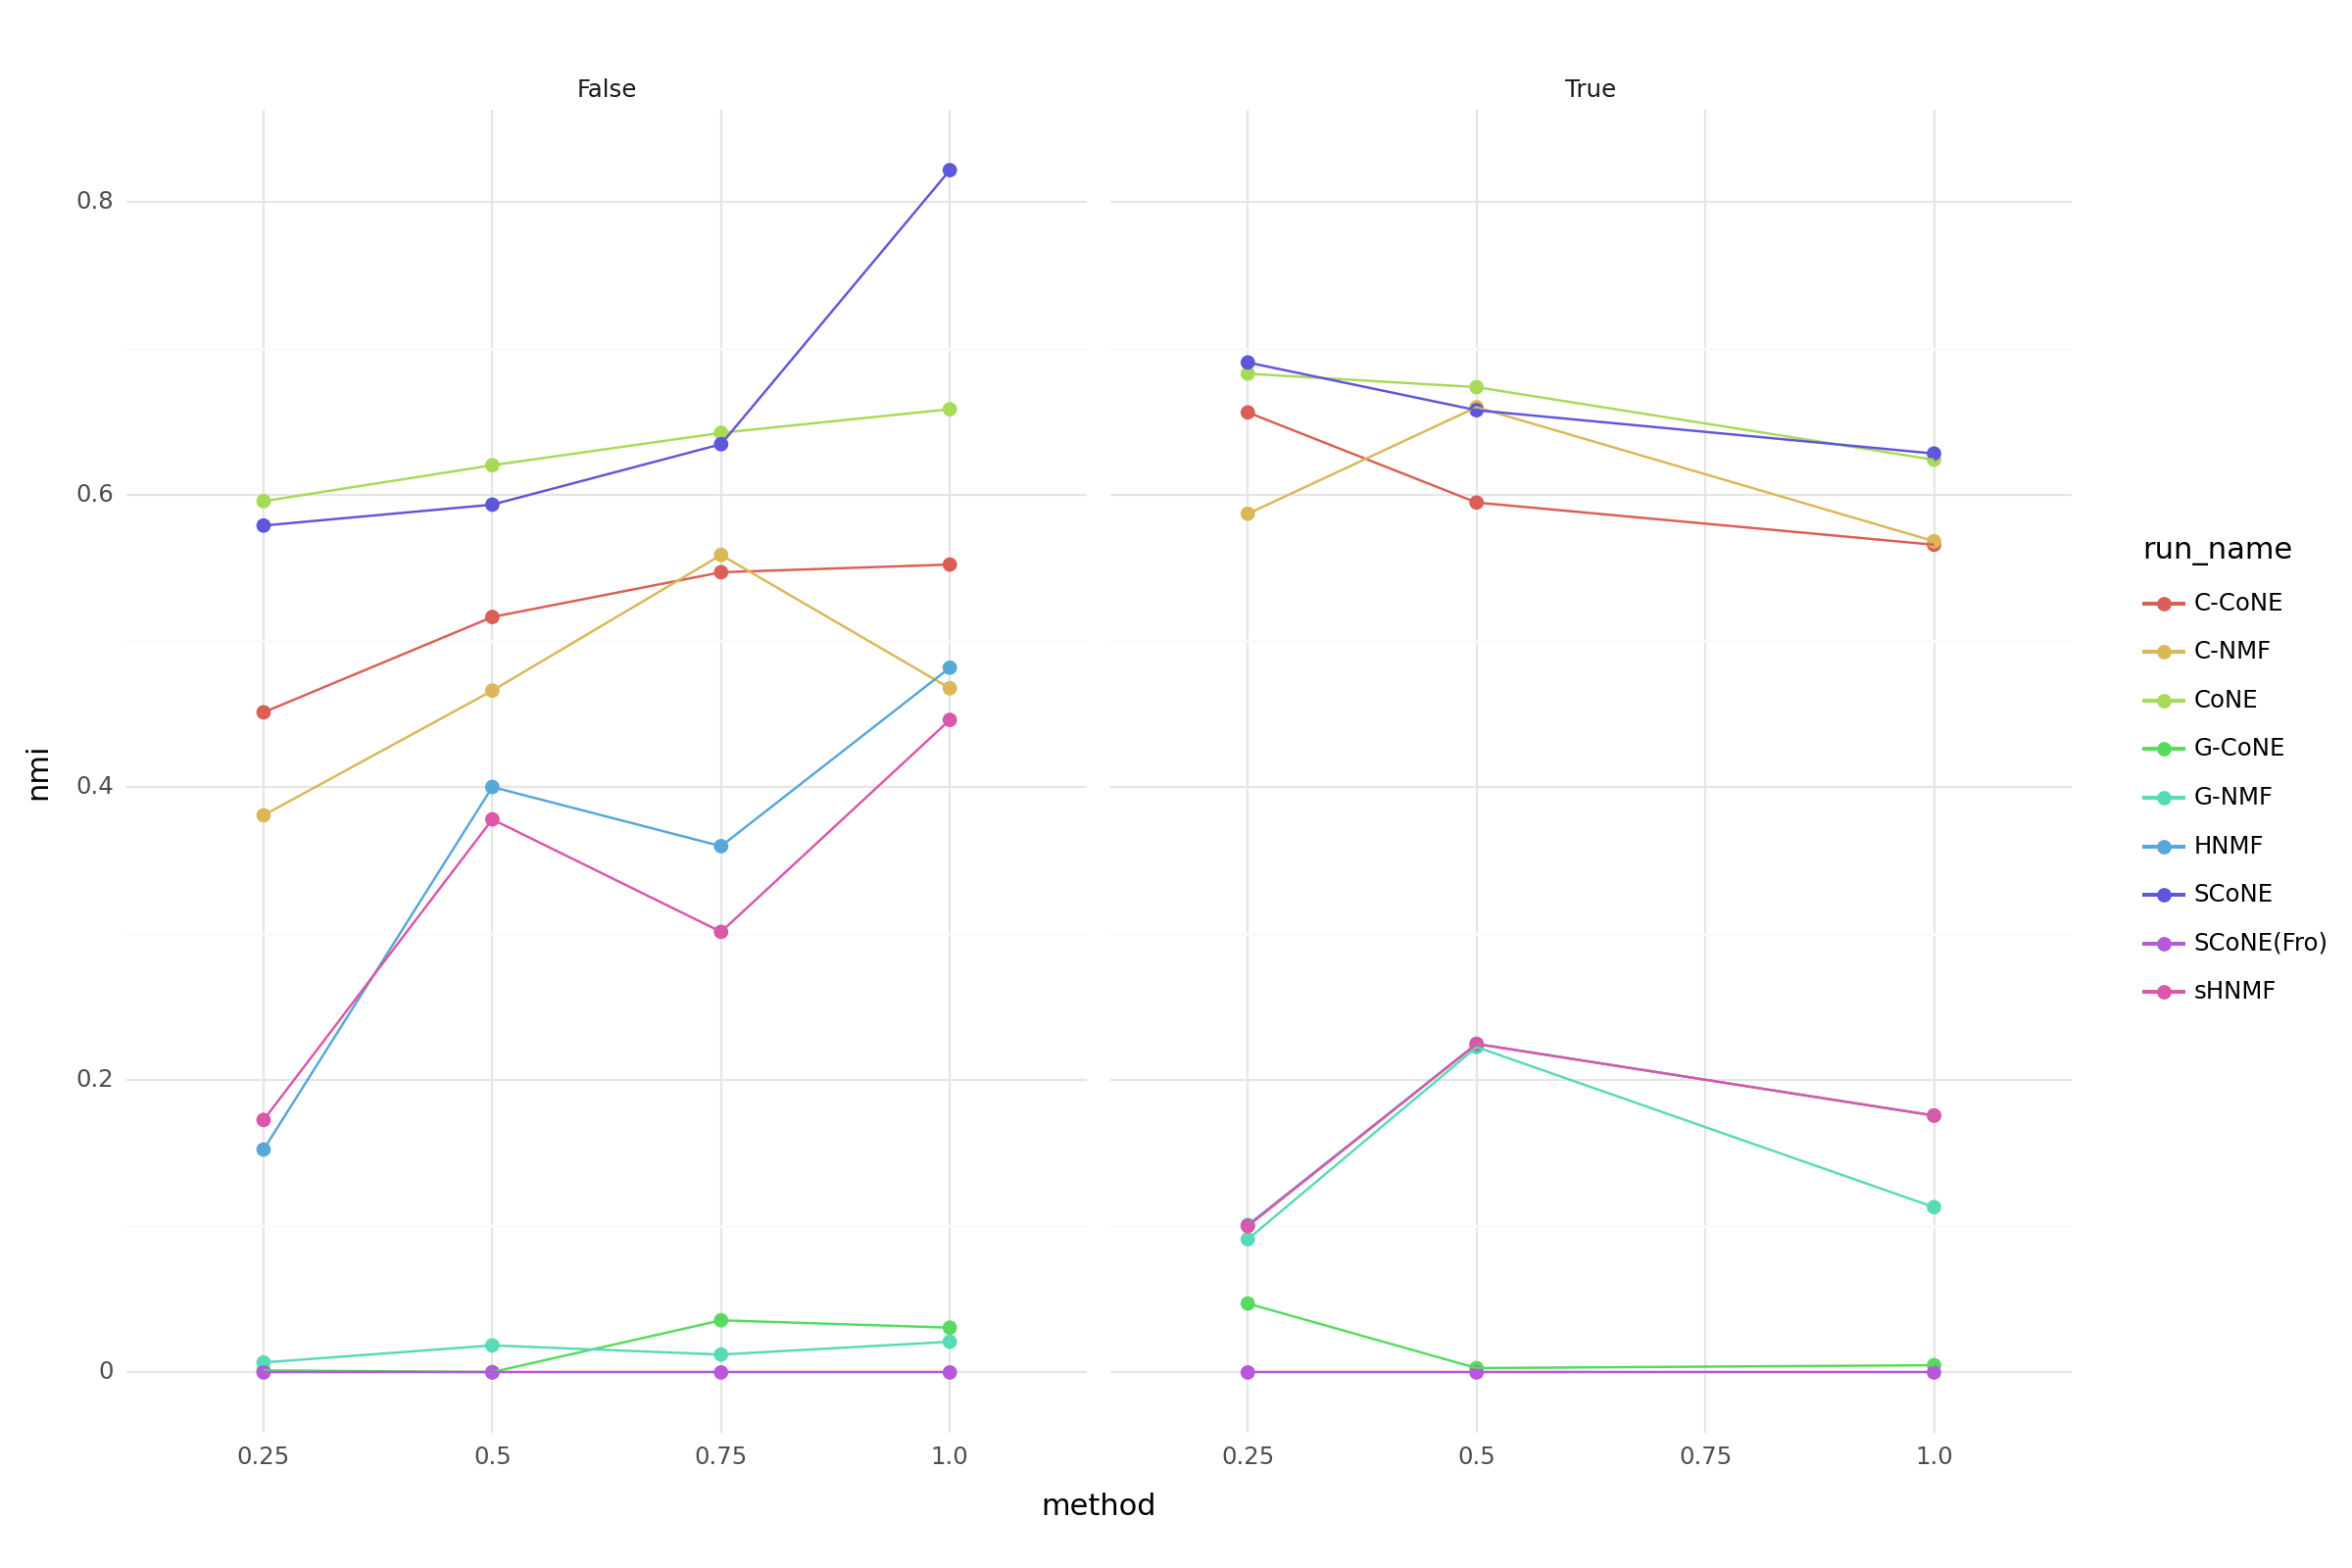

In [16]:
# get best model per total loss (since sparsity params fixed per run now) over initializations (within one experiment, dataset, run_name)
idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
best = (
    all_runs.loc[idx, all_runs.columns]
      .sort_values(["experiment_id","run_name", "ps", "e", "g"])
      .reset_index(drop=True)
)
dodge = position_dodge(width=0.35)

# get CI over 10 random datasets
for dataset in range(11):
    dataset_best = best[best['dataset']==str(dataset)].copy()
    for metric in ['nmi']:
        p = (
        ggplot(dataset_best, aes(x="factor(e)", y=metric, color="run_name", group="run_name"))
        + geom_point(size=2)
        + geom_line()
        + labs(x="method", y=metric, title='')
        + facet_wrap('ps')
        + theme_minimal()
        + theme(figure_size=(12,8))
        )
        print(p)
